Gamma Pulses and Neutron Pulses converted to dataframes


In [3]:
# Converting csv files to usable dataframes and basic preprocessing (Kuneh)


import pandas as pd
import csv

#----Paths to be mentioned----
gamma_path = "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\gamma pulses_1.csv"
neutron_files = [
    "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\neutron pulses_1.csv",
    "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\neutron pulses_2.csv",
    "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\neutron pulses_3.csv"
]


def process_pulse_data(file_path):
    """
    Reads a pulse CSV file, parses the fixed columns and SAMPLES,
    and returns an expanded DataFrame with samples as individual columns.
    """
    parsed_data = []
    
    with open(file_path, 'r') as f:
        csv_reader = csv.reader(f, delimiter=';')
        

        header = next(csv_reader)
        
        for row in csv_reader:
            if not row:
                continue

            # Only row 6 is of importance 
            samples = row[6:]
            
            parsed_data.append({
                'SAMPLES': samples
            })
    

    df = pd.DataFrame(parsed_data)
    

    samples_expanded = pd.DataFrame(df['SAMPLES'].tolist())
    samples_expanded = samples_expanded.add_prefix('t')
    
    samples_expanded = samples_expanded.apply(pd.to_numeric, errors='coerce')

    samples_expanded = samples_expanded.sub(samples_expanded.max(axis=1), axis=0).abs()
    samples_expanded['t_mean'] = samples_expanded.mean(axis=1)

    return samples_expanded

#----Processing----
df_expanded_gamma = process_pulse_data(gamma_path)
print("Gamma pulses processed. Shape:", df_expanded_gamma.shape)

neutron_dfs = [process_pulse_data(f) for f in neutron_files]
df_expanded_neutron = pd.concat(neutron_dfs, ignore_index=True)
print("Neutron pulses processed. Shape:", df_expanded_neutron.shape)

print(df_expanded_gamma.head())
print(df_expanded_neutron.head())

Gamma pulses processed. Shape: (33868, 997)
Neutron pulses processed. Shape: (26136, 997)
   t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...  t987  t988  t989  t990  t991  \
0   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4     4   
1   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4     4   
2   0   0   0   0   0   0   0   0   0   0  ...     0     0     0     0     0   
3   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4     4   
4   4   4   4   4   0   4   4   4   4   4  ...     4     4     4     4     4   

   t992  t993  t994  t995     t_mean  
0     4     4     4     4  14.706827  
1     4     4     4     4  14.522088  
2     0     0     0     0   8.662651  
3     4     4     4     4  10.598394  
4     4     4     4     4  15.357430  

[5 rows x 997 columns]
   t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...  t987  t988  t989  t990  t991  \
0   4   4   4   4   4   4   4   4   4   4  ...     4     0     4     4     4   
1   0   0  

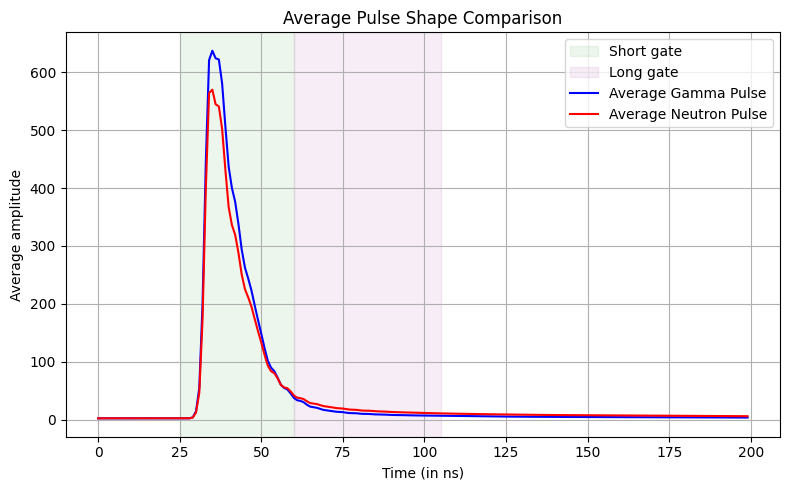

In [233]:
import matplotlib.pyplot as plt
import numpy as np

mean_waveform_gamma   = df_expanded_gamma.mean(axis=0).iloc[:-1]
mean_waveform_neutron = df_expanded_neutron.mean(axis=0).iloc[:-1]
x = np.arange(200)

short_start, split, long_end = 25, 60, 105

fig, ax = plt.subplots(figsize=(8, 5))

# Gate shading
ax.axvspan(short_start, split,    alpha=0.07, color='green',  label='Short gate')
ax.axvspan(split,       long_end, alpha=0.07, color='purple', label='Long gate')

ax.plot(x, mean_waveform_gamma[:200],   color='blue', linewidth=1.5, label='Average Gamma Pulse')
ax.plot(x, mean_waveform_neutron[:200], color='red',  linewidth=1.5, label='Average Neutron Pulse')


ax.set_xlabel("Time (in ns)")
ax.set_ylabel("Average amplitude")
ax.set_title("Average Pulse Shape Comparison")
ax.grid(True)

ax.legend()
for spine in ax.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

Charge Comparison Method (understanding the role of preprocessing on the logistic regression accuracy and FoM plots)

[Raw] Split=50 | FOM=0.4102 | Acc=0.9035 | AUC=0.9669
[Smoothed] Split=50 | FOM=0.4140 | Acc=0.9048 | AUC=0.9673
[Smoothed + Log] Split=50 | FOM=0.4913 | Acc=0.8896 | AUC=0.9518
[Raw] Split=55 | FOM=0.3807 | Acc=0.9279 | AUC=0.9811
[Smoothed] Split=55 | FOM=0.3736 | Acc=0.9282 | AUC=0.9814
[Smoothed + Log] Split=55 | FOM=0.5008 | Acc=0.8979 | AUC=0.9590
[Raw] Split=60 | FOM=0.3252 | Acc=0.9252 | AUC=0.9810
[Smoothed] Split=60 | FOM=0.3370 | Acc=0.9266 | AUC=0.9816
[Smoothed + Log] Split=60 | FOM=0.6111 | Acc=0.8978 | AUC=0.9591
[Raw] Split=65 | FOM=0.2819 | Acc=0.9153 | AUC=0.9776
[Smoothed] Split=65 | FOM=0.3233 | Acc=0.9158 | AUC=0.9781
[Smoothed + Log] Split=65 | FOM=0.5869 | Acc=0.8927 | AUC=0.9553


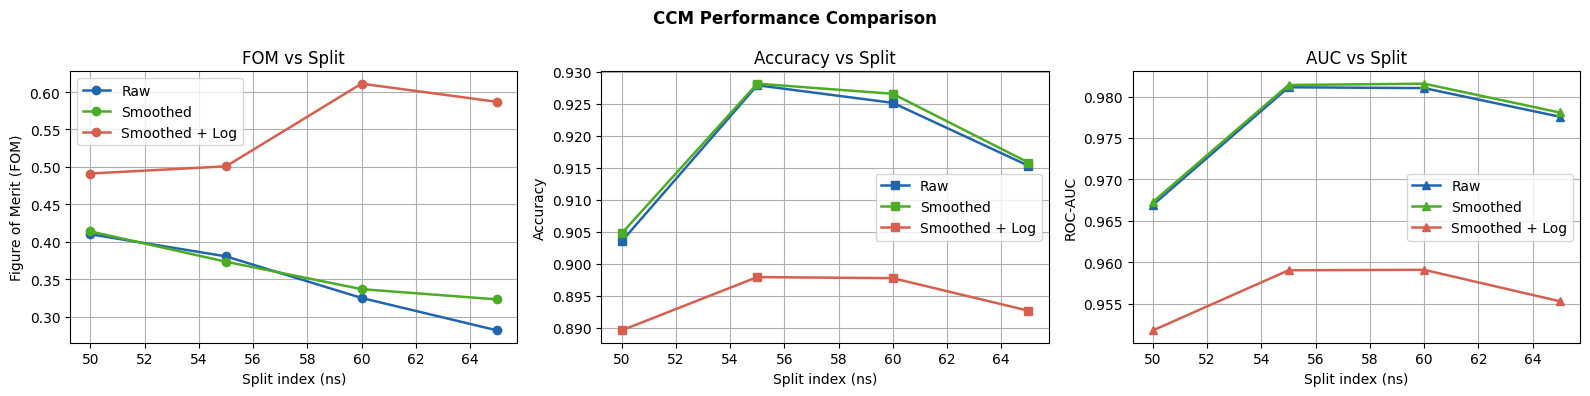

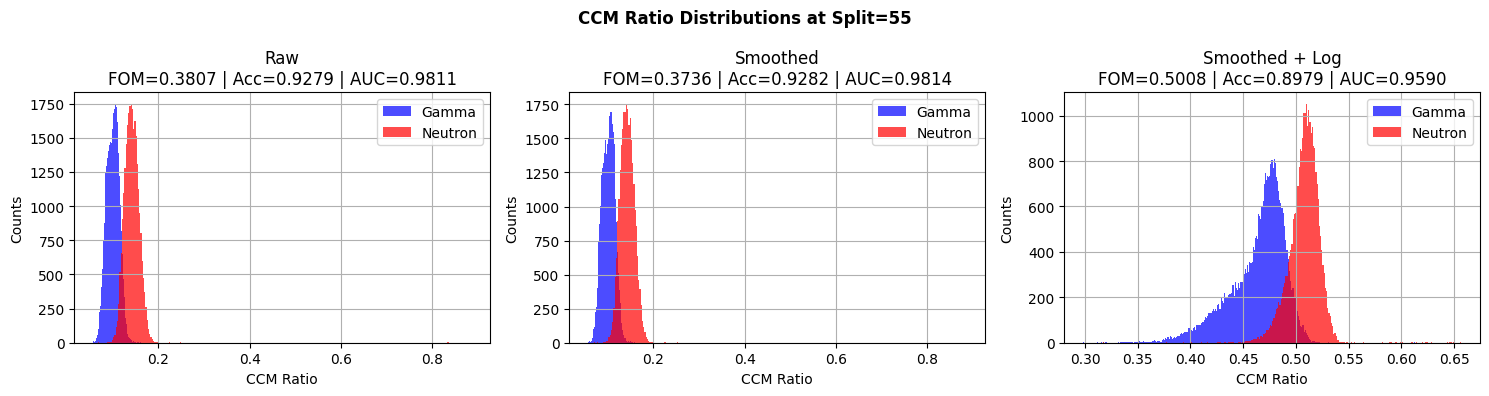

In [ ]:
# CCM Performance Comparison: Raw vs Smoothed vs Smoothed+Log (Kuneh)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# ── Helper functions ──────────────────────────────────────────────────────────

def calculate_fom(gamma_data, neutron_data, bins=200):
    g_counts, g_edges = np.histogram(gamma_data, bins=bins)
    n_counts, n_edges = np.histogram(neutron_data, bins=bins)
    g_mids = (g_edges[:-1] + g_edges ) / 2
    n_mids = (n_edges[:-1] + n_edges ) / 2

    def get_fwhm(counts, mids):
        peak_idx  = np.argmax(counts)
        half_max  = counts[peak_idx] / 2
        left_idx  = np.where(counts[:peak_idx] <= half_max)[0]
        left_idx  = left_idx[-1] if len(left_idx) > 0 else 0
        right_idx = np.where(counts[peak_idx:] <= half_max)[0]
        right_idx = (right_idx[0] + peak_idx) if len(right_idx) > 0 else len(counts) - 1
        return mids[peak_idx], mids[right_idx] - mids[left_idx]

    g_peak, g_fwhm = get_fwhm(g_counts, g_mids)
    n_peak, n_fwhm = get_fwhm(n_counts, n_mids)
    return abs(n_peak - g_peak) / (g_fwhm + n_fwhm)


def get_accuracy(gamma_ratio, neutron_ratio):
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([np.zeros(len(gamma_ratio)), np.ones(len(neutron_ratio))])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    clf = LogisticRegression()
    clf.fit(X_train, y_train)
    return accuracy_score(y_test, clf.predict(X_test))


def get_auc(gamma_ratio, neutron_ratio):
    X = np.concatenate([gamma_ratio, neutron_ratio])
    y = np.concatenate([np.zeros(len(gamma_ratio)), np.ones(len(neutron_ratio))])
    return roc_auc_score(y, X)


def moving_average(df, window=5):
    """Apply moving average smoothing row-wise."""
    return df.T.rolling(window=window, center=True, min_periods=1).mean().T


def compute_ratio_raw(df, split_local):
    """CCM on raw pulse."""
    short = df.iloc[:, :split_local].sum(axis=1)
    long_ = df.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


def compute_ratio_smoothed(df, split_local, window=5):
    """CCM on smoothed pulse."""
    df_smooth = moving_average(df, window)
    short = df_smooth.iloc[:, :split_local].sum(axis=1)
    long_ = df_smooth.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


def compute_ratio_smoothed_log(df, split_local, window=5, eps=1e-10):
    """CCM on log of smoothed pulse, clipping negatives."""
    df_smooth = moving_average(df, window)
    df_smooth = df_smooth.clip(lower=eps)
    df_log    = np.log(df_smooth)
    df_log    = df_log.clip(lower=0)
    short = df_log.iloc[:, :split_local].sum(axis=1)
    long_ = df_log.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


# ── Parameters ────────────────────────────────────────────────────────────────

short_start = 25
long_end    = 105
splits      = [50, 55, 60, 65]
methods     = ['Raw', 'Smoothed', 'Smoothed + Log']
colors      = {'Raw': '#2166AC', 'Smoothed': '#4DAC26', 'Smoothed + Log': '#D6604D'}

# Pre-slice dataframes to the gate window
df_gamma   = df_expanded_gamma.iloc[:, short_start:long_end].copy()
df_neutron = df_expanded_neutron.iloc[:, short_start:long_end].copy()

# ── Collect results ───────────────────────────────────────────────────────────

results = {m: {'fom': [], 'acc': [], 'auc': [], 'g_ratio': [], 'n_ratio': []} for m in methods}

for split in splits:
    split_local = split - short_start

    for method in methods:
        if method == 'Raw':
            g_ratio = compute_ratio_raw(df_gamma,   split_local)
            n_ratio = compute_ratio_raw(df_neutron, split_local)
        elif method == 'Smoothed':
            g_ratio = compute_ratio_smoothed(df_gamma,   split_local)
            n_ratio = compute_ratio_smoothed(df_neutron, split_local)
        else:
            g_ratio = compute_ratio_smoothed_log(df_gamma,   split_local)
            n_ratio = compute_ratio_smoothed_log(df_neutron, split_local)

        fom = calculate_fom(g_ratio, n_ratio)
        acc = get_accuracy(g_ratio, n_ratio)
        auc = get_auc(g_ratio, n_ratio)

        results[method]['fom'].append(fom)
        results[method]['acc'].append(acc)
        results[method]['auc'].append(auc)
        results[method]['g_ratio'].append(g_ratio)
        results[method]['n_ratio'].append(n_ratio)

        print(f"[{method}] Split={split} | FOM={fom:.4f} | Acc={acc:.4f} | AUC={auc:.4f}")

# ── Plot 1: FOM, Accuracy, AUC vs split ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for method in methods:
    axes[0].plot(splits, results[method]['fom'], marker='o',
                 label=method, color=colors[method], linewidth=1.8)
axes[0].set_xlabel("Split index (ns)")
axes[0].set_ylabel("Figure of Merit (FOM)")
axes[0].set_title("FOM vs Split")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

for method in methods:
    axes[1].plot(splits, results[method]['acc'], marker='s',
                 label=method, color=colors[method], linewidth=1.8)
axes[1].set_xlabel("Split index (ns)")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Split")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

for method in methods:
    axes[2].plot(splits, results[method]['auc'], marker='^',
                 label=method, color=colors[method], linewidth=1.8)
axes[2].set_xlabel("Split index (ns)")
axes[2].set_ylabel("ROC-AUC")
axes[2].set_title("AUC vs Split")
axes[2].legend()
axes[2].grid(True)
for spine in axes[2].spines.values():
    spine.set_visible(True)

plt.suptitle("CCM Performance Comparison", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 2: Ratio histograms for best split (55) per method ──────────────────

best_split_idx = splits.index(55)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, method in enumerate(methods):
    g = results[method]['g_ratio'][best_split_idx]
    n = results[method]['n_ratio'][best_split_idx]
    axes[i].hist(g, bins=300, alpha=0.7, color='blue', label='Gamma')
    axes[i].hist(n, bins=300, alpha=0.7, color='red',  label='Neutron')
    axes[i].set_title(f"{method}\nFOM={results[method]['fom'][best_split_idx]:.4f} | "
                      f"Acc={results[method]['acc'][best_split_idx]:.4f} | "
                      f"AUC={results[method]['auc'][best_split_idx]:.4f}")
    axes[i].set_xlabel("CCM Ratio")
    axes[i].set_ylabel("Counts")
    axes[i].legend()
    axes[i].grid(True)
    for spine in axes[i].spines.values():
        spine.set_visible(True)

plt.suptitle("CCM Ratio Distributions at Split=55", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

CCM (PLotting the role of preprocessing)

[Raw] Split=50 | Acc=0.9035 | AUC=0.9661
[Smoothed] Split=50 | Acc=0.9048 | AUC=0.9665
[Smoothed → Log] Split=50 | Acc=0.8896 | AUC=0.9517
[Raw] Split=55 | Acc=0.9279 | AUC=0.9811
[Smoothed] Split=55 | Acc=0.9282 | AUC=0.9813
[Smoothed → Log] Split=55 | Acc=0.8979 | AUC=0.9594
[Raw] Split=60 | Acc=0.9252 | AUC=0.9813
[Smoothed] Split=60 | Acc=0.9266 | AUC=0.9817
[Smoothed → Log] Split=60 | Acc=0.8978 | AUC=0.9594
[Raw] Split=65 | Acc=0.9153 | AUC=0.9774
[Smoothed] Split=65 | Acc=0.9158 | AUC=0.9779
[Smoothed → Log] Split=65 | Acc=0.8927 | AUC=0.9557

Best: Smoothed @ split=55 | Acc=0.9282


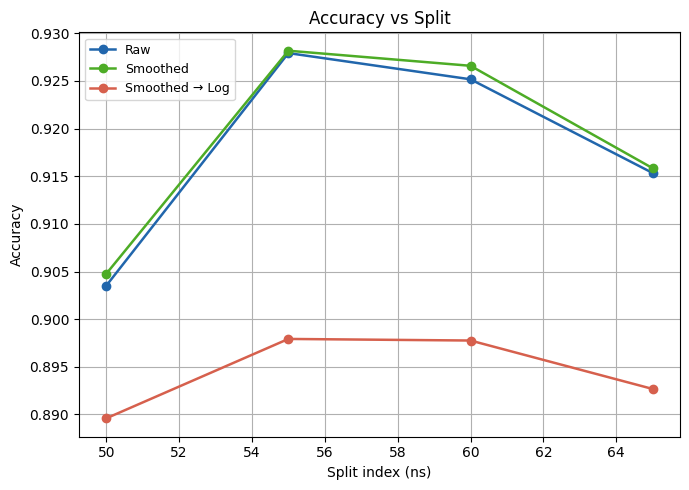

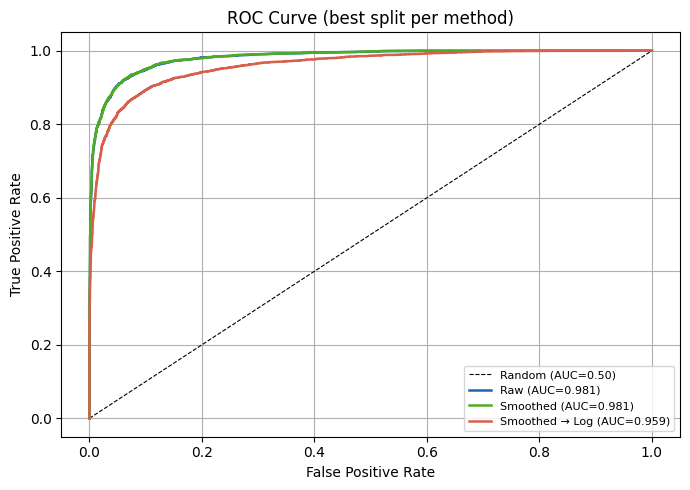

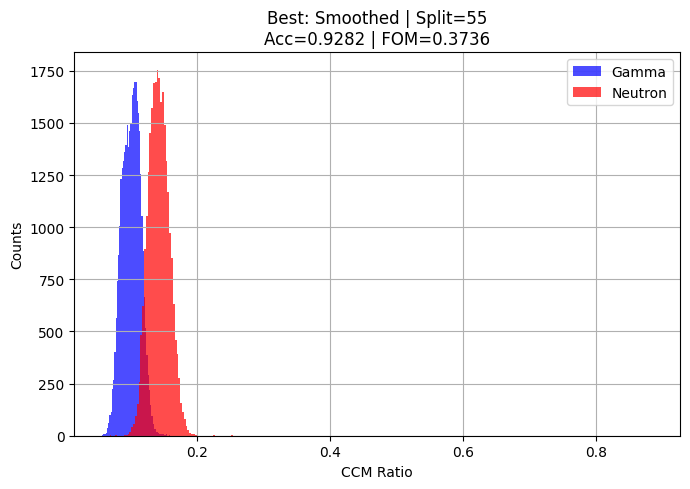

In [ ]:
# Final CCM Analysis Plot (Kuneh)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# ── Helper functions ──────────────────────────────────────────────────────────

def calculate_fom(gamma_data, neutron_data, bins=200):
    g_counts, g_edges = np.histogram(gamma_data, bins=bins)
    n_counts, n_edges = np.histogram(neutron_data, bins=bins)
    g_mids = (g_edges[:-1] + g_edges ) / 2
    n_mids = (n_edges[:-1] + n_edges ) / 2

    def get_fwhm(counts, mids):
        peak_idx  = np.argmax(counts)
        half_max  = counts[peak_idx] / 2
        left_idx  = np.where(counts[:peak_idx] <= half_max)[0]
        left_idx  = left_idx[-1] if len(left_idx) > 0 else 0
        right_idx = np.where(counts[peak_idx:] <= half_max)[0]
        right_idx = (right_idx[0] + peak_idx) if len(right_idx) > 0 else len(counts) - 1
        return mids[peak_idx], mids[right_idx] - mids[left_idx]

    g_peak, g_fwhm = get_fwhm(g_counts, g_mids)
    n_peak, n_fwhm = get_fwhm(n_counts, n_mids)
    return abs(n_peak - g_peak) / (g_fwhm + n_fwhm)


def get_accuracy_and_roc(gamma_ratio, neutron_ratio):
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([np.zeros(len(gamma_ratio)), np.ones(len(neutron_ratio))])

    mask = np.isfinite(X.ravel())
    X, y = X[mask], y[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    clf = LogisticRegression()
    clf.fit(X_train, y_train)
    y_pred      = clf.predict(X_test)
    y_prob      = clf.predict_proba(X_test)[:, 1]
    acc         = accuracy_score(y_test, y_pred)
    auc         = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    return acc, auc, fpr, tpr


def moving_average(df, window=5):
    return df.T.rolling(window=window, center=True, min_periods=1).mean().T


def compute_ratio_raw(df, split_local):
    short = df.iloc[:, :split_local].sum(axis=1)
    long_ = df.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


def compute_ratio_smoothed(df, split_local, window=5):
    df_s  = moving_average(df, window)
    short = df_s.iloc[:, :split_local].sum(axis=1)
    long_ = df_s.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


def compute_ratio_smoothed_log(df, split_local, window=5, eps=1e-10):
    df_s   = moving_average(df, window)
    df_s   = df_s.clip(lower=eps)
    df_log = np.log(df_s)
    df_log = df_log.clip(lower=0)
    short  = df_log.iloc[:, :split_local].sum(axis=1)
    long_  = df_log.iloc[:, split_local:].sum(axis=1)
    total  = long_ + short
    ratio  = (long_ / total.replace(0, np.nan)).abs()
    return ratio.fillna(0)


# ── Parameters ────────────────────────────────────────────────────────────────

short_start = 25
long_end    = 105
splits      = [50, 55, 60, 65]
methods     = ['Raw', 'Smoothed', 'Smoothed → Log']
colors      = {
    'Raw':            '#2166AC',
    'Smoothed':       '#4DAC26',
    'Smoothed → Log': '#D6604D'
}

df_gamma   = df_expanded_gamma.iloc[:, short_start:long_end].copy()
df_neutron = df_expanded_neutron.iloc[:, short_start:long_end].copy()

# ── Collect results ───────────────────────────────────────────────────────────

results = {m: {'acc': [], 'auc': [], 'fpr': [], 'tpr': [],
               'g_ratio': [], 'n_ratio': []} for m in methods}

for split in splits:
    split_local = split - short_start

    for method in methods:
        if method == 'Raw':
            g_ratio = compute_ratio_raw(df_gamma,   split_local)
            n_ratio = compute_ratio_raw(df_neutron, split_local)
        elif method == 'Smoothed':
            g_ratio = compute_ratio_smoothed(df_gamma,   split_local)
            n_ratio = compute_ratio_smoothed(df_neutron, split_local)
        else:
            g_ratio = compute_ratio_smoothed_log(df_gamma,   split_local)
            n_ratio = compute_ratio_smoothed_log(df_neutron, split_local)

        acc, auc, fpr, tpr = get_accuracy_and_roc(g_ratio, n_ratio)

        results[method]['acc'].append(acc)
        results[method]['auc'].append(auc)
        results[method]['fpr'].append(fpr)
        results[method]['tpr'].append(tpr)
        results[method]['g_ratio'].append(g_ratio)
        results[method]['n_ratio'].append(n_ratio)

        print(f"[{method}] Split={split} | Acc={acc:.4f} | AUC={auc:.4f}")

# ── Find best method + split by accuracy ─────────────────────────────────────

best_acc       = 0
best_method    = None
best_split_idx = 0

for method in methods:
    for si, acc in enumerate(results[method]['acc']):
        if acc > best_acc:
            best_acc       = acc
            best_method    = method
            best_split_idx = si

best_split = splits[best_split_idx]
print(f"\nBest: {best_method} @ split={best_split} | Acc={best_acc:.4f}")

def best_split_for(method):
    return int(np.argmax(results[method]['acc']))

# ── Plot 1: Accuracy vs Split ─────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(7, 5))
for method in methods:
    ax1.plot(splits, results[method]['acc'], marker='o',
             label=method, color=colors[method], linewidth=1.8)
ax1.set_xlabel("Split index (ns)")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy vs Split")
ax1.legend(fontsize=9)
ax1.grid(True)
for spine in ax1.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 2: ROC curves ────────────────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
for method in methods:
    si  = best_split_for(method)
    fpr = results[method]['fpr'][si]
    tpr = results[method]['tpr'][si]
    auc = results[method]['auc'][si]
    ax2.plot(fpr, tpr, color=colors[method], linewidth=1.8,
             label=f"{method} (AUC={auc:.3f})")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve (best split per method)")
ax2.legend(fontsize=8)
ax2.grid(True)
for spine in ax2.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 3: Histogram for best method + split ─────────────────────────────────

g_best = results[best_method]['g_ratio'][best_split_idx]
n_best = results[best_method]['n_ratio'][best_split_idx]
fom    = calculate_fom(g_best, n_best)

fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.hist(g_best, bins=300, alpha=0.7, color='blue', label='Gamma')
ax3.hist(n_best, bins=300, alpha=0.7, color='red',  label='Neutron')
ax3.set_xlabel("CCM Ratio")
ax3.set_ylabel("Counts")
ax3.set_title(f"Best: {best_method} | Split={best_split}\n"
              f"Acc={best_acc:.4f} | FOM={fom:.4f}")
ax3.legend()
ax3.grid(True)
for spine in ax3.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

Pile up cases


In [234]:
from scipy.signal import find_peaks

def detect_pileup(df_smooth, drop_threshold=0.1, rise_threshold=0.3):
    pileup_indices = []
    
    for idx in range(len(df_smooth)):
        waveform       = df_smooth.iloc[idx, :].values.astype(float)
        max_amp        = waveform.max()
        first_peak_idx = np.argmax(waveform)

        # ── Check AFTER the main peak ──────────────────────────────────────
        tail    = waveform[first_peak_idx:]
        dropped = np.where(tail < drop_threshold * max_amp)[0]
        if len(dropped) > 0:
            first_drop_idx = dropped[0]
            post_drop      = tail[first_drop_idx:]
            if np.any(post_drop > rise_threshold * max_amp):
                pileup_indices.append(idx)
                continue

        # ── Check BEFORE the main peak ────────────────────────────────────
        pre_peak = waveform[:first_peak_idx]
        if len(pre_peak) == 0:
            continue
        dropped_pre = np.where(pre_peak < drop_threshold * max_amp)[0]
        if len(dropped_pre) == 0:
            continue
        last_drop_idx = dropped_pre[-1]
        pre_drop      = pre_peak[:last_drop_idx]
        if np.any(pre_drop > rise_threshold * max_amp):
            pileup_indices.append(idx)

    return pileup_indices


def _plot_pileup(df_raw, df_smooth, pileup_indices, label, color,
                 drop_threshold, rise_threshold, n_samples):
    if len(pileup_indices) == 0:
        print(f"No pile-up detected for {label}")
        return

    sample_indices = np.random.choice(pileup_indices,
                                       min(n_samples, len(pileup_indices)),
                                       replace=False)
    fig, axes = plt.subplots(len(sample_indices), 2,
                              figsize=(14, len(sample_indices) * 3))
    if len(sample_indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(sample_indices):
        raw      = df_raw.iloc[idx, :995].values.astype(float)
        smoothed = df_smooth.iloc[idx, :995].values.astype(float)
        max_amp  = smoothed.max()

        for col, data, title_suffix in zip(
            [0, 1], [raw, smoothed], ['Raw', 'Smoothed']
        ):
            axes[i, col].plot(data, color=color, linewidth=1.2,
                               linestyle='-' if col == 0 else '--',
                               label=title_suffix)
            axes[i, col].axhline(drop_threshold * max_amp, color='orange',
                                  linewidth=0.8, linestyle='--',
                                  label=f'Drop ({drop_threshold}×max)')
            axes[i, col].axhline(rise_threshold * max_amp, color='green',
                                  linewidth=0.8, linestyle='--',
                                  label=f'Rise ({rise_threshold}×max)')
            axes[i, col].axvline(np.argmax(smoothed), color='red',
                                  linewidth=1.0, linestyle=':', label='Main peak')
            axes[i, col].set_title(f"{label} #{idx} — {title_suffix}")
            axes[i, col].set_xlabel("Time (ns)")
            axes[i, col].set_ylabel("Amplitude")
            axes[i, col].legend(fontsize=7)
            axes[i, col].grid(True)
            for spine in axes[i, col].spines.values():
                spine.set_visible(True)

    plt.suptitle(f"Pile-up — {label} | drop={drop_threshold} | "
                 f"rise={rise_threshold} | N={len(pileup_indices)}",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"pileup_{label.lower()}_drop{drop_threshold}_rise{rise_threshold}.png",
                dpi=150, bbox_inches='tight')
    plt.show()


def iterative_pileup_removal(window=5):
    global df_clean_gamma, df_clean_neutron

    # ── Initialise clean dataframes if not already existing ───────────────
    try:
        df_clean_gamma
        print(f"Continuing from existing clean dataframes — "
              f"Gamma: {len(df_clean_gamma)} | Neutron: {len(df_clean_neutron)}")
    except NameError:
        df_clean_gamma   = df_expanded_gamma.copy()
        df_clean_neutron = df_expanded_neutron.copy()
        print(f"Initialising clean dataframes — "
              f"Gamma: {len(df_clean_gamma)} | Neutron: {len(df_clean_neutron)}")

    drop_threshold = float(input("Enter drop threshold (e.g. 0.1): "))
    rise_threshold = float(input("Enter rise threshold (e.g. 0.3): "))
    n_samples      = int(input("Number of sample pulses to plot (e.g. 6): "))

    # ── Smooth current clean dataframes ───────────────────────────────────
    df_smooth_clean_gamma   = moving_average(df_clean_gamma,   window=window)
    df_smooth_clean_neutron = moving_average(df_clean_neutron, window=window)

    # ── Detect pile-up ─────────────────────────────────────────────────────
    pileup_gamma   = detect_pileup(df_smooth_clean_gamma,   drop_threshold, rise_threshold)
    pileup_neutron = detect_pileup(df_smooth_clean_neutron, drop_threshold, rise_threshold)

    print(f"\nGamma   — pile-up found: {len(pileup_gamma)} / {len(df_clean_gamma)} "
          f"({100*len(pileup_gamma)/len(df_clean_gamma):.2f}%)")
    print(f"Neutron — pile-up found: {len(pileup_neutron)} / {len(df_clean_neutron)} "
          f"({100*len(pileup_neutron)/len(df_clean_neutron):.2f}%)")

    # ── Plot samples ───────────────────────────────────────────────────────
    _plot_pileup(df_clean_gamma,   df_smooth_clean_gamma,
                 pileup_gamma,   'Gamma',   'blue',
                 drop_threshold, rise_threshold, n_samples)
    _plot_pileup(df_clean_neutron, df_smooth_clean_neutron,
                 pileup_neutron, 'Neutron', 'red',
                 drop_threshold, rise_threshold, n_samples)

    confirm = input("\nRemove these pile-up pulses from clean dataframes? (yes/no): ").strip().lower()

    if confirm == 'yes':
        df_clean_gamma = (df_clean_gamma
                          .drop(index=df_clean_gamma.index[pileup_gamma])
                          .reset_index(drop=True))
        df_clean_neutron = (df_clean_neutron
                            .drop(index=df_clean_neutron.index[pileup_neutron])
                            .reset_index(drop=True))
        print(f"\nRemoved successfully.")
        print(f"Clean dataframes now  — Gamma: {len(df_clean_gamma)} | "
              f"Neutron: {len(df_clean_neutron)}")
        print(f"Total removed so far  — Gamma: {len(df_expanded_gamma) - len(df_clean_gamma)} | "
              f"Neutron: {len(df_expanded_neutron) - len(df_clean_neutron)}")
    else:
        print("Not removed. Clean dataframes unchanged.")


# ── Run iterative removal — rerun this cell with different thresholds ─────────
iterative_pileup_removal(window=5)


Continuing from existing clean dataframes — Gamma: 33863 | Neutron: 26111

Gamma   — pile-up found: 0 / 33863 (0.00%)
Neutron — pile-up found: 0 / 26111 (0.00%)
No pile-up detected for Gamma
No pile-up detected for Neutron
Not removed. Clean dataframes unchanged.


Late peaks removal

In [171]:
def detect_and_remove_late_peak(threshold_idx=45, n_samples=6, window=5):
    """
    Detects pulses whose peak (argmax) occurs after threshold_idx.
    Plots samples, then asks if you want to remove them from clean dataframes.
    """
    global df_clean_gamma, df_clean_neutron

    # ── Initialise clean dataframes if not already existing ───────────────
    try:
        df_clean_gamma
        print(f"Continuing from existing clean dataframes — "
              f"Gamma: {len(df_clean_gamma)} | Neutron: {len(df_clean_neutron)}")
    except NameError:
        df_clean_gamma   = df_expanded_gamma.copy()
        df_clean_neutron = df_expanded_neutron.copy()
        print(f"Initialising clean dataframes — "
              f"Gamma: {len(df_clean_gamma)} | Neutron: {len(df_clean_neutron)}")

    # ── Smooth current clean dataframes ───────────────────────────────────
    df_smooth_clean_gamma   = moving_average(df_clean_gamma,   window=window)
    df_smooth_clean_neutron = moving_average(df_clean_neutron, window=window)

    # ── Detect late peak pulses ────────────────────────────────────────────
    def find_late_peaks(df_smooth):
        late_indices = []
        for idx in range(len(df_smooth)):
            waveform       = df_smooth.iloc[idx, :].values.astype(float)
            first_peak_idx = np.argmax(waveform)
            if first_peak_idx > threshold_idx:
                late_indices.append(idx)
        return late_indices

    late_gamma   = find_late_peaks(df_smooth_clean_gamma)
    late_neutron = find_late_peaks(df_smooth_clean_neutron)

    print(f"\nGamma   — late peak (argmax > {threshold_idx}): "
          f"{len(late_gamma)} / {len(df_clean_gamma)} "
          f"({100*len(late_gamma)/len(df_clean_gamma):.2f}%)")
    print(f"Neutron — late peak (argmax > {threshold_idx}): "
          f"{len(late_neutron)} / {len(df_clean_neutron)} "
          f"({100*len(late_neutron)/len(df_clean_neutron):.2f}%)")

    # ── Plot helper ───────────────────────────────────────────────────────
    def plot_late_peaks(df_raw, df_smooth, late_indices, label, color):
        if len(late_indices) == 0:
            print(f"No late peak pulses detected for {label}")
            return

        sample_indices = np.random.choice(late_indices,
                                           min(n_samples, len(late_indices)),
                                           replace=False)
        fig, axes = plt.subplots(len(sample_indices), 2,
                                  figsize=(14, len(sample_indices) * 3))
        if len(sample_indices) == 1:
            axes = np.expand_dims(axes, axis=0)

        for i, idx in enumerate(sample_indices):
            raw            = df_raw.iloc[idx, :995].values.astype(float)
            smoothed       = df_smooth.iloc[idx, :995].values.astype(float)
            peak_idx       = np.argmax(smoothed)

            for col, data, title_suffix in zip(
                [0, 1], [raw, smoothed], ['Raw', 'Smoothed']
            ):
                axes[i, col].plot(data, color=color, linewidth=1.2,
                                   linestyle='-' if col == 0 else '--',
                                   label=title_suffix)
                axes[i, col].axvline(peak_idx, color='red', linewidth=1.0,
                                      linestyle=':', label=f'Peak @ {peak_idx}')
                axes[i, col].axvline(threshold_idx, color='black', linewidth=1.0,
                                      linestyle='--', label=f'Threshold @ {threshold_idx}')
                axes[i, col].set_title(f"{label} #{idx} — {title_suffix} | peak @ {peak_idx}")
                axes[i, col].set_xlabel("Time (ns)")
                axes[i, col].set_ylabel("Amplitude")
                axes[i, col].legend(fontsize=7)
                axes[i, col].grid(True)
                for spine in axes[i, col].spines.values():
                    spine.set_visible(True)

        plt.suptitle(f"Late Peak Pulses — {label} | argmax > {threshold_idx} | "
                     f"N={len(late_indices)}",
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"late_peak_{label.lower()}_threshold{threshold_idx}.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

    # ── Plot ──────────────────────────────────────────────────────────────
    plot_late_peaks(df_clean_gamma,   df_smooth_clean_gamma,
                    late_gamma,   'Gamma',   'blue')
    plot_late_peaks(df_clean_neutron, df_smooth_clean_neutron,
                    late_neutron, 'Neutron', 'red')

    # ── Confirm removal ───────────────────────────────────────────────────
    confirm = input(f"\nRemove pulses with peak after index {threshold_idx} "
                    f"from clean dataframes? (yes/no): ").strip().lower()

    if confirm == 'yes':
        df_clean_gamma = (df_clean_gamma
                          .drop(index=df_clean_gamma.index[late_gamma])
                          .reset_index(drop=True))
        df_clean_neutron = (df_clean_neutron
                            .drop(index=df_clean_neutron.index[late_neutron])
                            .reset_index(drop=True))
        print(f"\nRemoved successfully.")
        print(f"Clean dataframes now  — Gamma: {len(df_clean_gamma)} | "
              f"Neutron: {len(df_clean_neutron)}")
        print(f"Total removed so far  — Gamma: {len(df_expanded_gamma) - len(df_clean_gamma)} | "
              f"Neutron: {len(df_expanded_neutron) - len(df_clean_neutron)}")
    else:
        print("Not removed. Clean dataframes unchanged.")


# ── Run — change threshold_idx and n_samples as needed ───────────────────────
detect_and_remove_late_peak(threshold_idx=45, n_samples=6, window=5)

Continuing from existing clean dataframes — Gamma: 33863 | Neutron: 26111

Gamma   — late peak (argmax > 45): 0 / 33863 (0.00%)
Neutron — late peak (argmax > 45): 0 / 26111 (0.00%)
No late peak pulses detected for Gamma
No late peak pulses detected for Neutron
Not removed. Clean dataframes unchanged.


Saving or calling the cleaned dataframes

In [ ]:
# '''saving df_clean'''
# df_clean_gamma.to_csv("Plastic Scintillator 2\df_clean_gamma.csv", index=False)
# df_clean_neutron.to_csv("Plastic Scintillator 2\df_clean_neutron.csv", index=False)
# print("Saved.")

# '''To load df_clean'''
# df_clean_gamma_AmBe   = pd.read_csv("Plastic Scintillator 2\df_clean_gamma_AmBe.csv")
# df_clean_neutron_AmBe = pd.read_csv("Plastic Scintillator 2\df_clean_neutron_AmBe.csv")
# print(f"Loaded — Gamma: {len(df_clean_gamma_AmBe)} | Neutron: {len(df_clean_neutron_AmBe)}")

Loaded — Gamma: 82129 | Neutron: 72059


── Original data ────────────────────────────────────────────────────────
Split=50 | Acc=0.9048 | AUC=0.9665
Split=55 | Acc=0.9282 | AUC=0.9813
Split=60 | Acc=0.9266 | AUC=0.9817
Split=65 | Acc=0.9158 | AUC=0.9779
── Clean data ───────────────────────────────────────────────────────────
Split=50 | Acc=0.9037 | AUC=0.9675
Split=55 | Acc=0.9288 | AUC=0.9824
Split=60 | Acc=0.9292 | AUC=0.9826
Split=65 | Acc=0.9218 | AUC=0.9789

Best split — Original: 55 (Acc=0.9282)
Best split — Clean:    60 (Acc=0.9292)


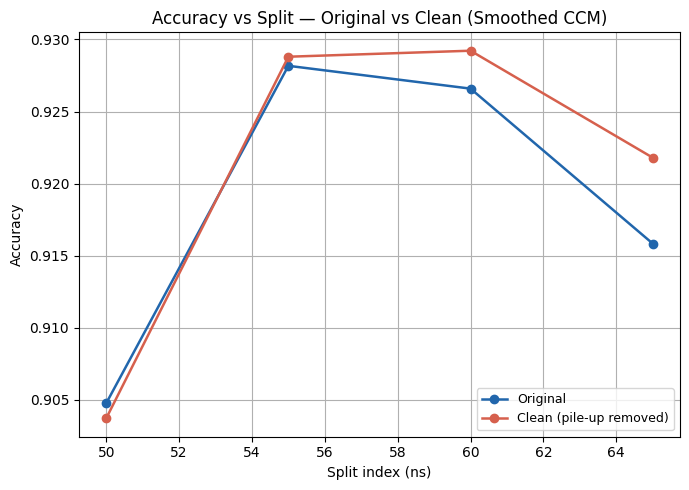

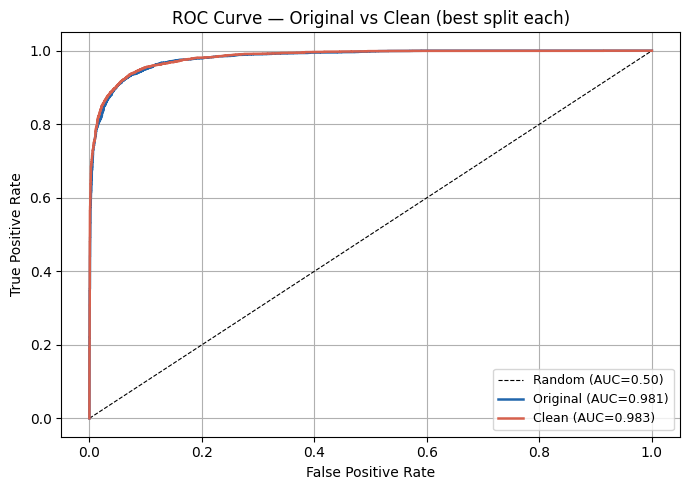

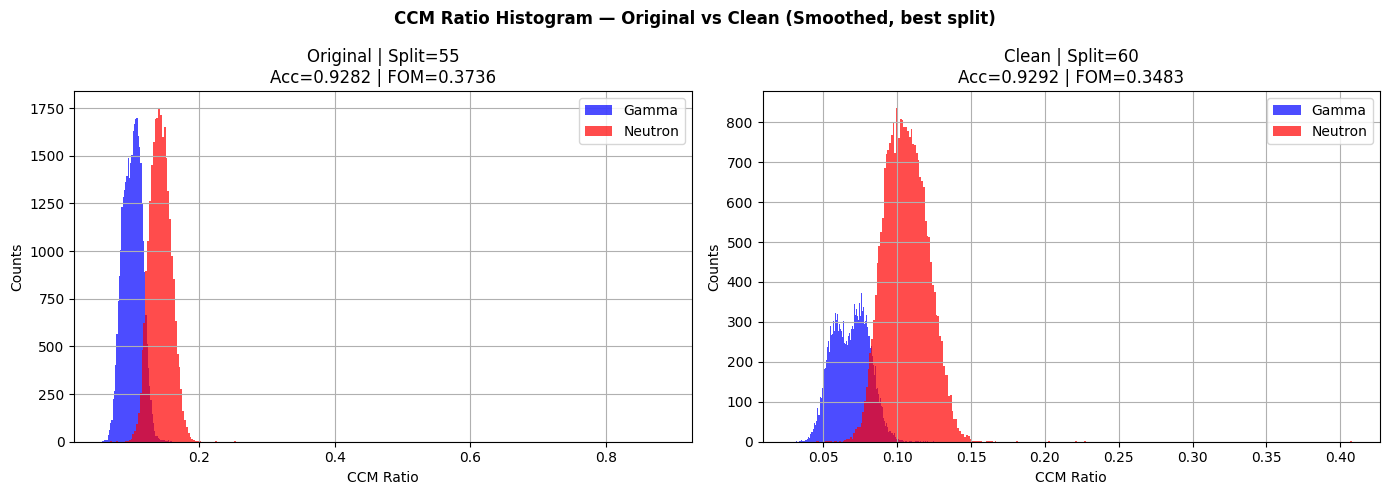

In [89]:
# ── Final Comparison: Original vs Clean Data (Kuneh) ─────────────────────────

short_start = 25
long_end    = 105
splits      = [50, 55, 60, 65]

colors = {
    'Original': '#2166AC',
    'Clean':    '#D6604D'
}

# ── Collect results for both datasets ────────────────────────────────────────

def run_ccm(df_g, df_n, splits, short_start, long_end):
    res = {'acc': [], 'auc': [], 'fpr': [], 'tpr': [], 'g_ratio': [], 'n_ratio': []}
    df_g_sliced = df_g.iloc[:, short_start:long_end].copy()
    df_n_sliced = df_n.iloc[:, short_start:long_end].copy()
    for split in splits:
        split_local = split - short_start
        g_ratio = compute_ratio_smoothed(df_g_sliced, split_local)
        n_ratio = compute_ratio_smoothed(df_n_sliced, split_local)
        acc, auc, fpr, tpr = get_accuracy_and_roc(g_ratio, n_ratio)
        res['acc'].append(acc)
        res['auc'].append(auc)
        res['fpr'].append(fpr)
        res['tpr'].append(tpr)
        res['g_ratio'].append(g_ratio)
        res['n_ratio'].append(n_ratio)
        print(f"Split={split} | Acc={acc:.4f} | AUC={auc:.4f}")
    return res

print("── Original data ────────────────────────────────────────────────────────")
res_original = run_ccm(df_expanded_gamma, df_expanded_neutron, splits, short_start, long_end)

print("── Clean data ───────────────────────────────────────────────────────────")
res_clean    = run_ccm(df_clean_gamma,    df_clean_neutron,    splits, short_start, long_end)

# ── Find best split per dataset ───────────────────────────────────────────────

best_split_orig_idx  = int(np.argmax(res_original['acc']))
best_split_clean_idx = int(np.argmax(res_clean['acc']))
best_split_orig      = splits[best_split_orig_idx]
best_split_clean     = splits[best_split_clean_idx]

print(f"\nBest split — Original: {best_split_orig} (Acc={res_original['acc'][best_split_orig_idx]:.4f})")
print(f"Best split — Clean:    {best_split_clean} (Acc={res_clean['acc'][best_split_clean_idx]:.4f})")

# ── Plot 1: Accuracy vs Split ─────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(splits, res_original['acc'], marker='o', linewidth=1.8,
         color=colors['Original'], label='Original')
ax1.plot(splits, res_clean['acc'],    marker='o', linewidth=1.8,
         color=colors['Clean'],    label='Clean (pile-up removed)')
ax1.set_xlabel("Split index (ns)")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy vs Split — Original vs Clean (Smoothed CCM)")
ax1.legend(fontsize=9)
ax1.grid(True)
for spine in ax1.spines.values():
    spine.set_visible(True)
plt.tight_layout()

plt.show()

# ── Plot 2: ROC curves ────────────────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')

fpr_orig = res_original['fpr'][best_split_orig_idx]
tpr_orig = res_original['tpr'][best_split_orig_idx]
auc_orig = res_original['auc'][best_split_orig_idx]
ax2.plot(fpr_orig, tpr_orig, color=colors['Original'], linewidth=1.8,
         label=f"Original (AUC={auc_orig:.3f})")

fpr_clean = res_clean['fpr'][best_split_clean_idx]
tpr_clean = res_clean['tpr'][best_split_clean_idx]
auc_clean = res_clean['auc'][best_split_clean_idx]
ax2.plot(fpr_clean, tpr_clean, color=colors['Clean'], linewidth=1.8,
         label=f"Clean (AUC={auc_clean:.3f})")

ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve — Original vs Clean (best split each)")
ax2.legend(fontsize=9)
ax2.grid(True)
for spine in ax2.spines.values():
    spine.set_visible(True)
plt.tight_layout()

plt.show()

# ── Plot 3: Histograms side by side ──────────────────────────────────────────

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

g_orig = res_original['g_ratio'][best_split_orig_idx]
n_orig = res_original['n_ratio'][best_split_orig_idx]
fom_orig = calculate_fom(g_orig, n_orig)

axes3[0].hist(g_orig, bins=300, alpha=0.7, color='blue', label='Gamma')
axes3[0].hist(n_orig, bins=300, alpha=0.7, color='red',  label='Neutron')
axes3[0].set_xlabel("CCM Ratio")
axes3[0].set_ylabel("Counts")
axes3[0].set_title(f"Original | Split={best_split_orig}\n"
                   f"Acc={res_original['acc'][best_split_orig_idx]:.4f} | FOM={fom_orig:.4f}")
axes3[0].legend()
axes3[0].grid(True)
for spine in axes3[0].spines.values():
    spine.set_visible(True)

g_clean = res_clean['g_ratio'][best_split_clean_idx]
n_clean = res_clean['n_ratio'][best_split_clean_idx]
fom_clean = calculate_fom(g_clean, n_clean)

axes3[1].hist(g_clean, bins=300, alpha=0.7, color='blue', label='Gamma')
axes3[1].hist(n_clean, bins=300, alpha=0.7, color='red',  label='Neutron')
axes3[1].set_xlabel("CCM Ratio")
axes3[1].set_ylabel("Counts")
axes3[1].set_title(f"Clean | Split={best_split_clean}\n"
                   f"Acc={res_clean['acc'][best_split_clean_idx]:.4f} | FOM={fom_clean:.4f}")
axes3[1].legend()
axes3[1].grid(True)
for spine in axes3[1].spines.values():
    spine.set_visible(True)

plt.suptitle("CCM Ratio Histogram — Original vs Clean (Smoothed, best split)",
             fontsize=12, fontweight='bold')
plt.tight_layout()

plt.show()

Histogram plotting for original vs cleaned at the same split

60004.0
59974.0


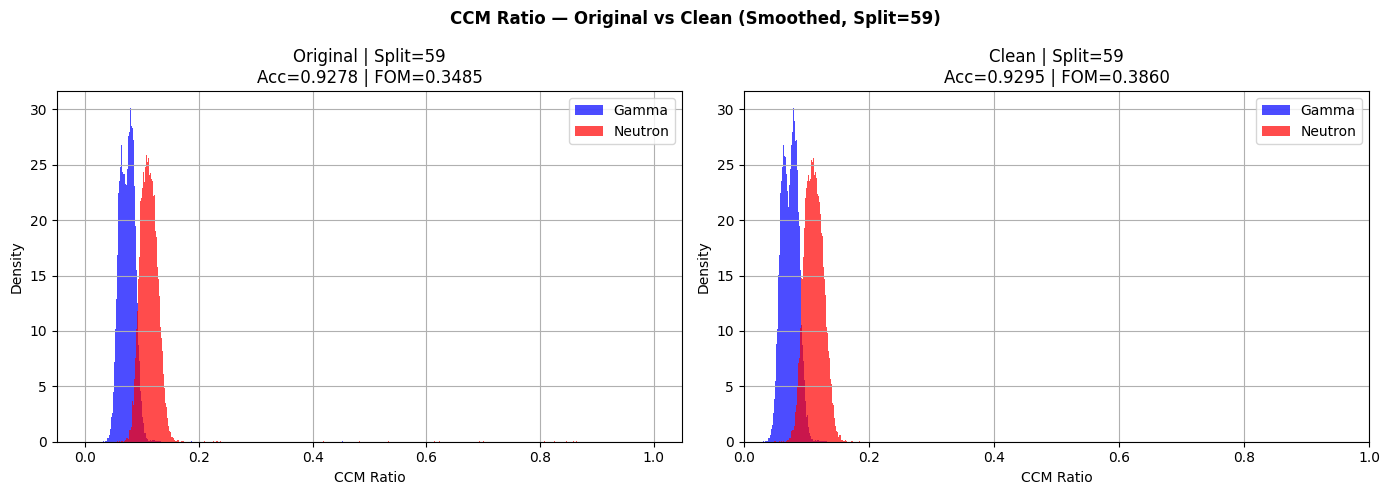

In [90]:
# ── Final Histogram Comparison: Original vs Clean at split=55 ────────────────

compare_split     = 59
split_local       = compare_split - short_start

# Original smoothed
df_g_orig = df_expanded_gamma.iloc[:, short_start:long_end].copy()
df_n_orig = df_expanded_neutron.iloc[:, short_start:long_end].copy()
g_ratio_orig = compute_ratio_smoothed(df_g_orig, split_local)
n_ratio_orig = compute_ratio_smoothed(df_n_orig, split_local)
fom_orig     = calculate_fom(g_ratio_orig, n_ratio_orig)
acc_orig, _, _, _ = get_accuracy_and_roc(g_ratio_orig, n_ratio_orig)

# Clean smoothed
df_g_clean = df_clean_gamma.iloc[:, short_start:long_end].copy()
df_n_clean = df_clean_neutron.iloc[:, short_start:long_end].copy()
g_ratio_clean = compute_ratio_smoothed(df_g_clean, split_local)
n_ratio_clean = compute_ratio_smoothed(df_n_clean, split_local)
fom_clean     = calculate_fom(g_ratio_clean, n_ratio_clean)
acc_clean, _, _, _ = get_accuracy_and_roc(g_ratio_clean, n_ratio_clean)

# ── Plot ──────────────────────────────────────────────────────────────────────
bin_width=0.001
bins_common = np.arange(0, 1 + bin_width, bin_width)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
print(float(len(g_ratio_orig)+len(n_ratio_orig)))
axes[0].hist(g_ratio_orig, bins=bins_common, alpha=0.7, color='blue', label='Gamma', density=True)
axes[0].hist(n_ratio_orig, bins=bins_common, alpha=0.7, color='red',  label='Neutron', density=True)
axes[0].set_xlabel("CCM Ratio")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Original | Split={compare_split}\n"
                  f"Acc={acc_orig:.4f} | FOM={fom_orig:.4f}")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)
print(float(len(g_ratio_clean)+len(n_ratio_clean)))
axes[1].hist(g_ratio_clean, bins=bins_common, alpha=0.7, color='blue', label='Gamma', density=True)
axes[1].hist(n_ratio_clean, bins=bins_common, alpha=0.7, color='red',  label='Neutron', density=True)
axes[1].set_xlim(0,1)
axes[1].set_xlabel("CCM Ratio")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Clean | Split={compare_split}\n"
                  f"Acc={acc_clean:.4f} | FOM={fom_clean:.4f}")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle(f"CCM Ratio — Original vs Clean (Smoothed, Split={compare_split})",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Charge Weighted comparison Method

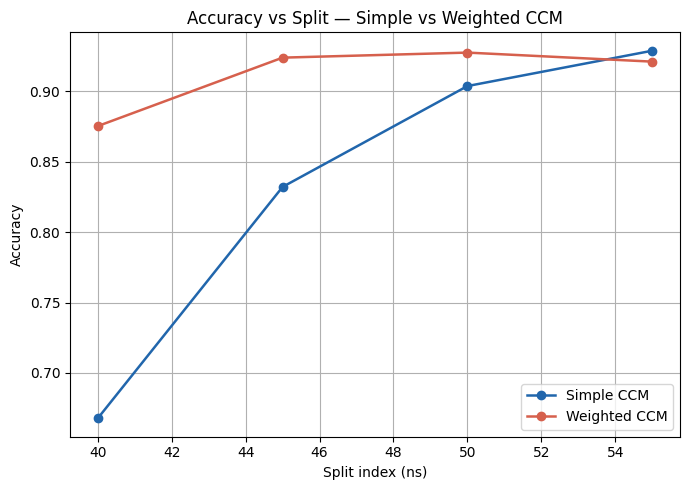

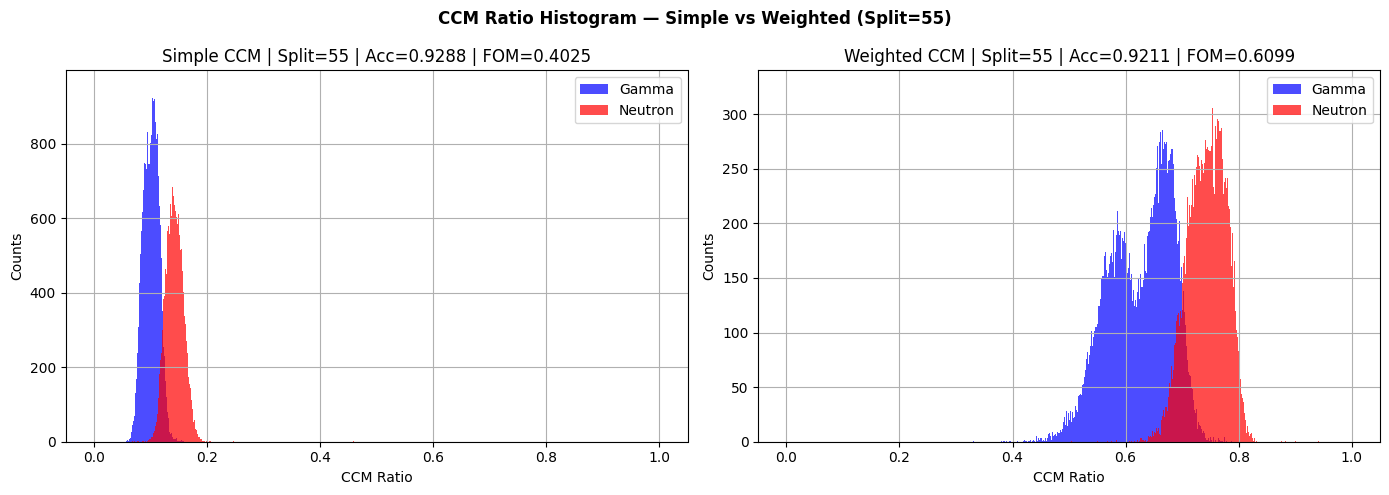

In [91]:
short_start = 25
long_end    = 105
splits      = list(range(40, 56, 5))
bin_width   = 0.001
bins_common = np.arange(0, 1 + bin_width, bin_width)

df_gamma   = df_clean_gamma.iloc[:, short_start:long_end].copy()
df_neutron = df_clean_neutron.iloc[:, short_start:long_end].copy()

def compute_ratio_smoothed(df, split_local, window=5):
    df_s  = moving_average(df, window)
    short = df_s.iloc[:, :split_local].sum(axis=1)
    long_ = df_s.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()
def compute_max(df,window=5):
    df_s    = moving_average(df, window)
    return df_s.max(axis=1)
def compute_charge(df,window=5):
    df_s    = moving_average(df, window)
    return df_s.sum(axis=1)
def compute_tail_curvature(df, window=5):
    df_s   = moving_average(df, window)
    curves = []
    for idx in range(len(df_s)):
        waveform  = df_s.iloc[idx, :].values.astype(float)
        peak_idx  = np.argmax(waveform)
        tail      = waveform[peak_idx:peak_idx+30]  # first 30 samples of tail
        # Fit a line to log(tail) — deviation from linearity = curvature
        log_tail  = np.log(np.clip(tail, 1e-10, None))
        x         = np.arange(len(log_tail))
        coeffs    = np.polyfit(x, log_tail, 2)  # quadratic fit
        curves.append(coeffs[0])                 # quadratic coefficient = curvature
    return pd.Series(curves)
def compute_ratio_smoothed_weighted(df, split_local, window=5):
    df_s      = moving_average(df, window)
    short     = df_s.iloc[:, :split_local].sum(axis=1)
    long_gate = df_s.iloc[:, split_local:]
    weights   = np.arange(1, long_gate.shape[1] + 1)
    long_w    = long_gate.multiply(weights, axis=1).sum(axis=1)
    return (long_w / (long_w + short)).abs()

results = {'Simple CCM':   {'acc': [], 'g_ratio': [], 'n_ratio': []},
           'Weighted CCM': {'acc': [], 'g_ratio': [], 'n_ratio': []}}

for split in splits:
    split_local = split - short_start
    g_simple   = compute_ratio_smoothed(df_gamma,   split_local)
    n_simple   = compute_ratio_smoothed(df_neutron, split_local)
    g_max = compute_max(df_gamma)
    n_max = compute_max(df_neutron)
    g_charge = compute_charge(df_gamma)
    n_charge = compute_charge(df_neutron)
    g_curvature = compute_tail_curvature(df_gamma)
    n_curvature = compute_tail_curvature(df_neutron)
    g_weighted = compute_ratio_smoothed_weighted(df_gamma,   split_local)
    n_weighted = compute_ratio_smoothed_weighted(df_neutron, split_local)
    results['Simple CCM']['acc'].append(get_accuracy_and_roc(g_simple,   n_simple)[0])
    results['Simple CCM']['g_ratio'].append(g_simple)
    results['Simple CCM']['n_ratio'].append(n_simple)
    results['Weighted CCM']['acc'].append(get_accuracy_and_roc(g_weighted, n_weighted)[0])
    results['Weighted CCM']['g_ratio'].append(g_weighted)
    results['Weighted CCM']['n_ratio'].append(n_weighted)

# ── Plot 1: Accuracy vs Split ─────────────────────────────────────────────────

plt.figure(figsize=(7, 5))
plt.plot(splits, results['Simple CCM']['acc'],   marker='o', linewidth=1.8, color='#2166AC', label='Simple CCM')
plt.plot(splits, results['Weighted CCM']['acc'], marker='o', linewidth=1.8, color='#D6604D', label='Weighted CCM')
plt.xlabel("Split index (ns)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Split — Simple vs Weighted CCM")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 2: Histogram at split=55 ────────────────────────────────────────────

si = splits.index(55)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, method in zip(axes, ['Simple CCM', 'Weighted CCM']):
    g, n  = results[method]['g_ratio'][si], results[method]['n_ratio'][si]
    ax.hist(g, bins=bins_common, alpha=0.7, color='blue', label='Gamma')
    ax.hist(n, bins=bins_common, alpha=0.7, color='red',  label='Neutron')
    ax.set_xlabel("CCM Ratio")
    ax.set_ylabel("Counts")
    ax.set_title(f"{method} | Split=55 | Acc={results[method]['acc'][si]:.4f} | FOM={calculate_fom(g, n):.4f}")
    ax.legend()
    ax.grid(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
plt.suptitle("CCM Ratio Histogram — Simple vs Weighted (Split=55)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Time domain

Gamma   slope — mean: -19.9476 | std: 5.5263
Neutron slope — mean: -15.6562 | std: 5.1836

Accuracy: 0.6774 | FOM: 2.9340


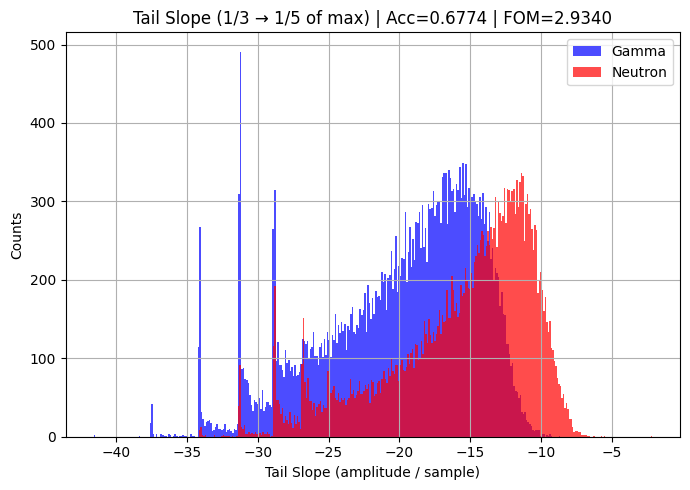

In [92]:
def compute_tail_slope(df, f1=1/2, f2=1/10, window=5):
    """
    For each pulse, computes the slope of the line joining:
    - index where pulse first drops to f1 * max AFTER peak
    - index where pulse first drops to f2 * max AFTER peak
    Slope = (f2*max - f1*max) / (idx_f2 - idx_f1)
    """
    df_s   = moving_average(df, window)
    slopes = []

    for idx in range(len(df_s)):
        waveform  = df_s.iloc[idx, :].values.astype(float)
        max_amp   = waveform.max()
        peak_idx  = np.argmax(waveform)
        post_peak = waveform[peak_idx:]

        # First index after peak where pulse drops to f1 * max
        below_f1 = np.where(post_peak < f1 * max_amp)[0]
        # First index after peak where pulse drops to f2 * max
        below_f2 = np.where(post_peak < f2 * max_amp)[0]

        if len(below_f1) == 0 or len(below_f2) == 0:
            slopes.append(np.nan)
            continue

        idx_f1 = below_f1[0]   # locked in at first crossing
        idx_f2 = below_f2[0]   # locked in at first crossing

        if idx_f2 == idx_f1:   # avoid division by zero
            slopes.append(np.nan)
            continue

        slope = (f2 * max_amp - f1 * max_amp) / (idx_f2 - idx_f1)
        slopes.append(slope)

    return pd.Series(slopes)


# ── Compute slopes ────────────────────────────────────────────────────────────

g_slope = compute_tail_slope(df_clean_gamma.iloc[:, short_start:long_end])
n_slope = compute_tail_slope(df_clean_neutron.iloc[:, short_start:long_end])

# Drop NaNs
g_slope = g_slope.dropna()
n_slope = n_slope.dropna()

print(f"Gamma   slope — mean: {g_slope.mean():.4f} | std: {g_slope.std():.4f}")
print(f"Neutron slope — mean: {n_slope.mean():.4f} | std: {n_slope.std():.4f}")

acc = get_accuracy(g_slope, n_slope)
fom = calculate_fom(g_slope, n_slope, bins=200)
print(f"\nAccuracy: {acc:.4f} | FOM: {fom:.4f}")

# ── Histogram ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(7, 5))
plt.hist(g_slope, bins=300, alpha=0.7, color='blue', label='Gamma')
plt.hist(n_slope, bins=300, alpha=0.7, color='red',  label='Neutron')
plt.xlabel("Tail Slope (amplitude / sample)")
plt.ylabel("Counts")
plt.title(f"Tail Slope (1/3 → 1/5 of max) | Acc={acc:.4f} | FOM={fom:.4f}")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

Non-Gaussian Fluctuation Parameter

Gamma   kappa — mean: 148448.6168 | std: 77348.5741
Neutron kappa — mean: 115204.4736 | std: 72291.1842

Accuracy: 0.6305 | FOM: 0.2131


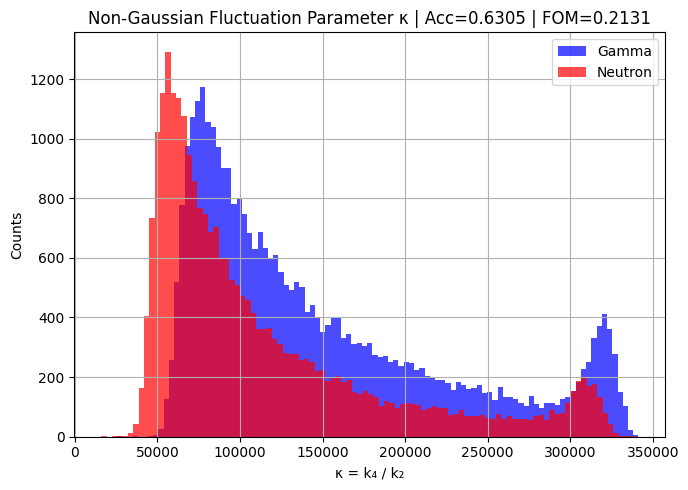

In [93]:
def compute_kappa(df, window=5):
    """
    Computes non-Gaussian fluctuation parameter kappa = k4 / k2
    where k2, k4 are the 2nd and 4th cumulants of the pulse amplitude distribution.
    """
    df_s    = moving_average(df, window)
    t_cols  = df_s.columns
    N       = len(t_cols)

    delta   = df_s.sub(df_s.mean(axis=1), axis=0)

    k2      = (delta ** 2).sum(axis=1) / N
    k4      = (delta ** 4).sum(axis=1) / N
    kappa   = k4 / k2

    return kappa.replace([np.inf, -np.inf], np.nan).dropna()


# ── Compute kappa ─────────────────────────────────────────────────────────────

g_kappa = compute_kappa(df_clean_gamma.iloc[:, short_start:long_end])
n_kappa = compute_kappa(df_clean_neutron.iloc[:, short_start:long_end])

print(f"Gamma   kappa — mean: {g_kappa.mean():.4f} | std: {g_kappa.std():.4f}")
print(f"Neutron kappa — mean: {n_kappa.mean():.4f} | std: {n_kappa.std():.4f}")

acc = get_accuracy(g_kappa, n_kappa)
fom = calculate_fom(g_kappa, n_kappa, bins=200)
print(f"\nAccuracy: {acc:.4f} | FOM: {fom:.4f}")

# ── Histogram ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(7, 5))
plt.hist(g_kappa, bins=100, alpha=0.7, color='blue', label='Gamma')
plt.hist(n_kappa, bins=100, alpha=0.7, color='red',  label='Neutron')
plt.xlabel("κ = k₄ / k₂")
plt.ylabel("Counts")
plt.title(f"Non-Gaussian Fluctuation Parameter κ | Acc={acc:.4f} | FOM={fom:.4f}")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()


Deep Neural Network


Using device: cpu
Epoch 001/100 | Train Loss: 0.2091 | Val Loss: 0.1199 | Test Acc: 0.9596
Epoch 002/100 | Train Loss: 0.0634 | Val Loss: 0.1526 | Test Acc: 0.9372
Epoch 003/100 | Train Loss: 0.0516 | Val Loss: 0.2745 | Test Acc: 0.8938
Epoch 004/100 | Train Loss: 0.0491 | Val Loss: 0.0810 | Test Acc: 0.9727
Epoch 005/100 | Train Loss: 0.0471 | Val Loss: 0.0803 | Test Acc: 0.9770
Epoch 006/100 | Train Loss: 0.0457 | Val Loss: 0.0262 | Test Acc: 0.9890
Epoch 007/100 | Train Loss: 0.0447 | Val Loss: 0.0943 | Test Acc: 0.9717
Epoch 008/100 | Train Loss: 0.0446 | Val Loss: 0.4775 | Test Acc: 0.8170
Epoch 009/100 | Train Loss: 0.0440 | Val Loss: 0.0351 | Test Acc: 0.9897
Epoch 010/100 | Train Loss: 0.0420 | Val Loss: 0.0552 | Test Acc: 0.9828
Epoch 011/100 | Train Loss: 0.0425 | Val Loss: 0.0338 | Test Acc: 0.9898
Epoch 012/100 | Train Loss: 0.0426 | Val Loss: 0.0616 | Test Acc: 0.9793
Epoch 013/100 | Train Loss: 0.0402 | Val Loss: 0.0438 | Test Acc: 0.9886
Epoch 014/100 | Train Loss: 0.038

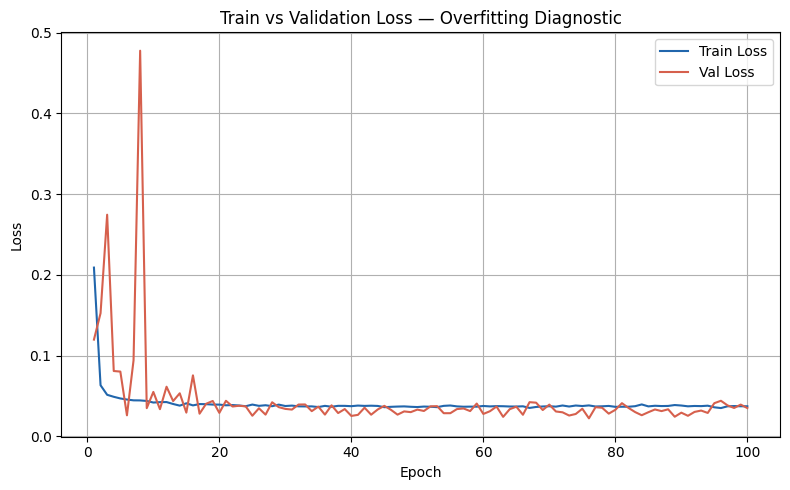

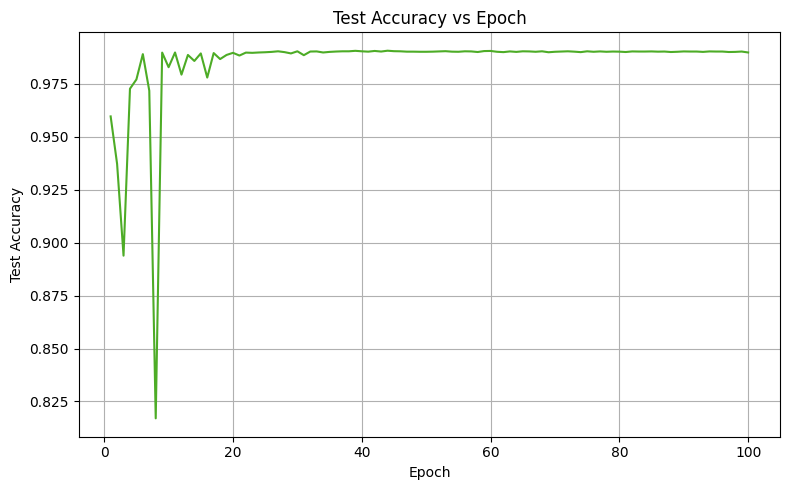

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler

# ── Prepare data ──────────────────────────────────────────────────────────────

window = 5
df_g = moving_average(df_clean_gamma.iloc[:,   short_start:long_end], window=window)
df_n = moving_average(df_clean_neutron.iloc[:, short_start:long_end], window=window)

X = np.concatenate([df_g.values, df_n.values], axis=0).astype(np.float32)
y = np.concatenate([np.zeros(len(df_g)), np.ones(len(df_n))]).astype(np.float32)
X = X / (X.max(axis=1, keepdims=True) + 1e-10)

# ── Split: 70% train+val, 30% test ───────────────────────────────────────────

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ── Further split train+val: 90% train, 10% val (per epoch) ──────────────────
# This is done dynamically each epoch via SubsetRandomSampler

n_trainval  = len(X_trainval)
indices     = np.arange(n_trainval)
n_val       = int(0.10 * n_trainval)

trainval_ds = TensorDataset(torch.tensor(X_trainval), torch.tensor(y_trainval))
test_ds     = TensorDataset(torch.tensor(X_test),     torch.tensor(y_test))
test_dl     = DataLoader(test_ds, batch_size=256, shuffle=False)

# ── DNN ───────────────────────────────────────────────────────────────────────

class PulseClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model     = PulseClassifier(input_dim=X_trainval.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ── Training ──────────────────────────────────────────────────────────────────

epochs      = 100
train_losses, val_losses, val_accs = [], [], []

for epoch in range(epochs):

    # Fresh random 90/10 split of trainval every epoch
    np.random.shuffle(indices)
    train_idx = indices[n_val:]
    val_idx   = indices[:n_val]

    train_dl = DataLoader(trainval_ds, batch_size=256,
                          sampler=SubsetRandomSampler(train_idx))
    val_dl   = DataLoader(trainval_ds, batch_size=256,
                          sampler=SubsetRandomSampler(val_idx))

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_dl)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            epoch_val_loss += loss.item()
    epoch_val_loss /= len(val_dl)

    # ── Test accuracy ─────────────────────────────────────────────────────────
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            probs = model(xb.to(device)).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend((probs > 0.5).astype(float))
            all_labels.extend(yb.numpy())

    acc = accuracy_score(all_labels, all_preds)
    scheduler.step(epoch_val_loss)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accs.append(acc)

    print(f"Epoch {epoch+1:03d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Test Acc: {acc:.4f}")

# ── Final metrics ─────────────────────────────────────────────────────────────

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
auc        = roc_auc_score(all_labels, all_probs)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
print(f"\nFinal Test Accuracy: {val_accs[-1]:.4f} | AUC: {auc:.4f}")

# ── Plot 1: Train vs Val Loss ─────────────────────────────────────────────────

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, color='#2166AC', linewidth=1.5, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses,   color='#D6604D', linewidth=1.5, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss — Overfitting Diagnostic")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 2: Test Accuracy ─────────────────────────────────────────────────────

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), val_accs, color='#4DAC26', linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Epoch")
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()


Train size=10% | Acc=0.7570
Train size=20% | Acc=0.9112
Train size=40% | Acc=0.9608
Train size=60% | Acc=0.9874
Train size=80% | Acc=0.8905


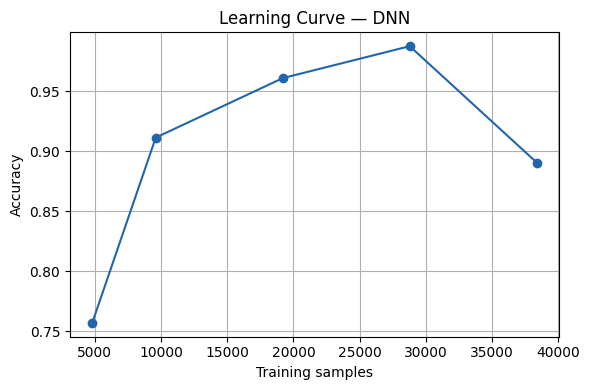

Shuffled label accuracy (should be ~0.50): 0.5646


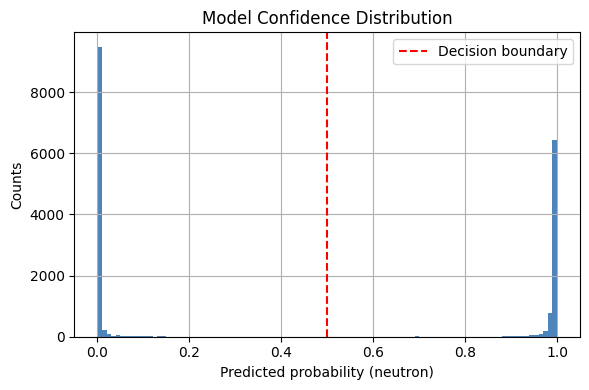

Misclassified: 184 / 17993


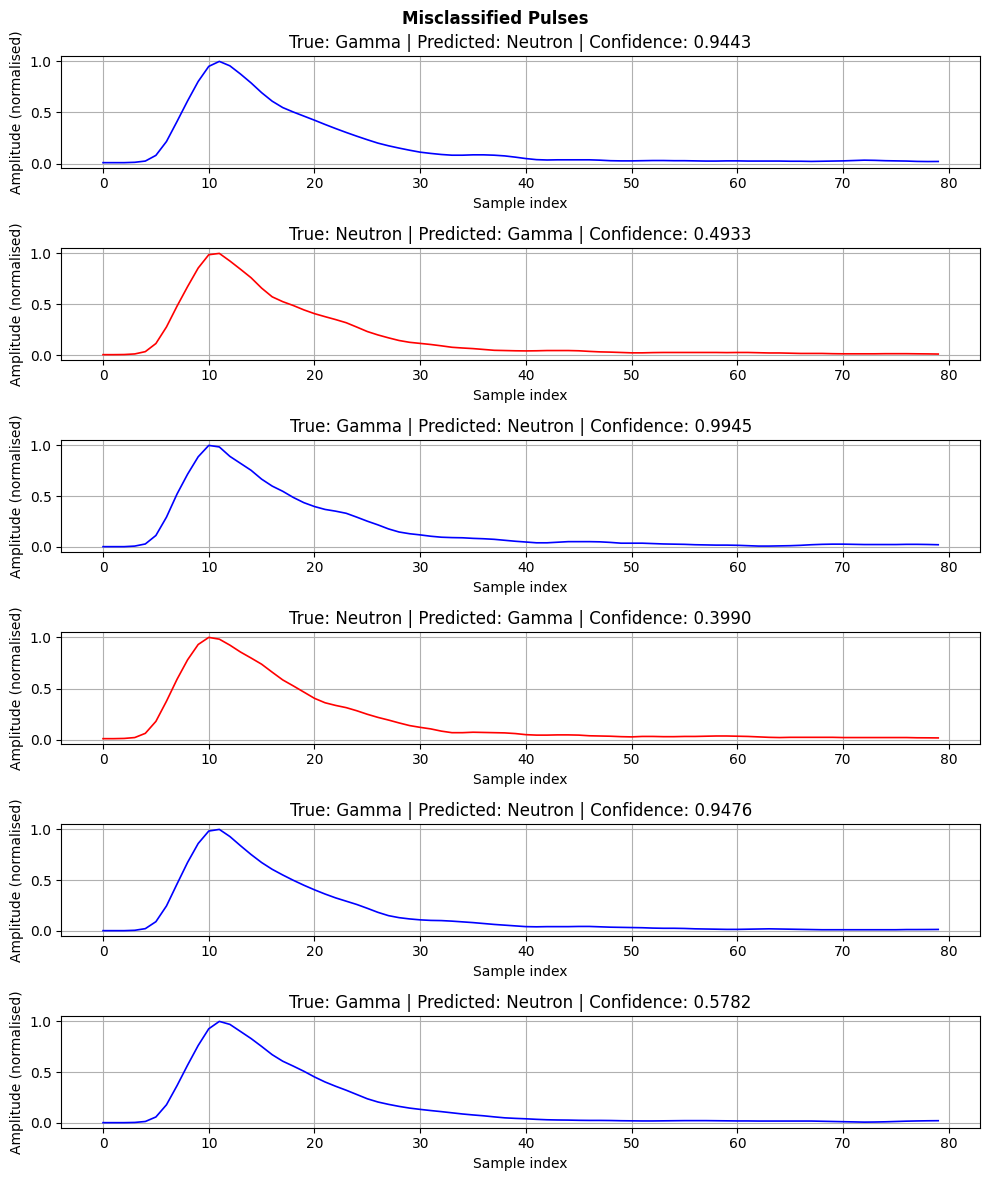

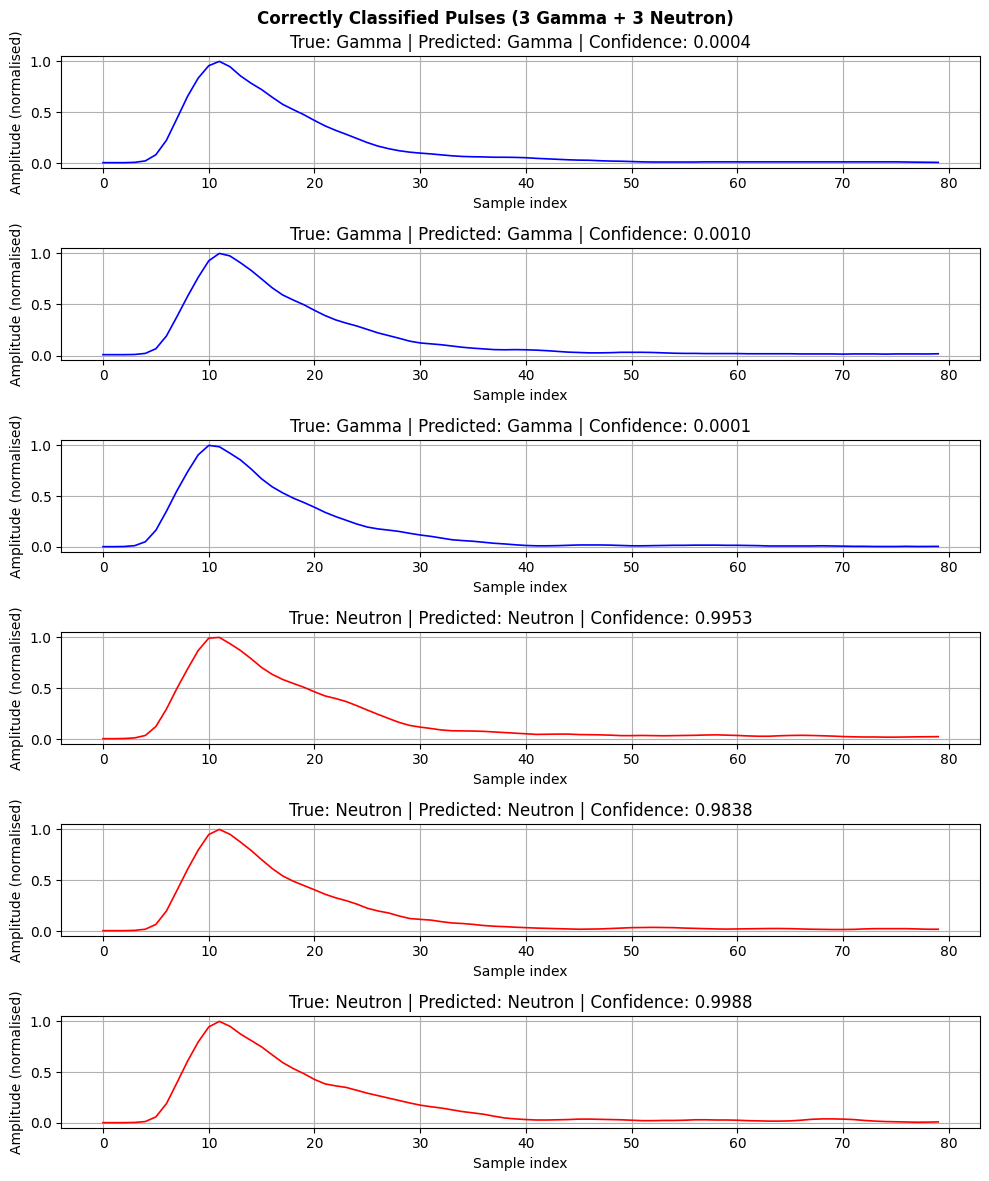

In [99]:
# ── Test 1: Learning curve ────────────────────────────────────────────────────

train_sizes = [0.1, 0.2, 0.4, 0.6, 0.8]
size_accs   = []

for size in train_sizes:
    X_tr, _, y_tr, _ = train_test_split(X_train, y_train,
                                         train_size=size,
                                         stratify=y_train,
                                         random_state=42)
    tr_ds = DataLoader(TensorDataset(torch.tensor(X_tr),
                                      torch.tensor(y_tr)),
                       batch_size=256, shuffle=True)
    m   = PulseClassifier(input_dim=X_train.shape[1]).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    m.train()
    for _ in range(10):
        for xb, yb in tr_ds:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            nn.BCELoss()(m(xb), yb).backward()
            opt.step()
    m.eval()
    preds = []
    with torch.no_grad():
        for xb, yb in test_dl:
            preds.extend((m(xb.to(device)).cpu().numpy() > 0.5).astype(float))
    size_accs.append(accuracy_score(all_labels, preds))
    print(f"Train size={size:.0%} | Acc={size_accs[-1]:.4f}")

plt.figure(figsize=(6, 4))
plt.plot([s * len(X_train) for s in train_sizes], size_accs, marker='o', color='#2166AC')
plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve — DNN")
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Test 2: Shuffle labels ────────────────────────────────────────────────────

y_shuffled = y_train.copy()
np.random.shuffle(y_shuffled)
shuf_ds = DataLoader(TensorDataset(torch.tensor(X_train),
                                    torch.tensor(y_shuffled)),
                     batch_size=256, shuffle=True)
m_shuf = PulseClassifier(input_dim=X_train.shape[1]).to(device)
opt    = torch.optim.Adam(m_shuf.parameters(), lr=1e-3)
m_shuf.train()
for _ in range(10):
    for xb, yb in shuf_ds:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        nn.BCELoss()(m_shuf(xb), yb).backward()
        opt.step()
m_shuf.eval()
shuf_preds = []
with torch.no_grad():
    for xb, yb in test_dl:
        shuf_preds.extend((m_shuf(xb.to(device)).cpu().numpy() > 0.5).astype(float))
print(f"Shuffled label accuracy (should be ~0.50): {accuracy_score(all_labels, shuf_preds):.4f}")

# ── Test 3: Confidence distribution ──────────────────────────────────────────

model.eval()
all_probs_test = []
with torch.no_grad():
    for xb, yb in test_dl:
        all_probs_test.extend(model(xb.to(device)).cpu().numpy())
all_probs_test = np.array(all_probs_test)

plt.figure(figsize=(6, 4))
plt.hist(all_probs_test, bins=100, color='#2166AC', alpha=0.8)
plt.axvline(0.5, color='red', linestyle='--', label='Decision boundary')
plt.xlabel("Predicted probability (neutron)")
plt.ylabel("Counts")
plt.title("Model Confidence Distribution")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Test 4: Misclassified pulses ──────────────────────────────────────────────

misclassified = np.where(np.array(all_preds) != all_labels)[0]
print(f"Misclassified: {len(misclassified)} / {len(all_labels)}")

if len(misclassified) > 0:
    fig, axes = plt.subplots(min(6, len(misclassified)), 1, figsize=(10, 12))
    if len(misclassified) == 1:
        axes = [axes]
    for i, idx in enumerate(misclassified[:6]):
        true_label = 'Neutron' if all_labels[idx] == 1 else 'Gamma'
        pred_label = 'Neutron' if all_preds[idx]  == 1 else 'Gamma'
        color      = 'red'  if true_label == 'Neutron' else 'blue'
        axes[i].plot(X_test[idx], color=color, linewidth=1.2)
        axes[i].set_title(f"True: {true_label} | Predicted: {pred_label} | "
                          f"Confidence: {all_probs_test[idx]:.4f}")
        axes[i].set_xlabel("Sample index")
        axes[i].set_ylabel("Amplitude (normalised)")
        axes[i].grid(True)
        for spine in axes[i].spines.values():
            spine.set_visible(True)
    plt.suptitle("Misclassified Pulses", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── Test 5: Correctly classified pulses ──────────────────────────────────────

correctly_classified = np.where(np.array(all_preds) == all_labels)[0]
correct_gamma   = [i for i in correctly_classified if all_labels[i] == 0]
correct_neutron = [i for i in correctly_classified if all_labels[i] == 1]
sample_correct  = (np.random.choice(correct_gamma,   3, replace=False).tolist() +
                   np.random.choice(correct_neutron, 3, replace=False).tolist())

fig, axes = plt.subplots(6, 1, figsize=(10, 12))
for i, idx in enumerate(sample_correct):
    true_label = 'Neutron' if all_labels[idx] == 1 else 'Gamma'
    color      = 'red' if true_label == 'Neutron' else 'blue'
    axes[i].plot(X_test[idx], color=color, linewidth=1.2)
    axes[i].set_title(f"True: {true_label} | Predicted: {true_label} | "
                      f"Confidence: {all_probs_test[idx]:.4f}")
    axes[i].set_xlabel("Sample index")
    axes[i].set_ylabel("Amplitude (normalised)")
    axes[i].grid(True)
    for spine in axes[i].spines.values():
        spine.set_visible(True)
plt.suptitle("Correctly Classified Pulses (3 Gamma + 3 Neutron)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

1D CNN


── Training DNN ─────────────────────────────────────────────────────────
  Epoch 01/20 | Loss: 0.1853 | Acc: 0.9841
  Epoch 02/20 | Loss: 0.0543 | Acc: 0.9472
  Epoch 03/20 | Loss: 0.0481 | Acc: 0.9652
  Epoch 04/20 | Loss: 0.0474 | Acc: 0.9840
  Epoch 05/20 | Loss: 0.0472 | Acc: 0.9612
  Epoch 06/20 | Loss: 0.0455 | Acc: 0.9742
  Epoch 07/20 | Loss: 0.0436 | Acc: 0.9892
  Epoch 08/20 | Loss: 0.0432 | Acc: 0.9853
  Epoch 09/20 | Loss: 0.0424 | Acc: 0.9897
  Epoch 10/20 | Loss: 0.0415 | Acc: 0.9882
  Epoch 11/20 | Loss: 0.0412 | Acc: 0.9891
  Epoch 12/20 | Loss: 0.0409 | Acc: 0.9543
  Epoch 13/20 | Loss: 0.0410 | Acc: 0.9902
  Epoch 14/20 | Loss: 0.0394 | Acc: 0.9885
  Epoch 15/20 | Loss: 0.0401 | Acc: 0.9691
  Epoch 16/20 | Loss: 0.0389 | Acc: 0.9891
  Epoch 17/20 | Loss: 0.0393 | Acc: 0.9821
  Epoch 18/20 | Loss: 0.0392 | Acc: 0.9890
  Epoch 19/20 | Loss: 0.0393 | Acc: 0.9860
  Epoch 20/20 | Loss: 0.0388 | Acc: 0.9800

── Training CNN ─────────────────────────────────────────────────

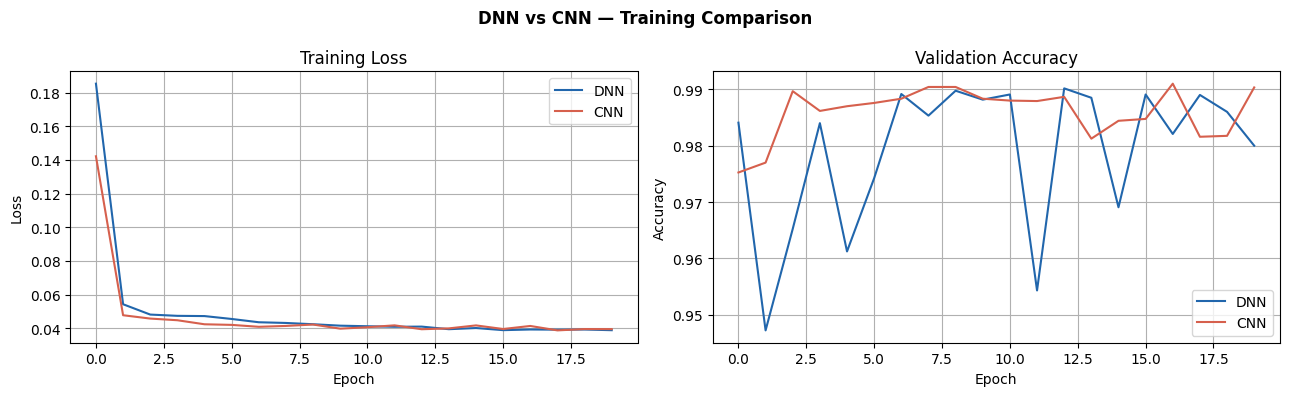

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Prepare data ──────────────────────────────────────────────────────────────

window = 5
df_g = moving_average(df_clean_gamma.iloc[:,   short_start:long_end], window=window)
df_n = moving_average(df_clean_neutron.iloc[:, short_start:long_end], window=window)

X = np.concatenate([df_g.values, df_n.values], axis=0).astype(np.float32)
y = np.concatenate([np.zeros(len(df_g)), np.ones(len(df_n))]).astype(np.float32)
X = X / (X.max(axis=1, keepdims=True) + 1e-10)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# DNN datasets — shape (N, 80)
train_dl_dnn = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
                           batch_size=256, shuffle=True)
test_dl_dnn  = DataLoader(TensorDataset(torch.tensor(X_test),  torch.tensor(y_test)),
                           batch_size=256, shuffle=False)

# CNN datasets — shape (N, 1, 80) — extra channel dimension
train_dl_cnn = DataLoader(TensorDataset(torch.tensor(X_train[:, None, :]), torch.tensor(y_train)),
                           batch_size=256, shuffle=True)
test_dl_cnn  = DataLoader(TensorDataset(torch.tensor(X_test[:, None, :]),  torch.tensor(y_test)),
                           batch_size=256, shuffle=False)

# ── DNN ───────────────────────────────────────────────────────────────────────

class PulseClassifierDNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

# ── 1D CNN ────────────────────────────────────────────────────────────────────

class PulseClassifierCNN(nn.Module):
    def __init__(self, input_len):
        super().__init__()
        self.conv = nn.Sequential(
            # Block 1 — learn local rise/fall patterns
            nn.Conv1d(1, 32, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(32),
            nn.MaxPool1d(2),                             # 80 → 40

            # Block 2 — learn mid-range tail features
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(64),
            nn.MaxPool1d(2),                              # 40 → 20

            # Block 3 — learn high-level decay shape
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(128),
            nn.MaxPool1d(2),                               # 20 → 10
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 10, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1),        nn.Sigmoid()
        )
    def forward(self, x):
        return self.fc(self.conv(x)).squeeze()

# ── Training function ─────────────────────────────────────────────────────────

def train_model(model, train_dl, test_dl, epochs=20, lr=3e-4):
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.BCELoss()

    train_losses, val_accs = [], []
    all_preds = all_probs = all_labels = None

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        preds, probs, labels = [], [], []
        with torch.no_grad():
            for xb, yb in test_dl:
                p = model(xb.to(device)).cpu().numpy()
                probs.extend(p)
                preds.extend((p > 0.5).astype(float))
                labels.extend(yb.numpy())

        acc      = accuracy_score(labels, preds)
        loss_avg = epoch_loss / len(train_dl)
        scheduler.step(loss_avg)
        train_losses.append(loss_avg)
        val_accs.append(acc)
        print(f"  Epoch {epoch+1:02d}/{epochs} | Loss: {loss_avg:.4f} | Acc: {acc:.4f}")

        all_preds, all_probs, all_labels = preds, np.array(probs), np.array(labels)

    auc         = roc_auc_score(all_labels, all_probs)
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    return train_losses, val_accs, all_preds, all_probs, all_labels, auc, fpr, tpr

# ── Train both ────────────────────────────────────────────────────────────────

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_len = X_train.shape[1]
epochs    = 20

print("── Training DNN ─────────────────────────────────────────────────────────")
dnn = PulseClassifierDNN(input_dim=input_len)
dnn_loss, dnn_acc, dnn_preds, dnn_probs, dnn_labels, dnn_auc, dnn_fpr, dnn_tpr = \
    train_model(dnn, train_dl_dnn, test_dl_dnn, epochs=epochs)

print("\n── Training CNN ─────────────────────────────────────────────────────────")
cnn = PulseClassifierCNN(input_len=input_len)
cnn_loss, cnn_acc, cnn_preds, cnn_probs, cnn_labels, cnn_auc, cnn_fpr, cnn_tpr = \
    train_model(cnn, train_dl_cnn, test_dl_cnn, epochs=epochs)

print(f"\nDNN — Final Acc: {dnn_acc[-1]:.4f} | AUC: {dnn_auc:.4f}")
print(f"CNN — Final Acc: {cnn_acc[-1]:.4f} | AUC: {cnn_auc:.4f}")

# ── Plot 1: Training curves ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(dnn_loss, color='#2166AC', linewidth=1.5, label='DNN')
axes[0].plot(cnn_loss, color='#D6604D', linewidth=1.5, label='CNN')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

axes[1].plot(dnn_acc, color='#2166AC', linewidth=1.5, label='DNN')
axes[1].plot(cnn_acc, color='#D6604D', linewidth=1.5, label='CNN')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("DNN vs CNN — Training Comparison", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [101]:
# Combine all your engineered features
features_gamma = np.column_stack([
    g_simple,    # CCM ratio
    g_weighted,  # weighted CCM ratio
    g_slope,           # tail slope
    g_max,         # peak width
    g_charge,
    g_curvature,
    g_kappa            # kappa
])

features_neutron = np.column_stack([
    n_simple,
    n_weighted,
    n_slope,
    n_max,
    n_charge,
    n_curvature,
    n_kappa
])

X = np.concatenate([features_gamma, features_neutron], axis=0)
y = np.concatenate([np.zeros(len(features_gamma)), np.ones(len(features_neutron))])

# Use Random Forest — handles non-linear combinations of features well
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest (all features) Accuracy: {acc:.4f}")

# Feature importance — tells you which feature matters most
importances = rf.feature_importances_
feature_names = ['CCM Simple', 'CCM Weighted', 'Tail Slope', 'peak amplitude','pulse charge','tail curvature', 'Kappa']
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"  {name}: {imp:.4f}")

Random Forest (all features) Accuracy: 0.9499
  CCM Simple: 0.4458
  CCM Weighted: 0.3198
  Tail Slope: 0.0621
  tail curvature: 0.0550
  pulse charge: 0.0438
  Kappa: 0.0370
  peak amplitude: 0.0365


DNN on set1 and applied on set2, also AmBe_gamma_pulses processed and saved to df_gamma_AmBe (2(ii))

Set 1 — Gamma: (33863, 997) | Neutron: (26111, 997)
Set 1 — X: (59974, 160) | y: (59974,)
Using device: cpu
Epoch 001/200 | Loss: 0.1978 | Acc: 0.9496
Epoch 002/200 | Loss: 0.0617 | Acc: 0.9876
Epoch 003/200 | Loss: 0.0400 | Acc: 0.9946
Epoch 004/200 | Loss: 0.0353 | Acc: 0.9468
Epoch 005/200 | Loss: 0.0340 | Acc: 0.9948
Epoch 006/200 | Loss: 0.0332 | Acc: 0.9955
Epoch 007/200 | Loss: 0.0325 | Acc: 0.9471
Epoch 008/200 | Loss: 0.0331 | Acc: 0.9868
Epoch 009/200 | Loss: 0.0333 | Acc: 0.9941
Epoch 010/200 | Loss: 0.0315 | Acc: 0.9934
Epoch 011/200 | Loss: 0.0314 | Acc: 0.9952
Epoch 012/200 | Loss: 0.0306 | Acc: 0.8940
Epoch 013/200 | Loss: 0.0299 | Acc: 0.9956
Epoch 014/200 | Loss: 0.0298 | Acc: 0.9956
Epoch 015/200 | Loss: 0.0307 | Acc: 0.9536
Epoch 016/200 | Loss: 0.0300 | Acc: 0.9722
Epoch 017/200 | Loss: 0.0293 | Acc: 0.9943
Epoch 018/200 | Loss: 0.0292 | Acc: 0.9959
Epoch 019/200 | Loss: 0.0297 | Acc: 0.9938
Epoch 020/200 | Loss: 0.0287 | Acc: 0.9952
Epoch 021/200 | Loss: 0.0303 | A

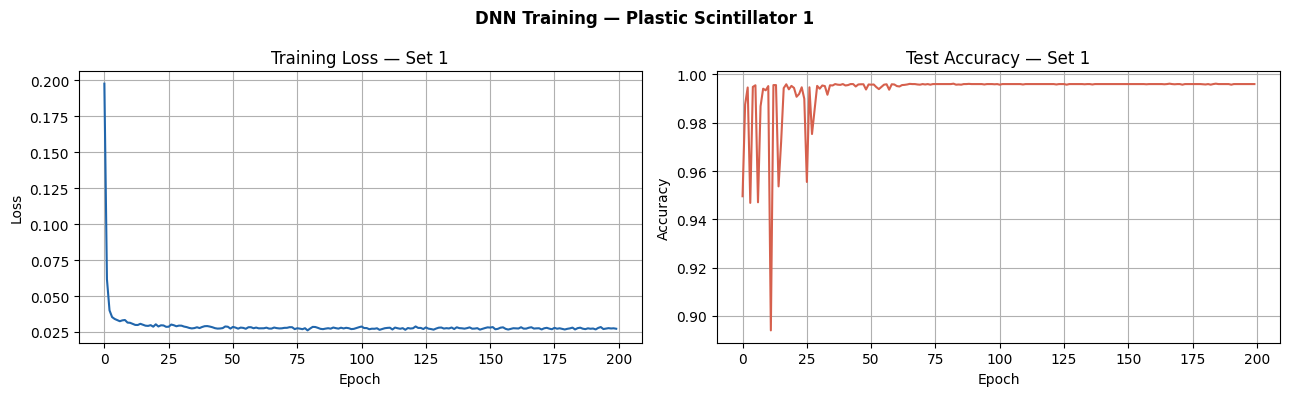

In [113]:
import pandas as pd
import csv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ── Gate window — change these to experiment ──────────────────────────────────
short_start = 25
long_end    = 185

# ── Step 1: Load Set 1 (already preprocessed) ────────────────────────────────


df_clean_gamma   = pd.read_csv("Plastic Scintillator 1\df_clean_gamma.csv")
df_clean_neutron = pd.read_csv("Plastic Scintillator 1\df_clean_neutron.csv")

print(f"Set 1 — Gamma: {df_clean_gamma.shape} | Neutron: {df_clean_neutron.shape}")

# ── Step 2: Prepare Set 1 training data ──────────────────────────────────────

def moving_average(df, window=5):
    return df.T.rolling(window=window, center=True, min_periods=1).mean().T

def preprocess_set1(df_g, df_n, short_start, long_end, window=5):
    """Smooth and slice gate window — Set 1 pulses are already baseline corrected."""
    df_g_s = moving_average(df_g.iloc[:, short_start:long_end], window=window)
    df_n_s = moving_average(df_n.iloc[:, short_start:long_end], window=window)
    X = np.concatenate([df_g_s.values, df_n_s.values], axis=0).astype(np.float32)
    y = np.concatenate([np.zeros(len(df_g_s)), np.ones(len(df_n_s))]).astype(np.float32)
    X = X / (X.max(axis=1, keepdims=True) + 1e-10)
    return X, y

X1, y1 = preprocess_set1(df_clean_gamma, df_clean_neutron, short_start, long_end)
print(f"Set 1 — X: {X1.shape} | y: {y1.shape}")

# ── Step 3: Train/test split on Set 1 ────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.2, stratify=y1, random_state=42
)

train_dl = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
                      batch_size=256, shuffle=True)
test_dl  = DataLoader(TensorDataset(torch.tensor(X_test),  torch.tensor(y_test)),
                      batch_size=256, shuffle=False)

# ── Step 4: DNN ───────────────────────────────────────────────────────────────

class PulseClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),       nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.4),
            nn.Linear(128,64),      nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3), 
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model     = PulseClassifier(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ── Step 5: Train on Set 1 ────────────────────────────────────────────────────

epochs     = 200
train_losses, val_accs = [], []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            p = model(xb.to(device)).cpu().numpy()
            preds.extend((p > 0.5).astype(float))
            labels.extend(yb.numpy())

    acc      = accuracy_score(labels, preds)
    loss_avg = epoch_loss / len(train_dl)
    scheduler.step(loss_avg)
    train_losses.append(loss_avg)
    val_accs.append(acc)
    print(f"Epoch {epoch+1:03d}/{epochs} | Loss: {loss_avg:.4f} | Acc: {acc:.4f}")

print(f"\nSet 1 Test Accuracy: {val_accs[-1]:.4f}")

# ── Step 6: Load and preprocess Set 2 ────────────────────────────────────────


# def load_and_preprocess_set2(file_paths):
#     parsed_data = []
#     for file_path in file_paths:
#         with open(file_path, 'r') as f:
#             csv_reader = csv.reader(f, delimiter=';')
#             next(csv_reader)
#             for row in csv_reader:
#                 if not row:
#                     continue
#                 parsed_data.append({
#                     'BOARD':       row[0],
#                     'CHANNEL':     row[1],
#                     'TIMETAG':     row[2],
#                     'ENERGY':      row[3],
#                     'ENERGYSHORT': row[4],
#                     'FLAGS':       row[5],
#                     'SAMPLES':     row[6:]
#                 })

#     df = pd.DataFrame(parsed_data)

#     # Expand samples into t-columns
#     samples_df  = pd.DataFrame(df['SAMPLES'].tolist()).add_prefix('t')
#     df_expanded = pd.concat([df.drop(columns=['SAMPLES']), samples_df], axis=1)

#     # Ensure numeric
#     t_cols = df_expanded.filter(regex=r'^t').columns
#     df_expanded[t_cols] = df_expanded[t_cols].apply(pd.to_numeric, errors='coerce')

#     # ── Defragment BEFORE adding t_max to avoid PerformanceWarning ───────────
#     df_expanded = df_expanded.copy()

#     # Baseline correction
#     t_max = df_expanded[t_cols].max(axis=1)
#     df_expanded[t_cols] = df_expanded[t_cols].sub(t_max, axis=0).abs()

#     # Drop metadata, keep only t-columns
#     df_expanded = df_expanded[t_cols]

#     return df_expanded

# print("\nLoading Set 2 gamma...")
# df_gamma_AmBe = load_and_preprocess_set2(["Plastic Scintillator 2/AmBe_gamma_pulses.csv"])

# print("Loading Set 2 neutron...")
# df_neutron_AmBe = load_and_preprocess_set2([
#     "Plastic Scintillator 2/AmBe_neutron_pulses-1.csv",
#     "Plastic Scintillator 2/AmBe_neutron_pulses-2.csv"])

# print(f"Set 2 — Gamma: {df_gamma_AmBe.shape} | Neutron: {df_neutron_AmBe.shape}")

# # ── Step 7: Save Set 2 clean dataframes ──────────────────────────────────────

# # Drop metadata columns — keep only pulse sample columns
# t_cols_g = df_gamma_AmBe.filter(regex=r'^t').columns
# t_cols_n = df_neutron_AmBe.filter(regex=r'^t').columns

# df_gamma_AmBe   = df_gamma_AmBe[t_cols_g]
# df_neutron_AmBe = df_neutron_AmBe[t_cols_n]

# print(f"After dropping metadata — Gamma: {df_gamma_AmBe.shape} | "
#       f"Neutron: {df_neutron_AmBe.shape}")

# df_gamma_AmBe.to_csv("Plastic Scintillator 2/df_gamma_AmBe.csv",   index=False)
# df_neutron_AmBe.to_csv("Plastic Scintillator 2/df_neutron_AmBe.csv", index=False)
# print("Saved.")

# ── Step 8: Smooth and slice gate window for Set 2 (df_clean_gamma_AmBe used instead of df_gamma_AmBe)───────────────────────────

def preprocess_set2(df_g, df_n, short_start, long_end, window=5):
    """df_g and df_n are already t-columns only."""
    df_g_smooth = moving_average(df_g.iloc[:, 15:long_end-10], window=window)
    df_n_smooth = moving_average(df_n.iloc[:, 15:long_end-10], window=window)
    X = np.concatenate([df_g_smooth.values, df_n_smooth.values], axis=0).astype(np.float32)
    y = np.concatenate([np.zeros(len(df_g_smooth)), np.ones(len(df_n_smooth))]).astype(np.float32)
    X = X / (X.max(axis=1, keepdims=True) + 1e-10)
    return X, y

X2, y2 = preprocess_set2(df_clean_gamma_AmBe, df_clean_neutron_AmBe, short_start, long_end)
print(f"\nSet 2 — X: {X2.shape} | y: {y2.shape}")

# ── Step 9: Dimension check ───────────────────────────────────────────────────

print(f"Set 1 input dim: {X_train.shape[1]} | Set 2 input dim: {X2.shape[1]}")
assert X2.shape[1] == X_train.shape[1], \
    f"Dimension mismatch — Set1: {X_train.shape[1]}, Set2: {X2.shape[1]}"

# ── Step 10: Inference on Set 2 — no retraining ───────────────────────────────

test2_dl = DataLoader(TensorDataset(torch.tensor(X2), torch.tensor(y2)),
                      batch_size=256, shuffle=False)

model.eval()  # weights frozen, no gradient updates
all_preds2, all_probs2, all_labels2 = [], [], []

with torch.no_grad():
    for xb, yb in test2_dl:
        probs = model(xb.to(device)).cpu().numpy()
        all_probs2.extend(probs)
        all_preds2.extend((probs > 0.5).astype(float))
        all_labels2.extend(yb.numpy())

all_probs2  = np.array(all_probs2)
all_labels2 = np.array(all_labels2)
acc2        = accuracy_score(all_labels2, all_preds2)
auc2        = roc_auc_score(all_labels2, all_probs2)
fpr2, tpr2, _ = roc_curve(all_labels2, all_probs2)

print(f"\nSet 2 Inference — Accuracy: {acc2:.4f} | AUC: {auc2:.4f}")

# ── Plot 1: Training curve ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, color='#2166AC', linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss — Set 1")
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

axes[1].plot(val_accs, color='#D6604D', linewidth=1.5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Test Accuracy — Set 1")
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("DNN Training — Plastic Scintillator 1", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# # ── Plot 2: ROC comparison ────────────────────────────────────────────────────

# # Set 1 test ROC
# model.eval()
# probs1, labels1 = [], []
# with torch.no_grad():
#     for xb, yb in test_dl:
#         p = model(xb.to(device)).cpu().numpy()
#         probs1.extend(p)
#         labels1.extend(yb.numpy())
# probs1  = np.array(probs1)
# labels1 = np.array(labels1)
# auc1    = roc_auc_score(labels1, probs1)
# fpr1, tpr1, _ = roc_curve(labels1, probs1)

# plt.figure(figsize=(6, 5))
# plt.plot(fpr1, tpr1, color='#2166AC', linewidth=1.8,
#          label=f"Set 1 test  (AUC={auc1:.3f})")
# plt.plot(fpr2, tpr2, color='#D6604D', linewidth=1.8,
#          label=f"Set 2 infer (AUC={auc2:.3f})")
# plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC — Set 1 Test vs Set 2 Inference")
# plt.legend(fontsize=9)
# plt.grid(True)
# for spine in plt.gca().spines.values():
#     spine.set_visible(True)
# plt.tight_layout()
# plt.show()

# # ── Plot 3: Confidence distribution — Set 2 ──────────────────────────────────

# plt.figure(figsize=(7, 4))
# plt.hist(all_probs2[all_labels2 == 0], bins=100, alpha=0.7,
#          color='blue', label='Gamma')
# plt.hist(all_probs2[all_labels2 == 1], bins=100, alpha=0.7,
#          color='red',  label='Neutron')
# plt.axvline(0.5, color='black', linestyle='--', linewidth=0.8,
#             label='Decision boundary')
# plt.xlabel("Predicted probability (neutron)")
# plt.ylabel("Counts")
# plt.title(f"Confidence Distribution — Set 2\nAcc={acc2:.4f} | AUC={auc2:.4f}")
# plt.legend()
# plt.grid(True)
# for spine in plt.gca().spines.values():
#     spine.set_visible(True)
# plt.tight_layout()
# plt.show()




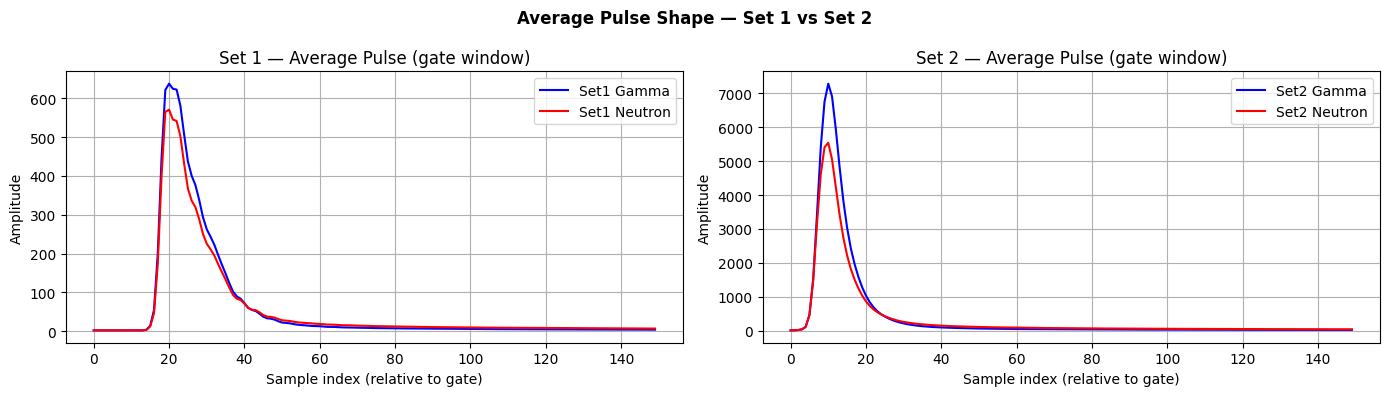

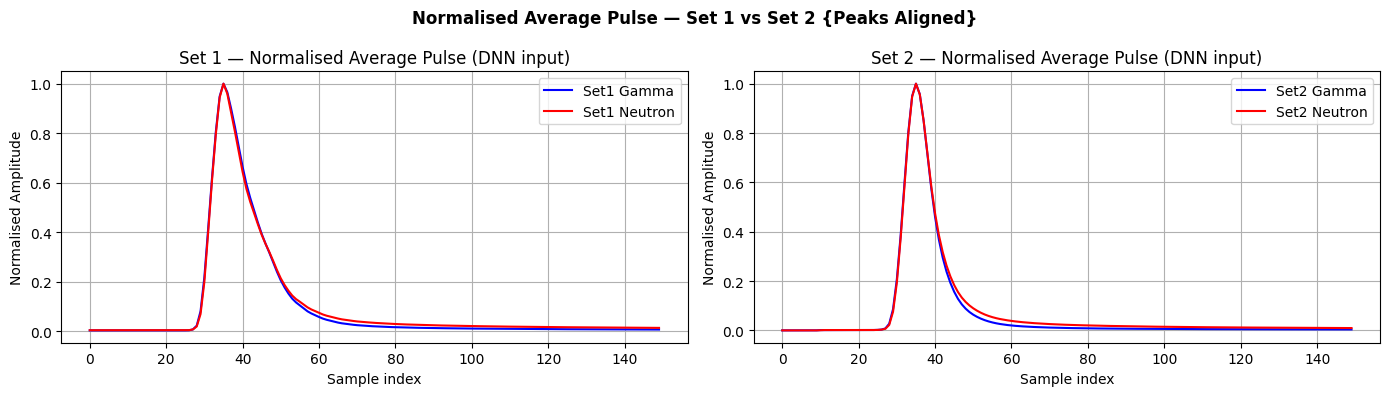

── Set 1 (normalised, gate window) ──────────────────────────────────────
  Gamma   — mean: 0.0963  | std: 0.2163 | min: 0.0000 | max: 1.0000
  Neutron — mean: 0.1023 | std: 0.2109 | min: 0.0000 | max: 1.0000

── Set 2 (normalised, gate window) ──────────────────────────────────────
  Gamma   — mean: 0.0686  | std: 0.1919 | min: 0.0000 | max: 1.0000
  Neutron — mean: 0.0770 | std: 0.1907 | min: 0.0000 | max: 1.0000


In [61]:
# ── Diagnosis 1: Compare average pulse shapes between Set 1 and Set 2 ─────────

# Get t-columns from Set 1
t_cols_s1_gamma   = [c for c in df_clean_gamma.columns   if str(c).startswith('t') or str(c).isdigit()]
t_cols_s1_neutron = [c for c in df_clean_neutron.columns if str(c).startswith('t') or str(c).isdigit()]
short_start = 15
long_end    = 165
# Use numeric columns only for Set 1 (in case columns are named differently)
set1_gamma_vals   = df_clean_gamma.select_dtypes(include=np.number).iloc[:, short_start:long_end]
set1_neutron_vals = df_clean_neutron.select_dtypes(include=np.number).iloc[:, short_start:long_end]
set2_gamma_vals   = df_clean_gamma_AmBe.iloc[:, short_start:long_end]
set2_neutron_vals = df_clean_neutron_AmBe.iloc[:, short_start:long_end]

mean_s1_g = set1_gamma_vals.mean(axis=0).values
mean_s1_n = set1_neutron_vals.mean(axis=0).values
mean_s2_g = set2_gamma_vals.mean(axis=0).values
mean_s2_n = set2_neutron_vals.mean(axis=0).values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mean_s1_g, color='blue',   linewidth=1.5, label='Set1 Gamma')
axes[0].plot(mean_s1_n, color='red',    linewidth=1.5, label='Set1 Neutron')
axes[0].set_title("Set 1 — Average Pulse (gate window)")
axes[0].set_xlabel("Sample index (relative to gate)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

axes[1].plot(mean_s2_g, color='blue',   linewidth=1.5, label='Set2 Gamma')
axes[1].plot(mean_s2_n, color='red',    linewidth=1.5, label='Set2 Neutron')
axes[1].set_title("Set 2 — Average Pulse (gate window)")
axes[1].set_xlabel("Sample index (relative to gate)")
axes[1].set_ylabel("Amplitude")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("Average Pulse Shape — Set 1 vs Set 2", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Diagnosis 3: Compare NORMALISED pulse shapes ──────────────────────────────
# This is what the DNN actually sees

X2_gamma  = X2[:len(df_clean_gamma_AmBe)]    # first half is gamma
X2_neutron = X2[len(df_clean_gamma_AmBe):]   # second half is neutron

X1_gamma  = X1[:len(df_clean_gamma)]
X1_neutron = X1[len(df_clean_gamma):]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(X1_gamma.mean(axis=0),   color='blue', linewidth=1.5, label='Set1 Gamma')
axes[0].plot(X1_neutron.mean(axis=0), color='red',  linewidth=1.5, label='Set1 Neutron')
axes[0].set_title("Set 1 — Normalised Average Pulse (DNN input)")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Normalised Amplitude")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

axes[1].plot(X2_gamma.mean(axis=0),   color='blue', linewidth=1.5, label='Set2 Gamma')
axes[1].plot(X2_neutron.mean(axis=0), color='red',  linewidth=1.5, label='Set2 Neutron')
axes[1].set_title("Set 2 — Normalised Average Pulse (DNN input)")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Normalised Amplitude")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("Normalised Average Pulse — Set 1 vs Set 2 {Peaks Aligned}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Diagnosis 4: Print raw statistics ────────────────────────────────────────

print("── Set 1 (normalised, gate window) ──────────────────────────────────────")
print(f"  Gamma   — mean: {X1_gamma.mean():.4f}  | std: {X1_gamma.std():.4f} "
      f"| min: {X1_gamma.min():.4f} | max: {X1_gamma.max():.4f}")
print(f"  Neutron — mean: {X1_neutron.mean():.4f} | std: {X1_neutron.std():.4f} "
      f"| min: {X1_neutron.min():.4f} | max: {X1_neutron.max():.4f}")

print("\n── Set 2 (normalised, gate window) ──────────────────────────────────────")
print(f"  Gamma   — mean: {X2_gamma.mean():.4f}  | std: {X2_gamma.std():.4f} "
      f"| min: {X2_gamma.min():.4f} | max: {X2_gamma.max():.4f}")
print(f"  Neutron — mean: {X2_neutron.mean():.4f} | std: {X2_neutron.std():.4f} "
      f"| min: {X2_neutron.min():.4f} | max: {X2_neutron.max():.4f}")

Scatter Plot for Set2

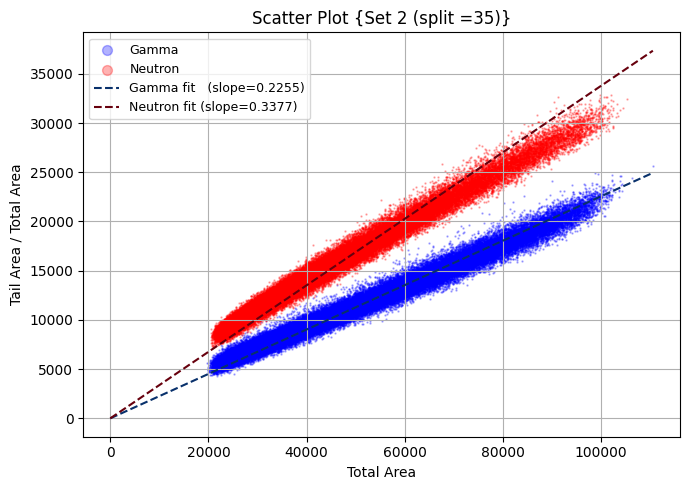

In [112]:
# ── Scatter plot: Tail area vs Total area — Set 2 (matching Fig 6) ────────────

short_start = 25
long_end    = 185
split       = 35      # tail starts here
window      = 5

# Smooth Set 2
df_g_smooth = moving_average(df_clean_gamma_AmBe.iloc[:,   :], window=window)
df_n_smooth = moving_average(df_clean_neutron_AmBe.iloc[:, :], window=window)

# Total area = sum over entire gate window (short_start to long_end)
total_area_g = df_g_smooth.iloc[:, short_start:long_end].sum(axis=1)
total_area_n = df_n_smooth.iloc[:, short_start:long_end].sum(axis=1)

# Tail area = sum from split to long_end
tail_area_g  = df_g_smooth.iloc[:, split:long_end].sum(axis=1)
tail_area_n  = df_n_smooth.iloc[:, split:long_end].sum(axis=1)


slope_g = np.sum(total_area_g * tail_area_g) / np.sum(total_area_g ** 2)
slope_n = np.sum(total_area_n * tail_area_n) / np.sum(total_area_n ** 2)

x_line = np.linspace(0, int(max(tail_area_g.max(),total_area_g.max(),tail_area_n.max(),total_area_n.max())),300)
line_g  = slope_g * x_line
line_n  = slope_n * x_line
plt.figure(figsize=(7, 5))
plt.scatter(total_area_g, tail_area_g, s=0.5, alpha=0.3,
            color='blue', label='Gamma')
plt.scatter(total_area_n, tail_area_n, s=0.5, alpha=0.3,
            color='red',  label='Neutron')
plt.plot(x_line, line_g, color='#08306B', linewidth=1.5, linestyle='--',
         label=f'Gamma fit   (slope={slope_g:.4f})')
plt.plot(x_line, line_n, color='#67000D',  linewidth=1.5, linestyle='--',
         label=f'Neutron fit (slope={slope_n:.4f})')
plt.xlabel("Total Area")
plt.ylabel("Tail Area / Total Area")
plt.title("Scatter Plot {Set 2 (split =35)}")
plt.legend(markerscale=10, fontsize=9)
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

Deep neural Network only on CCM and CCM weighted (fixed split) - (2(i) alternate)

Extracting features — Set 1 Gamma...
Extracting features — Set 1 Neutron...
Set 1 features — X: (59974, 2) | NaNs dropped: 0

Extracting features — Set 2 Gamma...
Extracting features — Set 2 Neutron...
Set 2 features — X: (154188, 2) | NaNs dropped: 0
Epoch 020/200 | Loss: 0.1682 | Acc: 0.9231
Epoch 040/200 | Loss: 0.1657 | Acc: 0.9341
Epoch 060/200 | Loss: 0.1666 | Acc: 0.9350
Epoch 080/200 | Loss: 0.1660 | Acc: 0.9351
Epoch 100/200 | Loss: 0.1666 | Acc: 0.9357
Epoch 120/200 | Loss: 0.1657 | Acc: 0.9355
Epoch 140/200 | Loss: 0.1657 | Acc: 0.9345
Epoch 160/200 | Loss: 0.1661 | Acc: 0.9356
Epoch 180/200 | Loss: 0.1660 | Acc: 0.9354
Epoch 200/200 | Loss: 0.1650 | Acc: 0.9358

Set 1 Test Accuracy: 0.9358
Set 2 Inference — Acc: 0.6201 | AUC: 0.9995


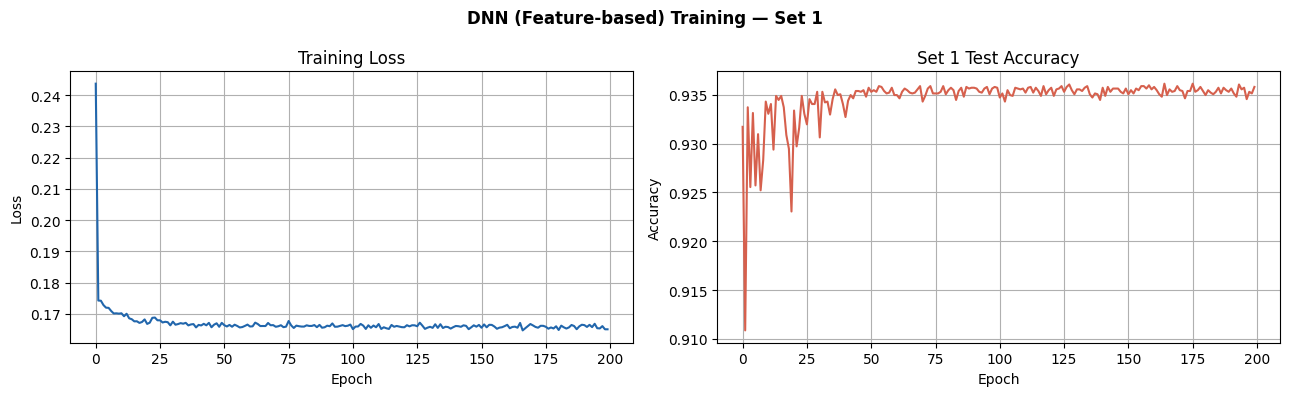

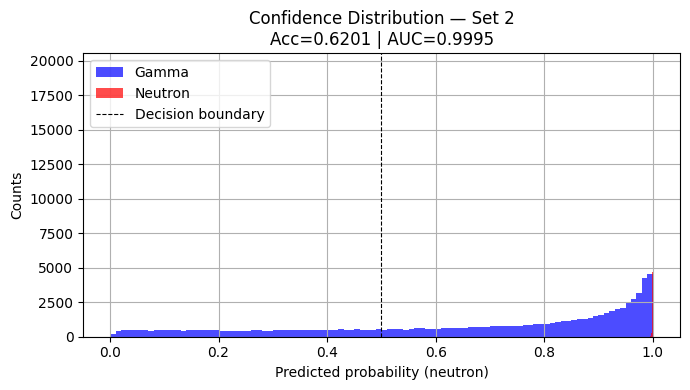

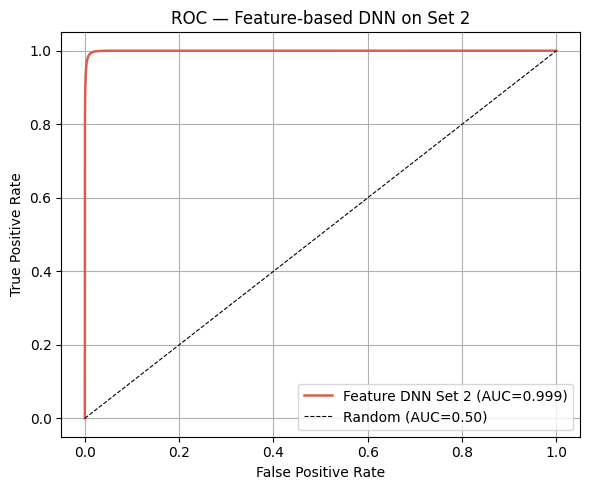

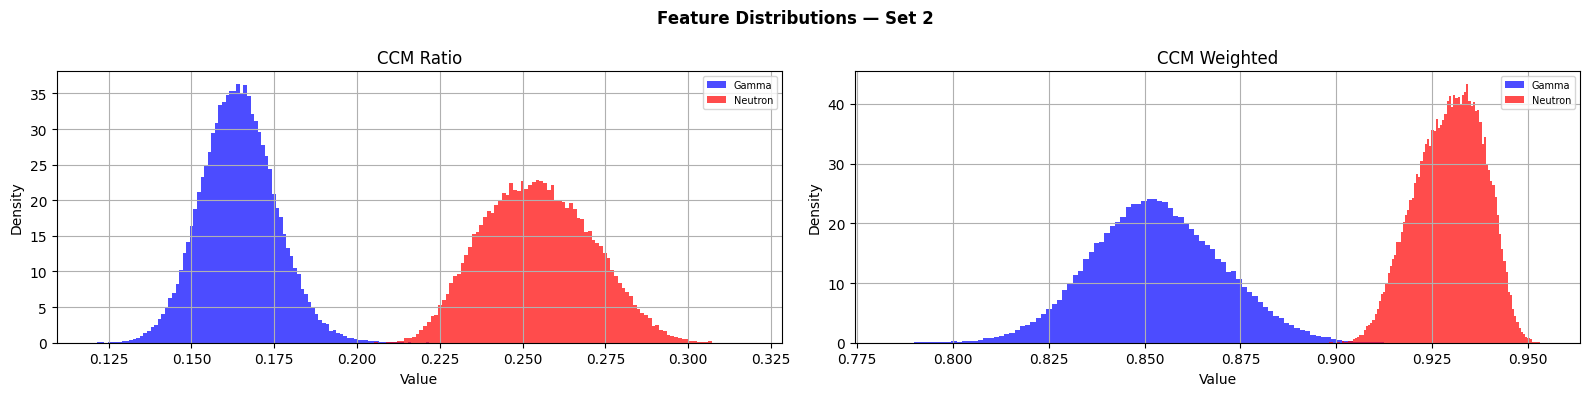

In [ ]:
# ── Feature extraction for Set 1 and Set 2 ───────────────────────────────────

short_start = 25
long_end    = 185
split       = 55
window      = 5

def compute_ccm_ratio(df, split_local, window=5):
    df_s  = moving_average(df, window)
    short = df_s.iloc[:, :split_local].sum(axis=1)
    long_ = df_s.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs().values

def compute_ccm_weighted(df, split_local, window=5):
    df_s      = moving_average(df, window)
    short     = df_s.iloc[:, :split_local].sum(axis=1)
    long_gate = df_s.iloc[:, split_local:]
    weights   = np.arange(1, long_gate.shape[1] + 1)
    long_w    = long_gate.multiply(weights, axis=1).sum(axis=1)
    return (long_w / (long_w + short)).abs().values

def extract_features(df, short_start, long_end, split, window=5):
    split_local = split - short_start
    df_gate     = df.iloc[:, short_start:long_end].copy()

    ccm         = compute_ccm_ratio(df_gate,    split_local, window)
    ccm_w       = compute_ccm_weighted(df_gate, split_local, window)

    features = np.column_stack([ccm, ccm_w])# slope, curvature])
    return features

# ── Extract features for Set 1 ───────────────────────────────────────────────

print("Extracting features — Set 1 Gamma...")
f1_g = extract_features(df_clean_gamma,   short_start, long_end, split)
print("Extracting features — Set 1 Neutron...")
f1_n = extract_features(df_clean_neutron, short_start, long_end, split)

X1_feat = np.concatenate([f1_g, f1_n], axis=0).astype(np.float32)
y1_feat = np.concatenate([np.zeros(len(f1_g)), np.ones(len(f1_n))]).astype(np.float32)

# Drop NaNs
mask1   = np.isfinite(X1_feat).all(axis=1)
X1_feat, y1_feat = X1_feat[mask1], y1_feat[mask1]
print(f"Set 1 features — X: {X1_feat.shape} | NaNs dropped: {(~mask1).sum()}")

# ── Extract features for Set 2 ───────────────────────────────────────────────

print("\nExtracting features — Set 2 Gamma...")
f2_g = extract_features(df_clean_gamma_AmBe,   short_start-10, long_end-10, split-20)
print("Extracting features — Set 2 Neutron...")
f2_n = extract_features(df_clean_neutron_AmBe, short_start-10, long_end-10, split-20)

X2_feat = np.concatenate([f2_g, f2_n], axis=0).astype(np.float32)
y2_feat = np.concatenate([np.zeros(len(f2_g)), np.ones(len(f2_n))]).astype(np.float32)

mask2   = np.isfinite(X2_feat).all(axis=1)
X2_feat, y2_feat = X2_feat[mask2], y2_feat[mask2]
print(f"Set 2 features — X: {X2_feat.shape} | NaNs dropped: {(~mask2).sum()}")

# ── Train/test split on Set 1 ────────────────────────────────────────────────

X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1_feat, y1_feat, test_size=0.2, stratify=y1_feat, random_state=42
)

train_dl_f = DataLoader(TensorDataset(torch.tensor(X1_tr), torch.tensor(y1_tr)),
                         batch_size=256, shuffle=True)
test_dl_f  = DataLoader(TensorDataset(torch.tensor(X1_te), torch.tensor(y1_te)),
                         batch_size=256, shuffle=False)

# ── DNN on features ───────────────────────────────────────────────────────────

class FeatureClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            nn.Linear(2, 128),       nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

model_f   = FeatureClassifier().to(device)
optimizer = torch.optim.Adam(model_f.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.BCELoss()

# ── Train ─────────────────────────────────────────────────────────────────────

epochs     = 200
train_losses, val_accs = [], []

for epoch in range(epochs):
    model_f.train()
    epoch_loss = 0
    for xb, yb in train_dl_f:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_f(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model_f.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl_f:
            p = model_f(xb.to(device)).cpu().numpy()
            preds.extend((p > 0.5).astype(float))
            labels.extend(yb.numpy())

    acc      = accuracy_score(labels, preds)
    loss_avg = epoch_loss / len(train_dl_f)
    scheduler.step(loss_avg)
    train_losses.append(loss_avg)
    val_accs.append(acc)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Loss: {loss_avg:.4f} | Acc: {acc:.4f}")

print(f"\nSet 1 Test Accuracy: {val_accs[-1]:.4f}")

# ── Inference on Set 2 ────────────────────────────────────────────────────────

test2_dl_f = DataLoader(TensorDataset(torch.tensor(X2_feat), torch.tensor(y2_feat)),
                         batch_size=256, shuffle=False)

model_f.eval()
preds2, probs2, labels2 = [], [], []
with torch.no_grad():
    for xb, yb in test2_dl_f:
        p = model_f(xb.to(device)).cpu().numpy()
        probs2.extend(p)
        preds2.extend((p > 0.5).astype(float))
        labels2.extend(yb.numpy())

probs2  = np.array(probs2)
labels2 = np.array(labels2)
acc2    = accuracy_score(labels2, preds2)
auc2    = roc_auc_score(labels2, probs2)
fpr2, tpr2, _ = roc_curve(labels2, probs2)

print(f"Set 2 Inference — Acc: {acc2:.4f} | AUC: {auc2:.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, color='#2166AC', linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

axes[1].plot(val_accs, color='#D6604D', linewidth=1.5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Set 1 Test Accuracy")
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("DNN (Feature-based) Training — Set 1", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Confidence distribution Set 2
plt.figure(figsize=(7, 4))
plt.hist(probs2[labels2 == 0], bins=100, alpha=0.7, color='blue',  label='Gamma')
plt.hist(probs2[labels2 == 1], bins=100, alpha=0.7, color='red',   label='Neutron')
plt.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='Decision boundary')
plt.xlabel("Predicted probability (neutron)")
plt.ylabel("Counts")
plt.title(f"Confidence Distribution — Set 2\nAcc={acc2:.4f} | AUC={auc2:.4f}")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr2, tpr2, color='#D6604D', linewidth=1.8,
         label=f"Feature DNN Set 2 (AUC={auc2:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Feature-based DNN on Set 2")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# Feature importance proxy — check separation per feature
feature_names = ['CCM Ratio', 'CCM Weighted']
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for i, name in enumerate(feature_names):
    axes[i].hist(X2_feat[y2_feat == 0, i], bins=100, alpha=0.7,
                 color='blue', label='Gamma',   density=True)
    axes[i].hist(X2_feat[y2_feat == 1, i], bins=100, alpha=0.7,
                 color='red',  label='Neutron', density=True)
    axes[i].set_title(name)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=7)
    axes[i].grid(True)
    for spine in axes[i].spines.values():
        spine.set_visible(True)

plt.suptitle("Feature Distributions — Set 2", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

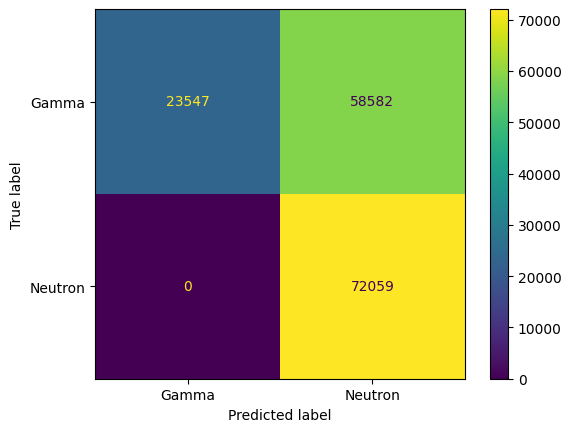

In [203]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix(labels2, preds2), display_labels=['Gamma', 'Neutron']).plot()

Deep neural network based only on CCM and CCM weighted (split decided by peak index)-(2(i))

Extracting features — Set 1 Gamma...
Extracting features — Set 1 Neutron...
Set 1 features — X: (59974, 2) | NaNs dropped: 0

Extracting features — Set 2 Gamma...
Extracting features — Set 2 Neutron...
Set 2 features — X: (154188, 2) | NaNs dropped: 0
Epoch 020/200 | Loss: 0.3682 | Acc: 0.8124
Epoch 040/200 | Loss: 0.3682 | Acc: 0.8336
Epoch 060/200 | Loss: 0.3669 | Acc: 0.8242
Epoch 080/200 | Loss: 0.3657 | Acc: 0.8292
Epoch 100/200 | Loss: 0.3657 | Acc: 0.8368
Epoch 120/200 | Loss: 0.3660 | Acc: 0.8357
Epoch 140/200 | Loss: 0.3654 | Acc: 0.8362
Epoch 160/200 | Loss: 0.3650 | Acc: 0.8346
Epoch 180/200 | Loss: 0.3654 | Acc: 0.8360
Epoch 200/200 | Loss: 0.3656 | Acc: 0.8361

Set 1 Test Accuracy: 0.8361
Set 2 Inference — Acc: 0.7446 | AUC: 0.9880


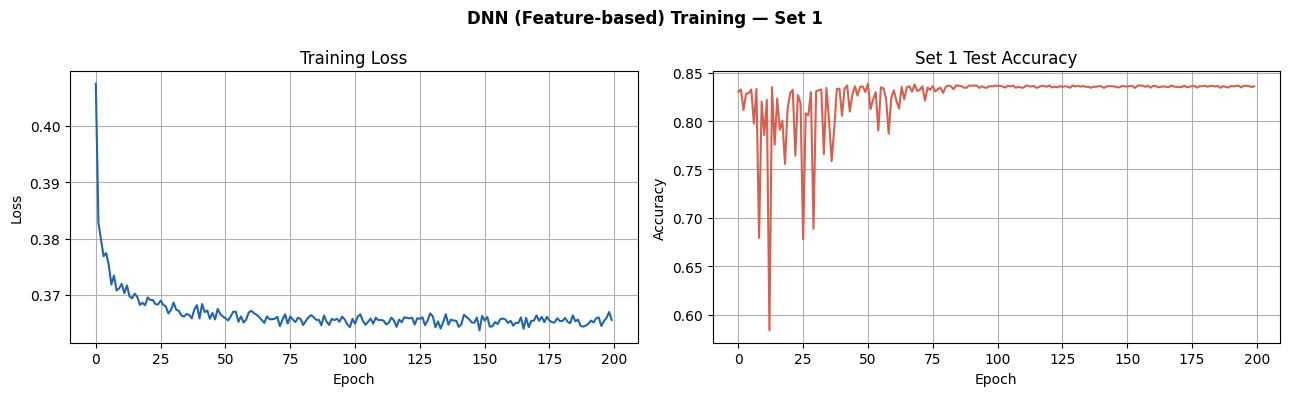

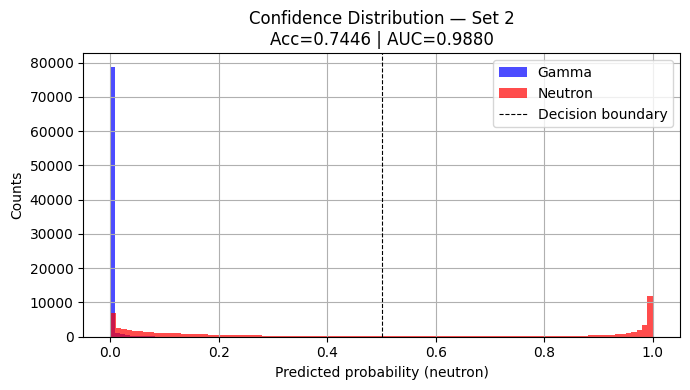

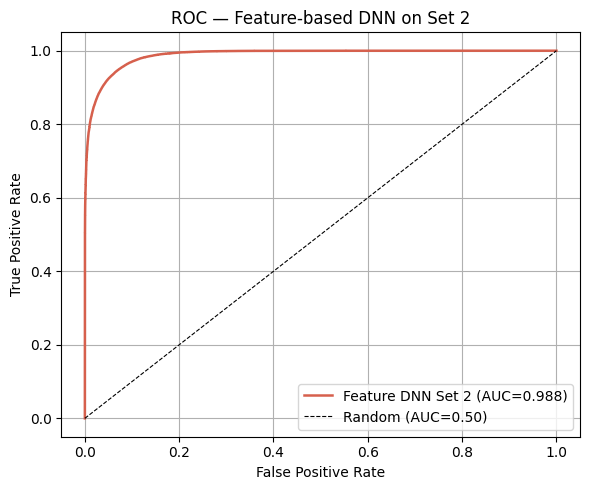

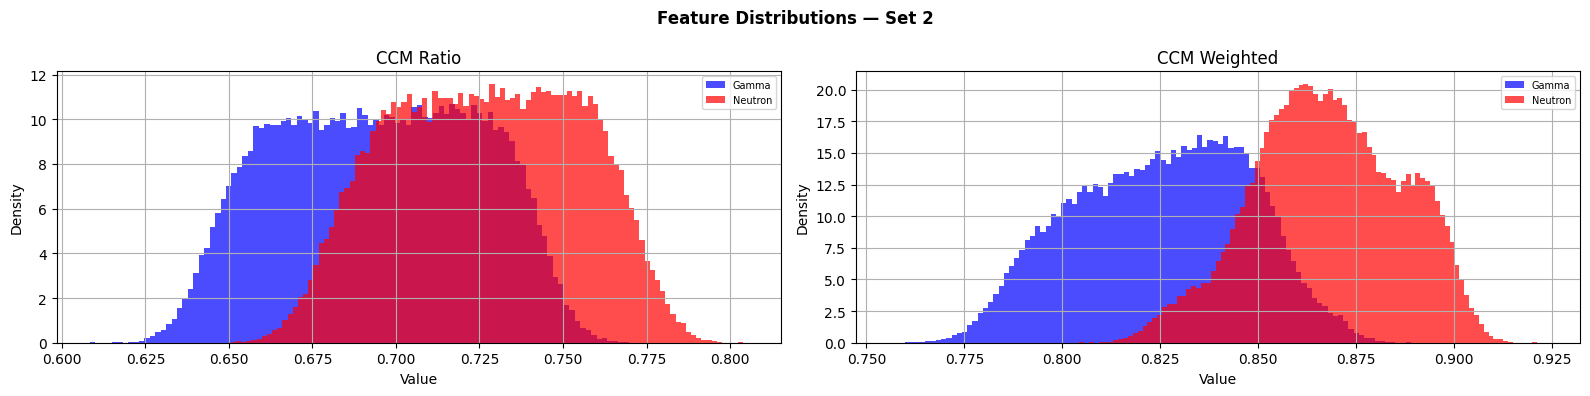

In [34]:
# ── Feature extraction for Set 1 and Set 2 ───────────────────────────────────

short_start = 25
long_end    = 105
window      = 5

def compute_ccm_ratio(df, window=5):
    df_s   = moving_average(df, window)
    ratios = []
    for idx in range(len(df_s)):
        waveform  = df_s.iloc[idx, :].values.astype(float)
        peak_idx  = np.argmax(waveform)
        short     = waveform[:peak_idx].sum()
        long_     = waveform[peak_idx:].sum()
        ratios.append(np.abs(long_ / (long_ + short + 1e-10)))
    return np.array(ratios)

def compute_ccm_weighted(df, window=5):
    df_s   = moving_average(df, window)
    ratios = []
    for idx in range(len(df_s)):
        waveform  = df_s.iloc[idx, :].values.astype(float)
        peak_idx  = np.argmax(waveform)
        short_gate     = waveform[:peak_idx]
        long_gate = waveform[peak_idx:]
        weights_l   = np.arange(peak_idx+1, len(waveform) + 1)
        weights_s =np.arange(1,peak_idx+1)
        short_w =(short_gate*weights_s).sum()
        long_w    = (long_gate * weights_l).sum()
        ratios.append(np.abs(long_w / (long_w + short_w + 1e-10)))
    return np.array(ratios)

def extract_features(df, short_start, long_end, split, window=5):
    # split and short_start/long_end params kept for signature compatibility
    # but split is now determined per-pulse via argmax
    df_gate = df.iloc[:, short_start:long_end].copy()
    ccm     = compute_ccm_ratio(df_gate,    window)
    ccm_w   = compute_ccm_weighted(df_gate, window)
    return np.column_stack([ccm, ccm_w])

# ── Extract features for Set 1 ───────────────────────────────────────────────

print("Extracting features — Set 1 Gamma...")
f1_g = extract_features(df_clean_gamma,   short_start, long_end, split)
print("Extracting features — Set 1 Neutron...")
f1_n = extract_features(df_clean_neutron, short_start, long_end, split)

X1_feat = np.concatenate([f1_g, f1_n], axis=0).astype(np.float32)
y1_feat = np.concatenate([np.zeros(len(f1_g)), np.ones(len(f1_n))]).astype(np.float32)

# Drop NaNs
mask1   = np.isfinite(X1_feat).all(axis=1)
X1_feat, y1_feat = X1_feat[mask1], y1_feat[mask1]
print(f"Set 1 features — X: {X1_feat.shape} | NaNs dropped: {(~mask1).sum()}")

# ── Extract features for Set 2 ───────────────────────────────────────────────

print("\nExtracting features — Set 2 Gamma...")
f2_g = extract_features(df_clean_gamma_AmBe,   short_start-10, long_end-10, split-20)
print("Extracting features — Set 2 Neutron...")
f2_n = extract_features(df_clean_neutron_AmBe, short_start-10, long_end-10, split-20)

X2_feat = np.concatenate([f2_g, f2_n], axis=0).astype(np.float32)
y2_feat = np.concatenate([np.zeros(len(f2_g)), np.ones(len(f2_n))]).astype(np.float32)

mask2   = np.isfinite(X2_feat).all(axis=1)
X2_feat, y2_feat = X2_feat[mask2], y2_feat[mask2]
print(f"Set 2 features — X: {X2_feat.shape} | NaNs dropped: {(~mask2).sum()}")

# ── Train/test split on Set 1 ────────────────────────────────────────────────

X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1_feat, y1_feat, test_size=0.2, stratify=y1_feat, random_state=42
)

train_dl_f = DataLoader(TensorDataset(torch.tensor(X1_tr), torch.tensor(y1_tr)),
                         batch_size=256, shuffle=True)
test_dl_f  = DataLoader(TensorDataset(torch.tensor(X1_te), torch.tensor(y1_te)),
                         batch_size=256, shuffle=False)

# ── DNN on features ───────────────────────────────────────────────────────────

class FeatureClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            nn.Linear(2, 128),       nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.4),
            nn.Linear(128,64),      nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3), 
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

model_f   = FeatureClassifier().to(device)
optimizer = torch.optim.Adam(model_f.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.BCELoss()

# ── Train ─────────────────────────────────────────────────────────────────────

epochs     = 200
train_losses, val_accs = [], []

for epoch in range(epochs):
    model_f.train()
    epoch_loss = 0
    for xb, yb in train_dl_f:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_f(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model_f.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl_f:
            p = model_f(xb.to(device)).cpu().numpy()
            preds.extend((p > 0.5).astype(float))
            labels.extend(yb.numpy())

    acc      = accuracy_score(labels, preds)
    loss_avg = epoch_loss / len(train_dl_f)
    scheduler.step(loss_avg)
    train_losses.append(loss_avg)
    val_accs.append(acc)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Loss: {loss_avg:.4f} | Acc: {acc:.4f}")

print(f"\nSet 1 Test Accuracy: {val_accs[-1]:.4f}")

# ── Inference on Set 2 ────────────────────────────────────────────────────────

test2_dl_f = DataLoader(TensorDataset(torch.tensor(X2_feat), torch.tensor(y2_feat)),
                         batch_size=256, shuffle=False)

model_f.eval()
preds2, probs2, labels2 = [], [], []
with torch.no_grad():
    for xb, yb in test2_dl_f:
        p = model_f(xb.to(device)).cpu().numpy()
        probs2.extend(p)
        preds2.extend((p > 0.5).astype(float))
        labels2.extend(yb.numpy())

probs2  = np.array(probs2)
labels2 = np.array(labels2)
acc2    = accuracy_score(labels2, preds2)
auc2    = roc_auc_score(labels2, probs2)
fpr2, tpr2, _ = roc_curve(labels2, probs2)

print(f"Set 2 Inference — Acc: {acc2:.4f} | AUC: {auc2:.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, color='#2166AC', linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

axes[1].plot(val_accs, color='#D6604D', linewidth=1.5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Set 1 Test Accuracy")
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("DNN (Feature-based) Training — Set 1", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Confidence distribution Set 2
plt.figure(figsize=(7, 4))
plt.hist(probs2[labels2 == 0], bins=100, alpha=0.7, color='blue',  label='Gamma')
plt.hist(probs2[labels2 == 1], bins=100, alpha=0.7, color='red',   label='Neutron')
plt.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='Decision boundary')
plt.xlabel("Predicted probability (neutron)")
plt.ylabel("Counts")
plt.title(f"Confidence Distribution — Set 2\nAcc={acc2:.4f} | AUC={auc2:.4f}")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr2, tpr2, color='#D6604D', linewidth=1.8,
         label=f"Feature DNN Set 2 (AUC={auc2:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Feature-based DNN on Set 2")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# Feature importance proxy — check separation per feature
feature_names = ['CCM Ratio', 'CCM Weighted']
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for i, name in enumerate(feature_names):
    axes[i].hist(X2_feat[y2_feat == 0, i], bins=100, alpha=0.7,
                 color='blue', label='Gamma',   density=True)
    axes[i].hist(X2_feat[y2_feat == 1, i], bins=100, alpha=0.7,
                 color='red',  label='Neutron', density=True)
    axes[i].set_title(name)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=7)
    axes[i].grid(True)
    for spine in axes[i].spines.values():
        spine.set_visible(True)

plt.suptitle("Feature Distributions — Set 2", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

K-means

Set 2 Gamma...
Set 2 Neutron...
K-Means — Acc: 0.9961


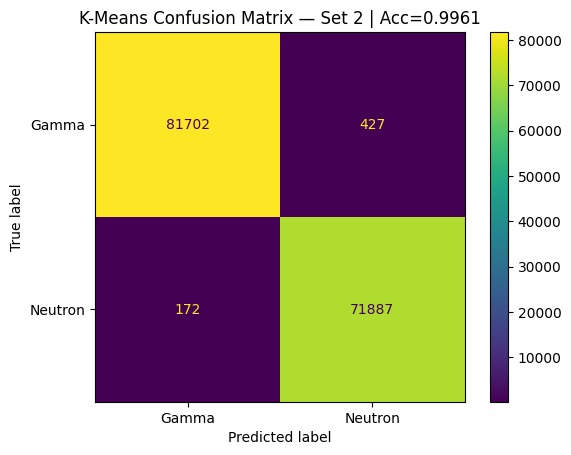

In [ ]:
print("Set 2 Gamma...")
s2g_ccm  = compute_ccm_ratio(df_clean_gamma)
s2g_ccmw = compute_ccm_weighted(df_clean_gamma)
print("Set 2 Neutron...")
s2n_ccm  = compute_ccm_ratio(df_clean_neutron)
s2n_ccmw = compute_ccm_weighted(df_clean_neutron)

# ── K-Means ───────────────────────────────────────────────────────────────────

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

X2_cluster = np.column_stack([
    np.concatenate([s2g_ccm,  s2n_ccm]),
    np.concatenate([s2g_ccmw, s2n_ccmw])
])
y2_true = np.concatenate([np.zeros(len(s2g_ccm)), np.ones(len(s2n_ccm))])

mask  = np.isfinite(X2_cluster).all(axis=1)
X2_c  = X2_cluster[mask]
y2_c  = y2_true[mask]

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X2_c)

acc_direct     = accuracy_score(y2_c, labels)
acc_flip       = accuracy_score(y2_c, 1 - labels)
labels_aligned = labels if acc_direct > acc_flip else 1 - labels
acc_kmeans     = max(acc_direct, acc_flip)

print(f"K-Means — Acc: {acc_kmeans:.4f}")
ConfusionMatrixDisplay(confusion_matrix(y2_c, labels_aligned),
                       display_labels=['Gamma', 'Neutron']).plot()
plt.title(f"K-Means Confusion Matrix — Set 2 | Acc={acc_kmeans:.4f}")
plt.show()

Simple Logistic regression on CCM

In [ ]:
def get_accuracy(gamma_ratio, neutron_ratio):
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([np.zeros(len(gamma_ratio)), np.ones(len(neutron_ratio))])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    return accuracy_score(y_test, clf.predict(X_test))


lr_acc_s2 = get_accuracy(s2g_ccm, s2n_ccm)
print("Source 2 (AmBe) — logistic regression on CCM ratios")
print(f"  Pulses: gamma={len(s2g_ccm)}, neutron={len(s2n_ccm)}")
print(f"  Test accuracy (20% holdout, stratified): {lr_acc_s2:.6f}")


Source 2 (AmBe) — logistic regression on CCM ratios
  Pulses: gamma=82129, neutron=72059
  Test accuracy (20% holdout, stratified): 0.995590


GMM (Set 2 direct) — Acc: 0.9880 | AUC: 1.0000
[[80284  1845]
 [    0 72059]]
Computing Set 1 features...
GMM Transfer (Set1→Set2) — Acc: 0.8399 | AUC: 0.9613


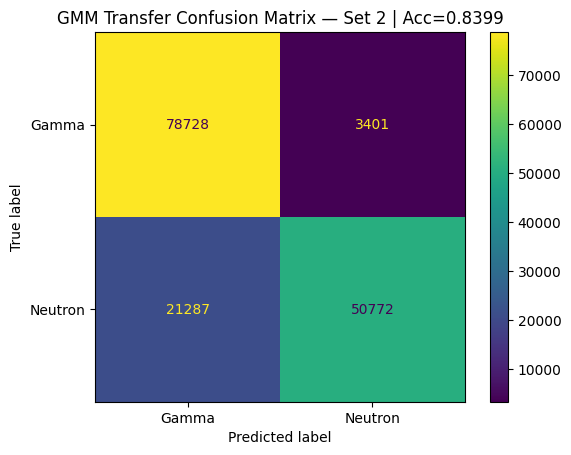


── Accuracy Comparison on Set 2 ─────────────────────────────────────────
  K-Means  (Set 2 unsupervised): 0.9961
  GMM      (Set 2 unsupervised): 0.9880
  GMM Transfer  (Set1 → Set2):  0.8399


In [221]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# ── GMM on Set 2 directly (unsupervised) ─────────────────────────────────────

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=5)
gmm.fit(X2_c)
labels_gmm = gmm.predict(X2_c)
probs_gmm  = gmm.predict_proba(X2_c)

acc_g = accuracy_score(y2_c, labels_gmm)
acc_f = accuracy_score(y2_c, 1 - labels_gmm)
labels_gmm_aligned = labels_gmm if acc_g > acc_f else 1 - labels_gmm
probs_gmm_aligned  = probs_gmm  if acc_g > acc_f else probs_gmm[:, ::-1]
acc_gmm = max(acc_g, acc_f)
auc_gmm = roc_auc_score(y2_c, probs_gmm_aligned[:, 1])
confusion_matrix(y2_c, labels_gmm_aligned)
print(f"GMM (Set 2 direct) — Acc: {acc_gmm:.4f} | AUC: {auc_gmm:.4f}")
print(confusion_matrix(y2_c, labels_gmm_aligned))


# ── GMM Transfer: train on Set 1, apply to Set 2 ─────────────────────────────

# Need Set 1 features — recompute using same functions
print("Computing Set 1 features...")
s1g_ccm  = compute_ccm_ratio(df_clean_gamma)
s1g_ccmw = compute_ccm_weighted(df_clean_gamma)
s1n_ccm  = compute_ccm_ratio(df_clean_neutron)
s1n_ccmw = compute_ccm_weighted(df_clean_neutron)

X1_c = np.column_stack([
    np.concatenate([s1g_ccm,  s1n_ccm]),
    np.concatenate([s1g_ccmw, s1n_ccmw])
])
y1_c = np.concatenate([np.zeros(len(s1g_ccm)), np.ones(len(s1n_ccm))])
mask1 = np.isfinite(X1_c).all(axis=1)
X1_c, y1_c = X1_c[mask1], y1_c[mask1]

# Fit one GMM per class on Set 1
gmm_gamma   = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_neutron = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_gamma.fit(  X1_c[y1_c == 0])
gmm_neutron.fit(X1_c[y1_c == 1])

# Score Set 2 under each class model
log_p_gamma   = gmm_gamma.score_samples(X2_c)
log_p_neutron = gmm_neutron.score_samples(X2_c)

labels_transfer  = (log_p_neutron > log_p_gamma).astype(int)
acc_transfer     = accuracy_score(y2_c, labels_transfer)
probs_transfer   = np.exp(log_p_neutron - np.logaddexp(log_p_gamma, log_p_neutron))
auc_transfer     = roc_auc_score(y2_c, probs_transfer)

print(f"GMM Transfer (Set1→Set2) — Acc: {acc_transfer:.4f} | AUC: {auc_transfer:.4f}")
ConfusionMatrixDisplay(confusion_matrix(y2_c, labels_transfer),
                       display_labels=['Gamma', 'Neutron']).plot()
plt.title(f"GMM Transfer Confusion Matrix — Set 2 | Acc={acc_transfer:.4f}")
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────

print("\n── Accuracy Comparison on Set 2 ─────────────────────────────────────────")
print(f"  K-Means  (Set 2 unsupervised): {acc_kmeans:.4f}")
print(f"  GMM      (Set 2 unsupervised): {acc_gmm:.4f}")
print(f"  GMM Transfer  (Set1 → Set2):  {acc_transfer:.4f}")

(1) Figures

Using device: cpu
Peak-aligning Set 1...
Peak-aligning Set 2...

Set 1 — Trainval: 41981 | Test: 17993
Set 2 — Full inference: 154188
Epoch 001/100 | Train Loss: 0.1825 | Val Loss: 0.0511 | Val Acc: 0.9929
Epoch 002/100 | Train Loss: 0.0432 | Val Loss: 0.0277 | Val Acc: 0.9950
Epoch 003/100 | Train Loss: 0.0319 | Val Loss: 0.0304 | Val Acc: 0.9948
Epoch 004/100 | Train Loss: 0.0286 | Val Loss: 0.0296 | Val Acc: 0.9921
Epoch 005/100 | Train Loss: 0.0286 | Val Loss: 0.0276 | Val Acc: 0.9948
Epoch 006/100 | Train Loss: 0.0278 | Val Loss: 0.0267 | Val Acc: 0.9952
Epoch 007/100 | Train Loss: 0.0273 | Val Loss: 0.0264 | Val Acc: 0.9919
Epoch 008/100 | Train Loss: 0.0274 | Val Loss: 0.0248 | Val Acc: 0.9950
Epoch 009/100 | Train Loss: 0.0261 | Val Loss: 0.0336 | Val Acc: 0.9895
Epoch 010/100 | Train Loss: 0.0267 | Val Loss: 0.0695 | Val Acc: 0.9738
Epoch 011/100 | Train Loss: 0.0260 | Val Loss: 0.0239 | Val Acc: 0.9945
Epoch 012/100 | Train Loss: 0.0261 | Val Loss: 0.0261 | Val Acc: 0.9952
Ep

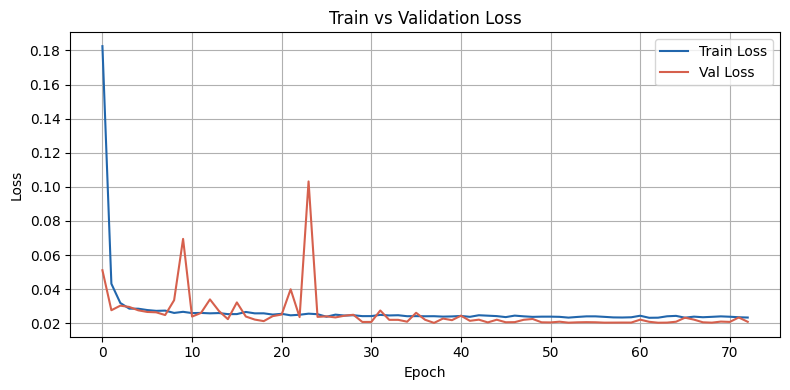

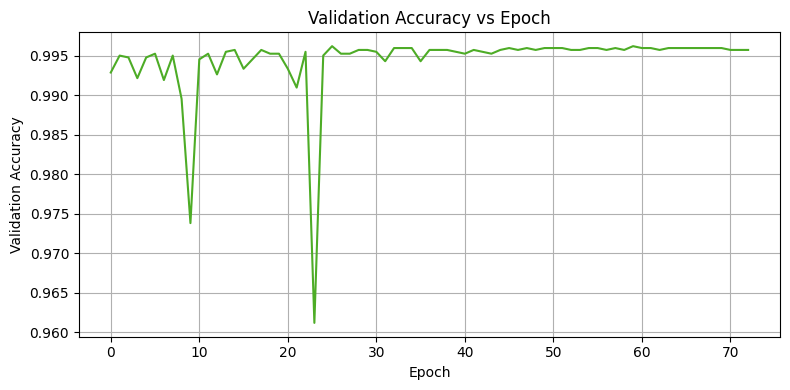


── Set 1 Test (held-out) ──────────────────────────────────────────────────────────
  Accuracy:  0.9954
  AUC:       0.9977
  Precision: 0.9931
  Recall:    0.9964
  F1 Score:  0.9948

── Set 2 Inference ──────────────────────────────────────────────────────────
  Accuracy:  0.9978
  AUC:       1.0000
  Precision: 0.9999
  Recall:    0.9955
  F1 Score:  0.9977


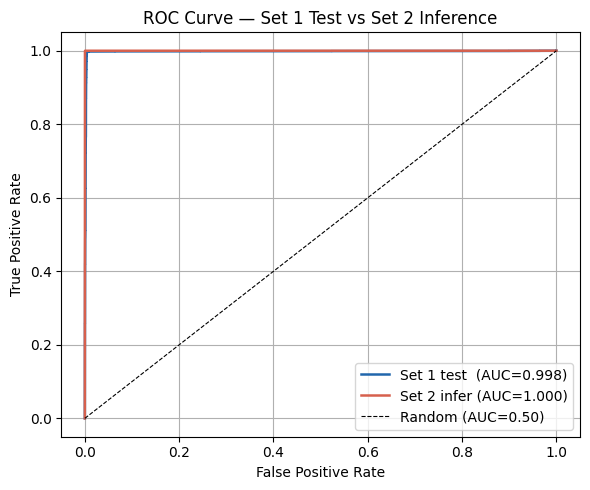

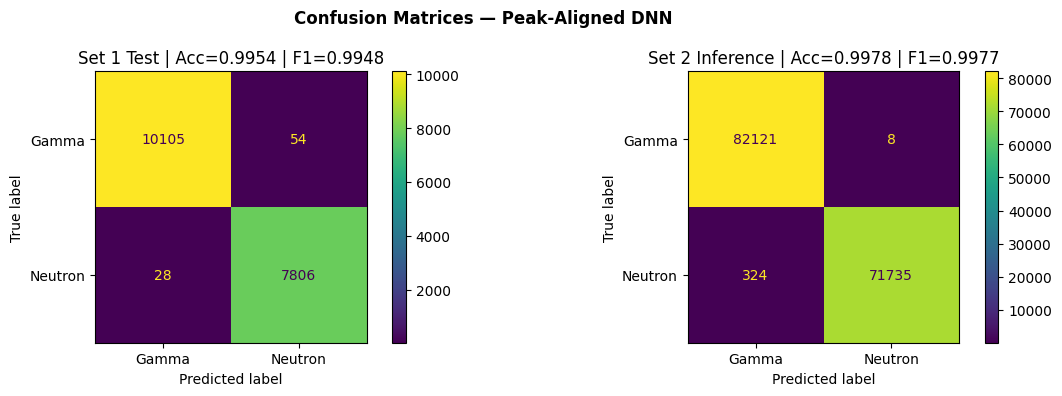

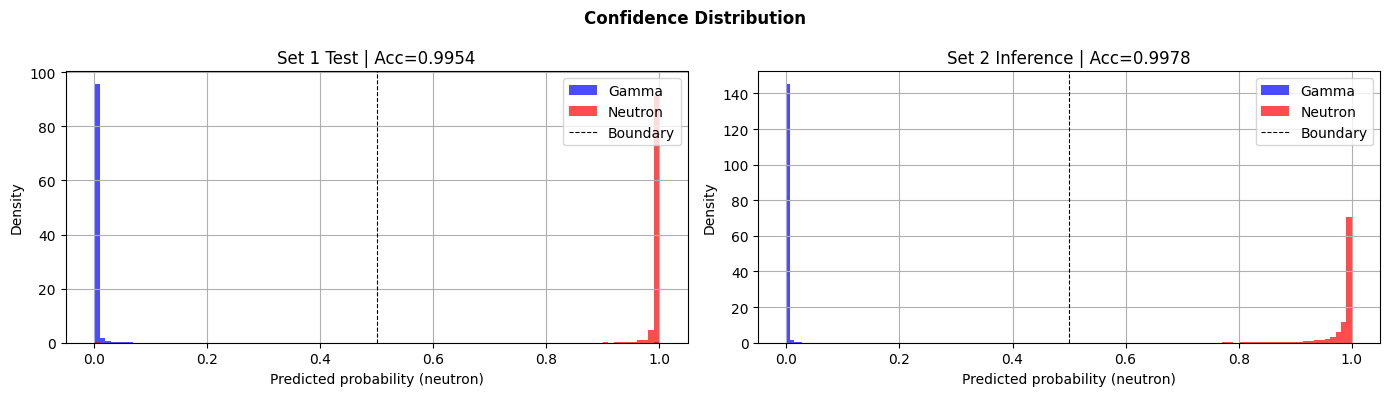


── Final Summary ────────────────────────────────────────────────────────
Metric         Set 1 Test  Set 2 Infer
──────────────────────────────────────
Accuracy           0.9954       0.9978
AUC                0.9977       1.0000
Precision          0.9931       0.9999
Recall             0.9964       0.9955
F1 Score           0.9948       0.9977


In [257]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# ── Parameters ────────────────────────────────────────────────────────────────
PATIENCE = 35
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None
TARGET_PEAK  = 35
PULSE_LENGTH = 150
WINDOW       = 5
EPOCHS       = 100
BATCH_SIZE   = 256
LR           = 3e-4
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Peak alignment ────────────────────────────────────────────────────────────

def peak_align(df, target_peak=TARGET_PEAK, window=WINDOW, pulse_length=PULSE_LENGTH):
    df_s    = moving_average(df, window)
    aligned = np.zeros((len(df_s), pulse_length), dtype=np.float32)
    for idx in range(len(df_s)):
        waveform = df_s.iloc[idx, :].values.astype(float)
        peak_idx = np.argmax(waveform)
        shift    = target_peak - peak_idx
        if shift >= 0:
            end = min(len(waveform), pulse_length - shift)
            aligned[idx, shift:shift + end] = waveform[:end]
        else:
            start = -shift
            end   = min(len(waveform) - start, pulse_length)
            aligned[idx, :end] = waveform[start:start + end]
    aligned = aligned / (aligned.max(axis=1, keepdims=True) + 1e-10)
    return aligned

print("Peak-aligning Set 1...")
pa_s1g = peak_align(df_clean_gamma)
pa_s1n = peak_align(df_clean_neutron)
print("Peak-aligning Set 2...")
pa_s2g = peak_align(df_clean_gamma_AmBe)
pa_s2n = peak_align(df_clean_neutron_AmBe)

# ── Build datasets ────────────────────────────────────────────────────────────

def make_dataset(X_g, X_n):
    X    = np.concatenate([X_g, X_n], axis=0).astype(np.float32)
    y    = np.concatenate([np.zeros(len(X_g)), np.ones(len(X_n))]).astype(np.float32)
    mask = np.isfinite(X).all(axis=1)
    return X[mask], y[mask]

X1, y1 = make_dataset(pa_s1g, pa_s1n)
X2, y2 = make_dataset(pa_s2g, pa_s2n)

# 70% trainval, 30% test
X1_trainval, X1_test, y1_trainval, y1_test = train_test_split(
    X1, y1, test_size=0.30, stratify=y1, random_state=42
)

# 10% of trainval as validation per epoch
n_trainval  = len(X1_trainval)
n_val       = int(0.10 * n_trainval)
indices     = np.arange(n_trainval)
trainval_ds = TensorDataset(torch.tensor(X1_trainval), torch.tensor(y1_trainval))
test_dl     = DataLoader(TensorDataset(torch.tensor(X1_test), torch.tensor(y1_test)),
                         batch_size=BATCH_SIZE, shuffle=False)

print(f"\nSet 1 — Trainval: {n_trainval} | Test: {len(X1_test)}")
print(f"Set 2 — Full inference: {len(X2)}")

# ── DNN ───────────────────────────────────────────────────────────────────────

class PulseClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(

            nn.Linear(input_dim, 128),             nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.4),
            nn.Linear(128,64),               nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3), 
            nn.Linear(64, 1),                nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

model     = PulseClassifier(input_dim=X1_trainval.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.BCELoss()

# ── Training ──────────────────────────────────────────────────────────────────

train_losses, val_losses, val_accs = [], [], []
# Fresh random 90/10 split every epoch
np.random.shuffle(indices)
train_idx = indices[n_val:]
val_idx   = indices[:n_val]

train_dl = DataLoader(trainval_ds, batch_size=BATCH_SIZE,
                        sampler=SubsetRandomSampler(train_idx))
val_dl   = DataLoader(trainval_ds, batch_size=BATCH_SIZE,
                        sampler=SubsetRandomSampler(val_idx))
for epoch in range(EPOCHS):

    # Train
    model.train()
    epoch_train_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_dl)

    # Validate
    model.eval()
    epoch_val_loss = 0
    preds_v, labels_v = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            probs   = model(xb)
            epoch_val_loss += criterion(probs, yb).item()
            preds_v.extend((probs.cpu().numpy() > 0.5).astype(float))
            labels_v.extend(yb.cpu().numpy())
    epoch_val_loss /= len(val_dl)
    val_acc         = accuracy_score(labels_v, preds_v)

    scheduler.step(epoch_val_loss)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")
    if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            # Store the best weights
            best_model_state = model.state_dict().copy()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            # Load the best weights before exiting
            model.load_state_dict(best_model_state)
            break
# ── Plot 1: Train vs Val Loss ─────────────────────────────────────────────────

plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='#2166AC', linewidth=1.5, label='Train Loss')
plt.plot(val_losses,   color='#D6604D', linewidth=1.5, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 2: Validation Accuracy ───────────────────────────────────────────────

plt.figure(figsize=(8, 4))
plt.plot(val_accs, color='#4DAC26', linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Evaluation function ───────────────────────────────────────────────────────

def full_eval(model, X, y, label):
    dl = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y)),
                    batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    preds, probs, labels_e = [], [], []
    with torch.no_grad():
        for xb, yb in dl:
            p = model(xb.to(device)).cpu().numpy()
            probs.extend(p)
            preds.extend((p > 0.5).astype(float))
            labels_e.extend(yb.numpy())
    probs, preds, labels_e = np.array(probs), np.array(preds), np.array(labels_e)
    acc  = accuracy_score(labels_e,  preds)
    auc  = roc_auc_score(labels_e,   probs)
    prec = precision_score(labels_e, preds)
    rec  = recall_score(labels_e,    preds)
    f1   = f1_score(labels_e,        preds)
    fpr, tpr, _ = roc_curve(labels_e, probs)
    print(f"\n── {label} ──────────────────────────────────────────────────────────")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  AUC:       {auc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    return acc, auc, prec, rec, f1, fpr, tpr, preds, probs, labels_e

acc1, auc1, prec1, rec1, f1_1, fpr1, tpr1, preds1, probs1, labels1 = \
    full_eval(model, X1_test, y1_test, "Set 1 Test (held-out)")
acc2, auc2, prec2, rec2, f1_2, fpr2, tpr2, preds2, probs2, labels2 = \
    full_eval(model, X2,      y2,      "Set 2 Inference")

# ── Plot 3: ROC curves ────────────────────────────────────────────────────────

plt.figure(figsize=(6, 5))
plt.plot(fpr1, tpr1, color='#2166AC', linewidth=1.8, label=f"Set 1 test  (AUC={auc1:.3f})")
plt.plot(fpr2, tpr2, color='#D6604D', linewidth=1.8, label=f"Set 2 infer (AUC={auc2:.3f})")
plt.plot([0,1], [0,1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Set 1 Test vs Set 2 Inference")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 4: Confusion matrices ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(labels1, preds1),
                       display_labels=['Gamma', 'Neutron']).plot(ax=axes[0],values_format='d')
axes[0].set_title(f"Set 1 Test | Acc={acc1:.4f} | F1={f1_1:.4f}")
ConfusionMatrixDisplay(confusion_matrix(labels2, preds2),
                       display_labels=['Gamma', 'Neutron']).plot(ax=axes[1],values_format='d')
axes[1].set_title(f"Set 2 Inference | Acc={acc2:.4f} | F1={f1_2:.4f}")
plt.suptitle("Confusion Matrices — Peak-Aligned DNN", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 5: Confidence distributions ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, probs, labels_e, title in zip(
    axes,
    [probs1, probs2],
    [labels1, labels2],
    [f"Set 1 Test | Acc={acc1:.4f}", f"Set 2 Inference | Acc={acc2:.4f}"]
):
    ax.hist(probs[labels_e == 0], bins=100, alpha=0.7, color='blue',
            label='Gamma',   density=True)
    ax.hist(probs[labels_e == 1], bins=100, alpha=0.7, color='red',
            label='Neutron', density=True)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='Boundary')
    ax.set_xlabel("Predicted probability (neutron)")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
plt.suptitle("Confidence Distribution", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────

print("\n── Final Summary ────────────────────────────────────────────────────────")
print(f"{'Metric':<12} {'Set 1 Test':>12} {'Set 2 Infer':>12}")
print(f"{'─'*38}")
print(f"{'Accuracy':<12} {acc1:>12.4f} {acc2:>12.4f}")
print(f"{'AUC':<12} {auc1:>12.4f} {auc2:>12.4f}")
print(f"{'Precision':<12} {prec1:>12.4f} {prec2:>12.4f}")
print(f"{'Recall':<12} {rec1:>12.4f} {rec2:>12.4f}")
print(f"{'F1 Score':<12} {f1_1:>12.4f} {f1_2:>12.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# ── Parameters ────────────────────────────────────────────────────────────────

TARGET_PEAK  = 35
PULSE_LENGTH = 150
WINDOW       = 5
EPOCHS       = 200
BATCH_SIZE   = 256
LR           = 3e-4
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Peak alignment ────────────────────────────────────────────────────────────

def peak_align(df, target_peak=TARGET_PEAK, window=WINDOW, pulse_length=PULSE_LENGTH):
    df_s    = moving_average(df, window)
    aligned = np.zeros((len(df_s), pulse_length), dtype=np.float32)
    for idx in range(len(df_s)):
        waveform = df_s.iloc[idx, :].values.astype(float)
        peak_idx = np.argmax(waveform)
        shift    = target_peak - peak_idx
        if shift >= 0:
            end = min(len(waveform), pulse_length - shift)
            aligned[idx, shift:shift + end] = waveform[:end]
        else:
            start = -shift
            end   = min(len(waveform) - start, pulse_length)
            aligned[idx, :end] = waveform[start:start + end]
    aligned = aligned / (aligned.max(axis=1, keepdims=True) + 1e-10)
    return aligned

print("Peak-aligning Set 1...")
pa_s1g = peak_align(df_clean_gamma)
pa_s1n = peak_align(df_clean_neutron)
print("Peak-aligning Set 2...")
pa_s2g = peak_align(df_clean_gamma_AmBe)
pa_s2n = peak_align(df_clean_neutron_AmBe)

# ── Build datasets ────────────────────────────────────────────────────────────

def make_dataset(X_g, X_n):
    X    = np.concatenate([X_g, X_n], axis=0).astype(np.float32)
    y    = np.concatenate([np.zeros(len(X_g)), np.ones(len(X_n))]).astype(np.float32)
    mask = np.isfinite(X).all(axis=1)
    return X[mask], y[mask]

X1, y1 = make_dataset(pa_s2g, pa_s2n)
X2, y2 = make_dataset(pa_s1g, pa_s1n)

# 70% trainval, 30% test
X1_trainval, X1_test, y1_trainval, y1_test = train_test_split(
    X1, y1, test_size=0.30, stratify=y1, random_state=42
)

# 10% of trainval as validation per epoch
n_trainval  = len(X1_trainval)
n_val       = int(0.10 * n_trainval)
indices     = np.arange(n_trainval)
trainval_ds = TensorDataset(torch.tensor(X1_trainval), torch.tensor(y1_trainval))
test_dl     = DataLoader(TensorDataset(torch.tensor(X1_test), torch.tensor(y1_test)),
                         batch_size=BATCH_SIZE, shuffle=False)

print(f"\nSet 1 — Trainval: {n_trainval} | Test: {len(X1_test)}")
print(f"Set 2 — Full inference: {len(X2)}")

# ── DNN ───────────────────────────────────────────────────────────────────────

class PulseClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(

            nn.Linear(input_dim, 256),       nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.4),
            nn.Linear(256, 128),             nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.4),
            nn.Linear(128,64),               nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3), 
            nn.Linear(64, 1),                nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

model     = PulseClassifier(input_dim=X1_trainval.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.BCELoss()

# ── Training ──────────────────────────────────────────────────────────────────

train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    # Fresh random 90/10 split every epoch
    np.random.shuffle(indices)
    train_idx = indices[n_val:]
    val_idx   = indices[:n_val]

    train_dl = DataLoader(trainval_ds, batch_size=BATCH_SIZE,
                          sampler=SubsetRandomSampler(train_idx))
    val_dl   = DataLoader(trainval_ds, batch_size=BATCH_SIZE,
                          sampler=SubsetRandomSampler(val_idx))

    # Train
    model.train()
    epoch_train_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_dl)

    # Validate
    model.eval()
    epoch_val_loss = 0
    preds_v, labels_v = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            probs   = model(xb)
            epoch_val_loss += criterion(probs, yb).item()
            preds_v.extend((probs.cpu().numpy() > 0.5).astype(float))
            labels_v.extend(yb.cpu().numpy())
    epoch_val_loss /= len(val_dl)
    val_acc         = accuracy_score(labels_v, preds_v)

    scheduler.step(epoch_val_loss)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

# ── Plot 1: Train vs Val Loss ─────────────────────────────────────────────────

plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='#2166AC', linewidth=1.5, label='Train Loss')
plt.plot(val_losses,   color='#D6604D', linewidth=1.5, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 2: Validation Accuracy ───────────────────────────────────────────────

plt.figure(figsize=(8, 4))
plt.plot(val_accs, color='#4DAC26', linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Evaluation function ───────────────────────────────────────────────────────

def full_eval(model, X, y, label):
    dl = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y)),
                    batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    preds, probs, labels_e = [], [], []
    with torch.no_grad():
        for xb, yb in dl:
            p = model(xb.to(device)).cpu().numpy()
            probs.extend(p)
            preds.extend((p > 0.5).astype(float))
            labels_e.extend(yb.numpy())
    probs, preds, labels_e = np.array(probs), np.array(preds), np.array(labels_e)
    acc  = accuracy_score(labels_e,  preds)
    auc  = roc_auc_score(labels_e,   probs)
    prec = precision_score(labels_e, preds)
    rec  = recall_score(labels_e,    preds)
    f1   = f1_score(labels_e,        preds)
    fpr, tpr, _ = roc_curve(labels_e, probs)
    print(f"\n── {label} ──────────────────────────────────────────────────────────")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  AUC:       {auc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    return acc, auc, prec, rec, f1, fpr, tpr, preds, probs, labels_e

acc1, auc1, prec1, rec1, f1_1, fpr1, tpr1, preds1, probs1, labels1 = \
    full_eval(model, X1_test, y1_test, "Set 1 Test (held-out)")
acc2, auc2, prec2, rec2, f1_2, fpr2, tpr2, preds2, probs2, labels2 = \
    full_eval(model, X2,      y2,      "Set 2 Inference")

# ── Plot 3: ROC curves ────────────────────────────────────────────────────────

plt.figure(figsize=(6, 5))
plt.plot(fpr1, tpr1, color='#2166AC', linewidth=1.8, label=f"Set 1 test  (AUC={auc1:.3f})")
plt.plot(fpr2, tpr2, color='#D6604D', linewidth=1.8, label=f"Set 2 infer (AUC={auc2:.3f})")
plt.plot([0,1], [0,1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Set 1 Test vs Set 2 Inference")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 4: Confusion matrices ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(labels1, preds1),
                       display_labels=['Gamma', 'Neutron']).plot(ax=axes[0],values_format='d')
axes[0].set_title(f"Set 1 Test | Acc={acc1:.4f} | F1={f1_1:.4f}")
ConfusionMatrixDisplay(confusion_matrix(labels2, preds2),
                       display_labels=['Gamma', 'Neutron']).plot(ax=axes[1],values_format='d')
axes[1].set_title(f"Set 2 Inference | Acc={acc2:.4f} | F1={f1_2:.4f}")
plt.suptitle("Confusion Matrices — Peak-Aligned DNN", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 5: Confidence distributions ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, probs, labels_e, title in zip(
    axes,
    [probs1, probs2],
    [labels1, labels2],
    [f"Set 1 Test | Acc={acc1:.4f}", f"Set 2 Inference | Acc={acc2:.4f}"]
):
    ax.hist(probs[labels_e == 0], bins=100, alpha=0.7, color='blue',
            label='Gamma',   density=True)
    ax.hist(probs[labels_e == 1], bins=100, alpha=0.7, color='red',
            label='Neutron', density=True)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='Boundary')
    ax.set_xlabel("Predicted probability (neutron)")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
plt.suptitle("Confidence Distribution", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────

print("\n── Final Summary ────────────────────────────────────────────────────────")
print(f"{'Metric':<12} {'Set 1 Test':>12} {'Set 2 Infer':>12}")
print(f"{'─'*38}")
print(f"{'Accuracy':<12} {acc1:>12.4f} {acc2:>12.4f}")
print(f"{'AUC':<12} {auc1:>12.4f} {auc2:>12.4f}")
print(f"{'Precision':<12} {prec1:>12.4f} {prec2:>12.4f}")
print(f"{'Recall':<12} {rec1:>12.4f} {rec2:>12.4f}")
print(f"{'F1 Score':<12} {f1_1:>12.4f} {f1_2:>12.4f}")

Using device: cpu
Peak-aligning Set 1...
Peak-aligning Set 2...

Set 1 — Trainval: 107931 | Test: 46257
Set 2 — Full inference: 59974
Epoch 001/200 | Train Loss: 0.0412 | Val Loss: 0.0041 | Val Acc: 0.9996
Epoch 002/200 | Train Loss: 0.0034 | Val Loss: 0.0012 | Val Acc: 0.9998
Epoch 003/200 | Train Loss: 0.0017 | Val Loss: 0.0004 | Val Acc: 1.0000
Epoch 004/200 | Train Loss: 0.0014 | Val Loss: 0.0003 | Val Acc: 1.0000
Epoch 005/200 | Train Loss: 0.0010 | Val Loss: 0.0003 | Val Acc: 0.9999
Epoch 006/200 | Train Loss: 0.0010 | Val Loss: 0.0037 | Val Acc: 0.9990
Epoch 007/200 | Train Loss: 0.0009 | Val Loss: 0.0016 | Val Acc: 0.9995
Epoch 008/200 | Train Loss: 0.0009 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch 009/200 | Train Loss: 0.0008 | Val Loss: 0.0008 | Val Acc: 0.9996
Epoch 010/200 | Train Loss: 0.0010 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch 011/200 | Train Loss: 0.0007 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch 012/200 | Train Loss: 0.0007 | Val Loss: 0.0001 | Val Acc: 1.0000
Ep

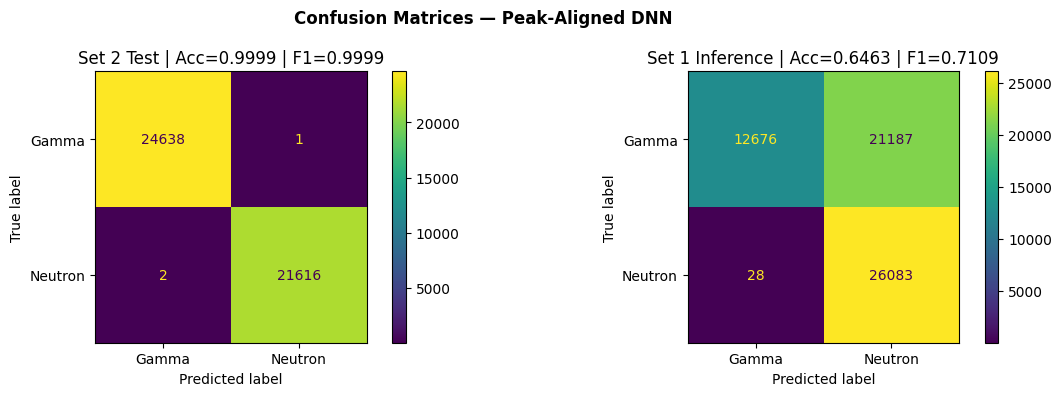

In [254]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(labels1, preds1),
                       display_labels=['Gamma', 'Neutron']).plot(ax=axes[0],values_format='d')
axes[0].set_title(f"Set 2 Test | Acc={acc1:.4f} | F1={f1_1:.4f}")
ConfusionMatrixDisplay(confusion_matrix(labels2, preds2),
                       display_labels=['Gamma', 'Neutron']).plot(ax=axes[1],values_format='d')
axes[1].set_title(f"Set 1 Inference | Acc={acc2:.4f} | F1={f1_2:.4f}")
plt.suptitle("Confusion Matrices — Peak-Aligned DNN", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

(3)

── Experiment 1: Learning Curve ─────────────────────────────────────────
  frac=0.2 | rep=1 | Set1 Acc=0.9953  | Set2 Acc=0.9989 
  frac=0.2 | rep=2 | Set1 Acc=0.9955  | Set2 Acc=0.9994 
  frac=0.2 | rep=3 | Set1 Acc=0.9952  | Set2 Acc=0.9993 
  frac=0.4 | rep=1 | Set1 Acc=0.9958  | Set2 Acc=0.9993 
  frac=0.4 | rep=2 | Set1 Acc=0.9954  | Set2 Acc=0.9939 
  frac=0.4 | rep=3 | Set1 Acc=0.9956  | Set2 Acc=0.9979 
  frac=0.6 | rep=1 | Set1 Acc=0.9959  | Set2 Acc=0.9987 
  frac=0.6 | rep=2 | Set1 Acc=0.9956  | Set2 Acc=0.9975 
  frac=0.6 | rep=3 | Set1 Acc=0.9955  | Set2 Acc=0.9987 
  frac=0.8 | rep=1 | Set1 Acc=0.9957  | Set2 Acc=0.9988 
  frac=0.8 | rep=2 | Set1 Acc=0.9956  | Set2 Acc=0.9987 
  frac=0.8 | rep=3 | Set1 Acc=0.9957  | Set2 Acc=0.9985 
  frac=1.0 | rep=1 | Set1 Acc=0.9958  | Set2 Acc=0.9974 
  frac=1.0 | rep=2 | Set1 Acc=0.9954  | Set2 Acc=0.9989 
  frac=1.0 | rep=3 | Set1 Acc=0.9954  | Set2 Acc=0.9986 


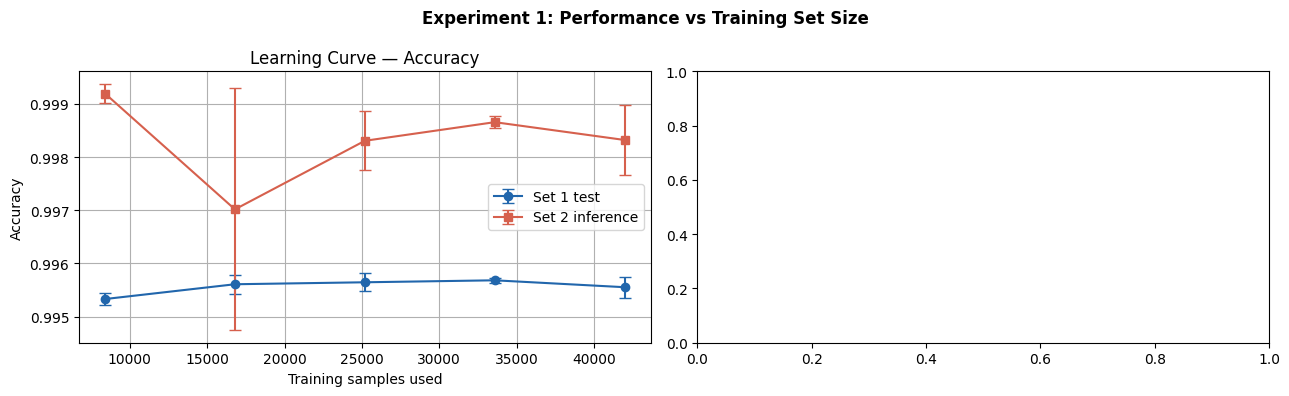


── Experiment 2: Label Shuffling ────────────────────────────────────────
  shuffle=0% | rep=1 | Set1 Acc=0.9957 | Set2 Acc=0.9986
  shuffle=15% | rep=1 | Set1 Acc=0.9959 | Set2 Acc=0.9989
  shuffle=30% | rep=1 | Set1 Acc=0.9956 | Set2 Acc=0.9986
  shuffle=50% | rep=1 | Set1 Acc=0.4883 | Set2 Acc=0.3821
  shuffle=75% | rep=1 | Set1 Acc=0.0044 | Set2 Acc=0.0008
  shuffle=100% | rep=1 | Set1 Acc=0.0047 | Set2 Acc=0.0011


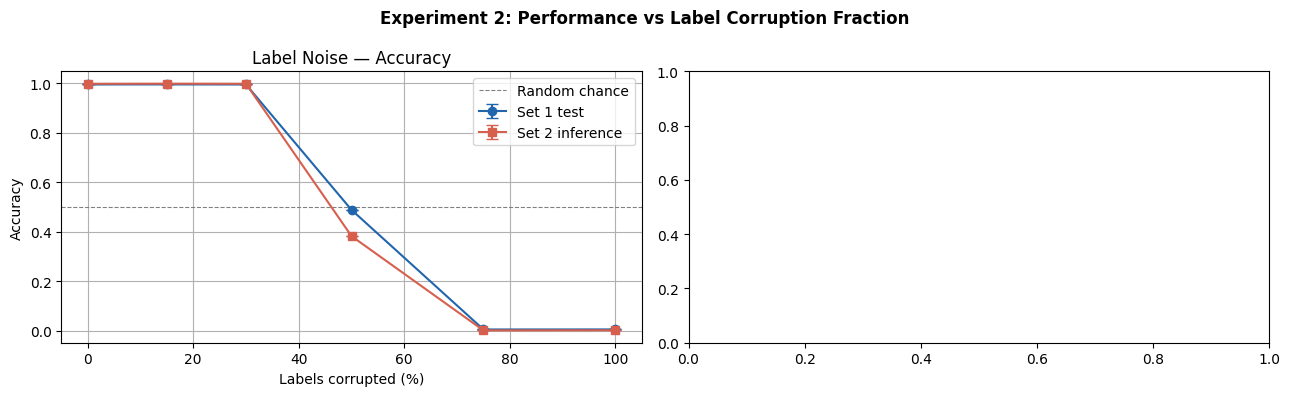


── Experiment 1 Summary (Learning Curve) ────────────────────────────────
Fraction   N_train      S1 Acc   S1 AUC   S2 Acc   S2 AUC
──────────────────────────────────────────────────────
0.2        8396         0.9953    0.9992 
0.4        16792        0.9956    0.9970 
0.6        25188        0.9956    0.9983 
0.8        33584        0.9957    0.9987 
1.0        41981        0.9956    0.9983 

── Experiment 2 Summary (Label Shuffling) ───────────────────────────────
Corrupt%     S1 Acc   S1 AUC   S2 Acc   S2 AUC
────────────────────────────────────────────
0            0.9957    0.9986 
15           0.9959    0.9989 
30           0.9956    0.9986 
50           0.4883    0.3821 
75           0.0044    0.0008 
100          0.0047    0.0011 


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# ── Reuse your existing parameters & data ────────────────────────────────────
# (assumes pa_s1g, pa_s1n, pa_s2g, pa_s2n, X1, y1, X2, y2 already exist)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 256
LR         = 3e-4

class PulseClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.4),
            nn.Linear(128, 64),        nn.ReLU(), nn.BatchNorm1d(64),  nn.Dropout(0.3),
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

def train_and_eval(X_train, y_train, X_test1, y_test1, X_test2, y_test2,
                   epochs=50, input_dim=150):
    """Train a fresh model and return (acc_set1, auc_set1, acc_set2, auc_set2)."""
    train_dl = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
        batch_size=BATCH_SIZE, shuffle=True
    )
    model     = PulseClassifier(input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step(epoch_loss / len(train_dl))

    def evaluate(X, y):
        dl = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y)),
                        batch_size=BATCH_SIZE, shuffle=False)
        model.eval()
        probs, labels_e = [], []
        with torch.no_grad():
            for xb, yb in dl:
                p = model(xb.to(device)).cpu().numpy()
                probs.extend(p)
                labels_e.extend(yb.numpy())
        probs    = np.array(probs)
        labels_e = np.array(labels_e)
        acc = accuracy_score(labels_e, (probs > 0.5).astype(float))
        
        return acc

    acc1 = evaluate(X_test1, y_test1)
    acc2= evaluate(X_test2, y_test2)
    return acc1, acc2

# ═══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1 — Learning curve: vary training set size, evaluate on Set 2
# ═══════════════════════════════════════════════════════════════════════════════

fractions      = [0.2, 0.4, 0.6, 0.8, 1.0]
EPOCHS_LC      = 100
N_REPEATS      = 3         # repeat each fraction to get mean ± std

lc_acc1_mean, lc_acc1_std = [], []

lc_acc2_mean, lc_acc2_std = [], []


# Fixed held-out Set 1 test split (30%)
X1_trainval, X1_test, y1_trainval, y1_test = train_test_split(
    X1, y1, test_size=0.30, stratify=y1, random_state=42
)

print("── Experiment 1: Learning Curve ─────────────────────────────────────────")
for frac in fractions:
    acc1_runs, acc2_runs = [], [], 
    for rep in range(N_REPEATS):
        # Sample fraction of trainval
        if frac < 1.0:
            X_tr, _, y_tr, _ = train_test_split(
                X1_trainval, y1_trainval,
                train_size=frac, stratify=y1_trainval,
                random_state=rep * 7
            )
        else:
            X_tr, y_tr = X1_trainval, y1_trainval

        a1, a2 = train_and_eval(
            X_tr, y_tr, X1_test, y1_test, X2, y2,
            epochs=EPOCHS_LC, input_dim=X1.shape[1]
        )
        acc1_runs.append(a1)
        acc2_runs.append(a2)
        print(f"  frac={frac:.1f} | rep={rep+1} | "
              f"Set1 Acc={a1:.4f}  | "
              f"Set2 Acc={a2:.4f} ")

    lc_acc1_mean.append(np.mean(acc1_runs)); lc_acc1_std.append(np.std(acc1_runs))
   
    lc_acc2_mean.append(np.mean(acc2_runs)); lc_acc2_std.append(np.std(acc2_runs))
    

# ── Plot: Learning Curve ──────────────────────────────────────────────────────
n_samples_used = [int(f * len(X1_trainval)) for f in fractions]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, m1, s1, m2, s2, ylabel in zip(
    axes,
    [lc_acc1_mean],
    [lc_acc1_std],
    [lc_acc2_mean],
    [lc_acc2_std],
    ['Accuracy']
):
    ax.errorbar(n_samples_used, m1, yerr=s1, marker='o', color='#2166AC',
                linewidth=1.5, capsize=4, label='Set 1 test')
    ax.errorbar(n_samples_used, m2, yerr=s2, marker='s', color='#D6604D',
                linewidth=1.5, capsize=4, label='Set 2 inference')
    ax.set_xlabel("Training samples used")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Learning Curve — {ylabel}")
    ax.legend()
    ax.grid(True)
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.suptitle("Experiment 1: Performance vs Training Set Size",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2 — Label shuffling: sanity / robustness check
# ═══════════════════════════════════════════════════════════════════════════════

shuffle_fractions = [0.0, 0.15, 0.3, 0.5, 0.75, 1.0]
EPOCHS_LS         = 100
N_REPEATS_LS      = 1

ls_acc1_mean, ls_acc1_std = [], []
ls_acc2_mean, ls_acc2_std = [], []

def corrupt_labels(y, corrupt_fraction, rng):
    """Randomly flip a fraction of labels."""
    y_corrupt   = y.copy()
    n_corrupt   = int(corrupt_fraction * len(y))
    corrupt_idx = rng.choice(len(y), size=n_corrupt, replace=False)
    y_corrupt[corrupt_idx] = 1.0 - y_corrupt[corrupt_idx]   # flip 0→1, 1→0
    return y_corrupt

print("\n── Experiment 2: Label Shuffling ────────────────────────────────────────")
for sf in shuffle_fractions:
    acc1_runs, acc2_runs = [], []
    for rep in range(N_REPEATS_LS):
        rng    = np.random.default_rng(seed=rep * 13)
        y_noisy = corrupt_labels(y1_trainval, sf, rng)

        a1, a2 = train_and_eval(
            X1_trainval, y_noisy, X1_test, y1_test, X2, y2,
            epochs=EPOCHS_LS, input_dim=X1.shape[1]
        )
        acc1_runs.append(a1)
        acc2_runs.append(a2)
        print(f"  shuffle={sf:.0%} | rep={rep+1} | "
              f"Set1 Acc={a1:.4f} | "
              f"Set2 Acc={a2:.4f}")

    ls_acc1_mean.append(np.mean(acc1_runs)); ls_acc1_std.append(np.std(acc1_runs))
   
    ls_acc2_mean.append(np.mean(acc2_runs)); ls_acc2_std.append(np.std(acc2_runs))
  

# ── Plot: Label Shuffling ─────────────────────────────────────────────────────
sf_pct = [f * 100 for f in shuffle_fractions]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, m1, s1, m2, s2, ylabel in zip(
    axes,
    [ls_acc1_mean],
    [ls_acc1_std],
    [ls_acc2_mean],
    [ls_acc2_std  ],
    ['Accuracy']
):
    ax.errorbar(sf_pct, m1, yerr=s1, marker='o', color='#2166AC',
                linewidth=1.5, capsize=4, label='Set 1 test')
    ax.errorbar(sf_pct, m2, yerr=s2, marker='s', color='#D6604D',
                linewidth=1.5, capsize=4, label='Set 2 inference')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random chance')
    ax.set_xlabel("Labels corrupted (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Label Noise — {ylabel}")
    ax.legend()
    ax.grid(True)
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.suptitle("Experiment 2: Performance vs Label Corruption Fraction",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary tables ────────────────────────────────────────────────────────────

print("\n── Experiment 1 Summary (Learning Curve) ────────────────────────────────")
print(f"{'Fraction':<10} {'N_train':<10} {'S1 Acc':>8} {'S2 Acc':>8} ")
print("─" * 54)
for i, frac in enumerate(fractions):
    print(f"{frac:<10.1f} {n_samples_used[i]:<10} "
          f"{lc_acc1_mean[i]:>8.4f}  "
          f"{lc_acc2_mean[i]:>8.4f} ")

print("\n── Experiment 2 Summary (Label Shuffling) ───────────────────────────────")
print(f"{'Corrupt%':<10} {'S1 Acc':>8}  {'S2 Acc':>8} ")
print("─" * 44)
for i, sf in enumerate(shuffle_fractions):
    print(f"{sf*100:<10.0f} "
          f"{ls_acc1_mean[i]:>8.4f}  "
          f"{ls_acc2_mean[i]:>8.4f} ")

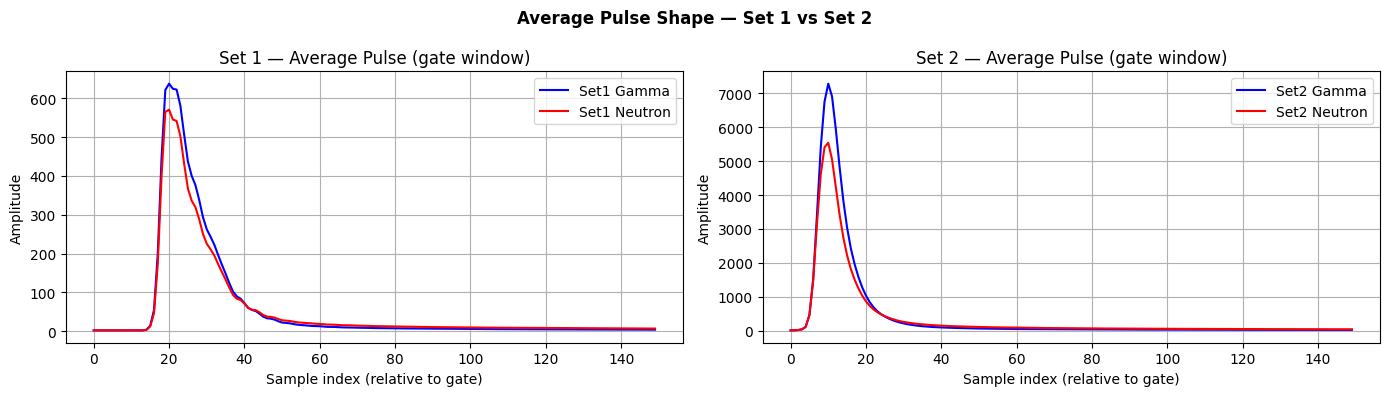

(82129, 150)


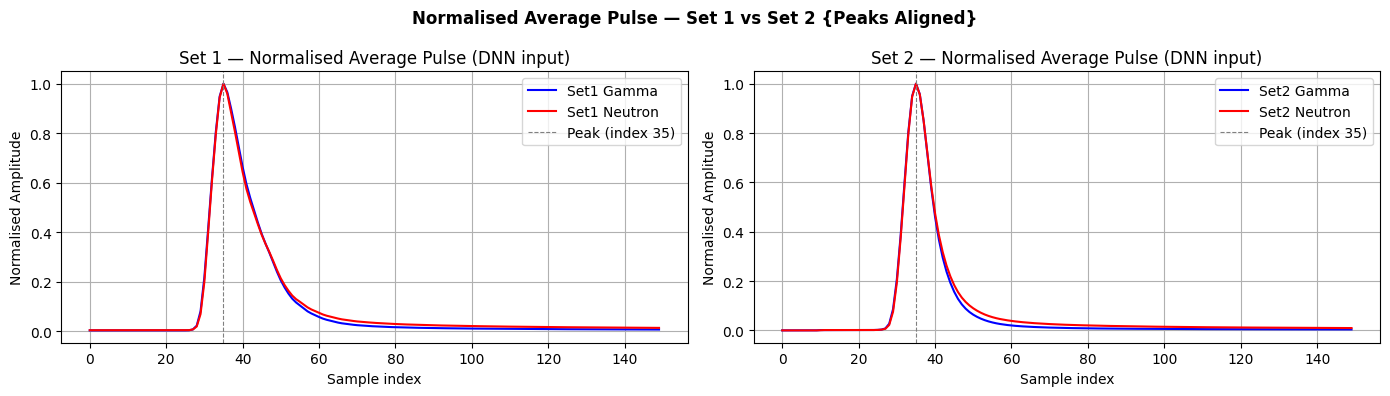

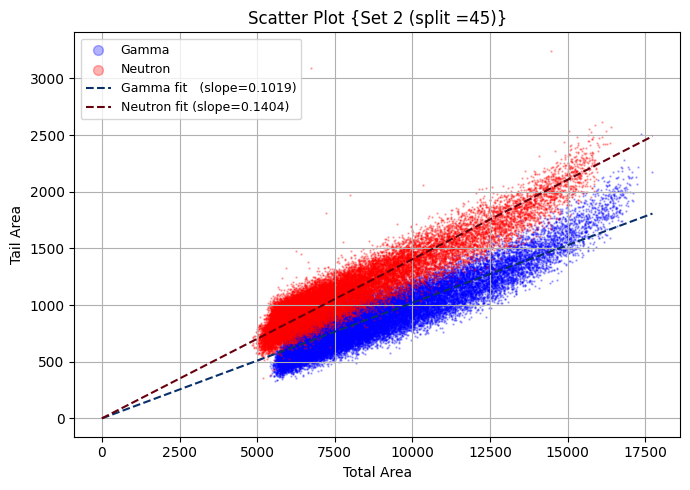

Computing CCM ratio — Gamma...
Computing CCM ratio — Neutron...
Computing weighted CCM — Gamma...
Computing weighted CCM — Neutron...


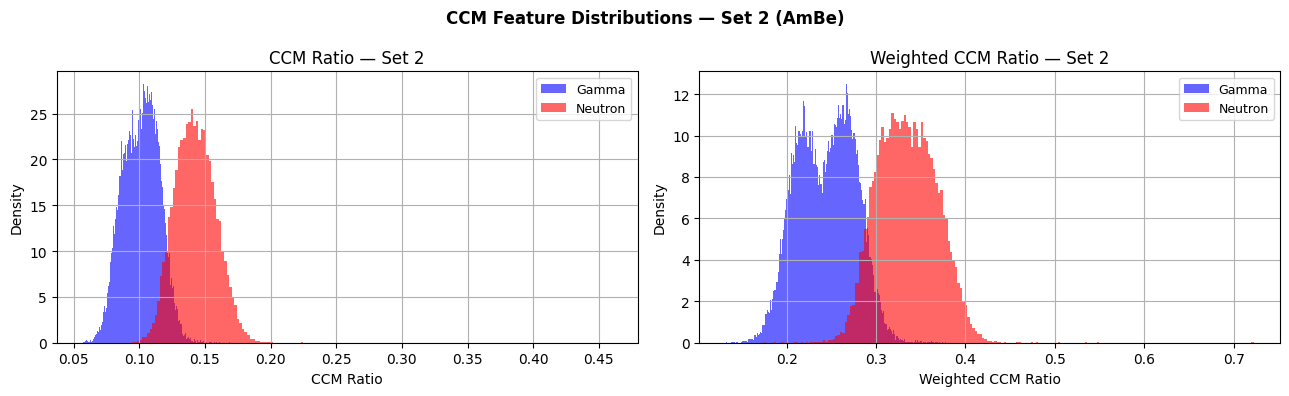

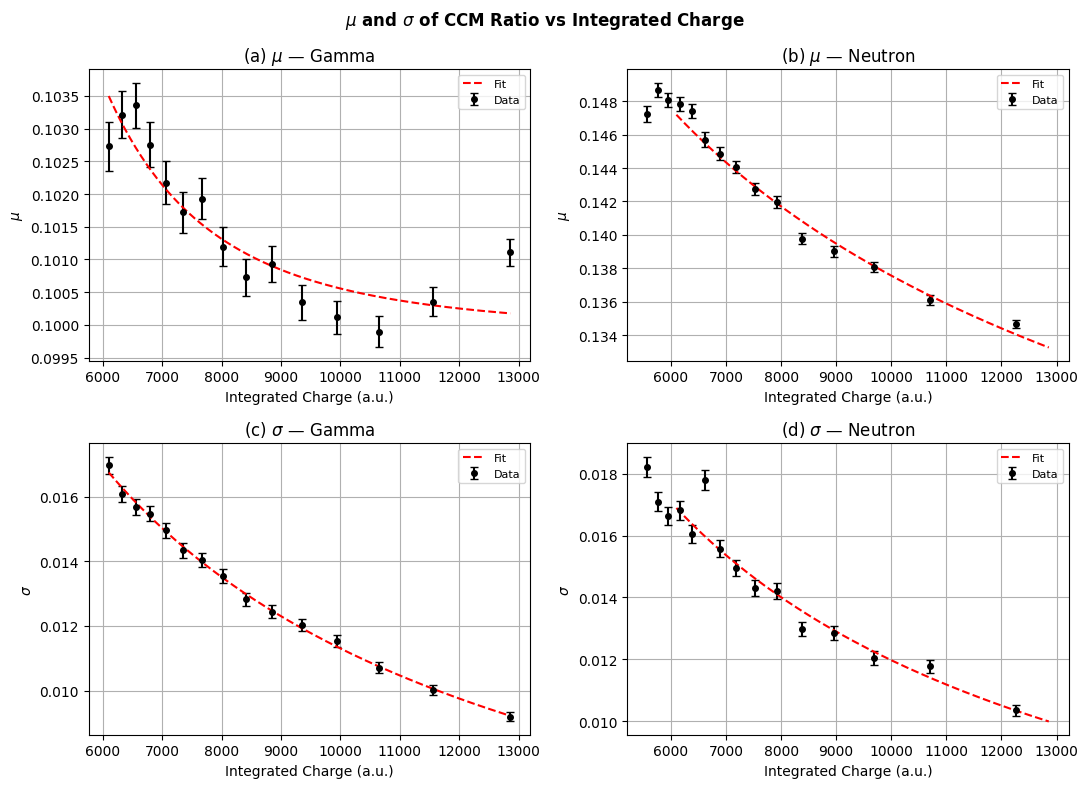

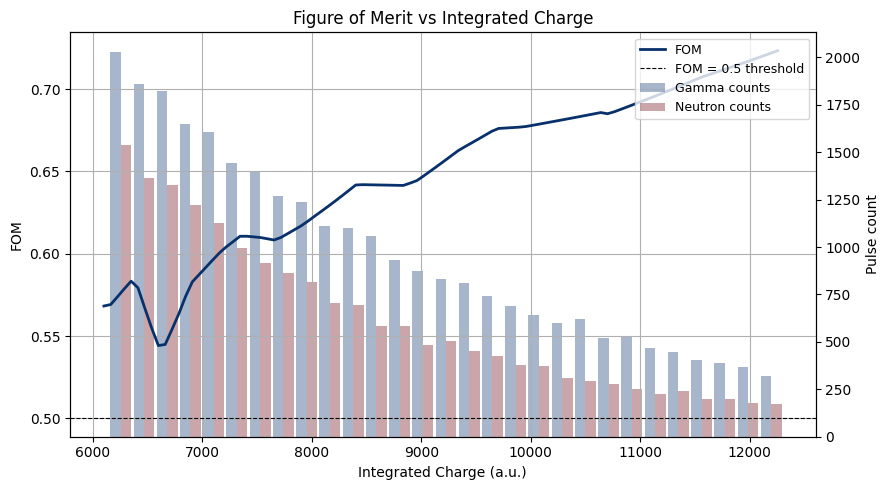

Mean FOM: 0.6493
Max  FOM: 0.7233 at Q = 12257

FOM crosses 0.5 at Q = 6100
Gamma   below threshold: 7.7%
Neutron below threshold: 24.5%
Logistic Regression on CCM ratio (tail/total)
  Accuracy : 0.9281
  AUC-ROC  : 0.9821
  Decision boundary (CCM threshold): 0.1240


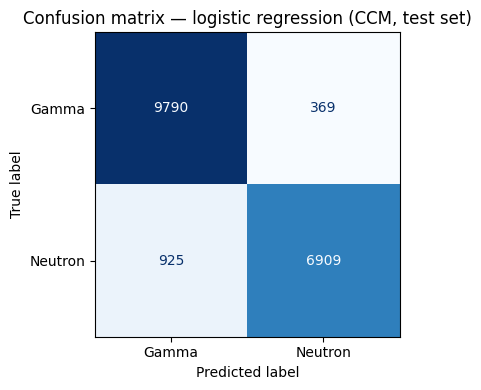

In [246]:
#(1)Average pulse shapes between Set 1 and Set 2 ─────────

# Get t-columns from Set 1
t_cols_s1_gamma   = [c for c in df_clean_gamma.columns   if str(c).startswith('t') or str(c).isdigit()]
t_cols_s1_neutron = [c for c in df_clean_neutron.columns if str(c).startswith('t') or str(c).isdigit()]
short_start = 15
long_end    = 165
# Use numeric columns only for Set 1 (in case columns are named differently)
set1_gamma_vals   = df_clean_gamma.select_dtypes(include=np.number).iloc[:, short_start:long_end]
set1_neutron_vals = df_clean_neutron.select_dtypes(include=np.number).iloc[:, short_start:long_end]
set2_gamma_vals   = df_clean_gamma_AmBe.iloc[:, short_start:long_end]
set2_neutron_vals = df_clean_neutron_AmBe.iloc[:, short_start:long_end]

mean_s1_g = set1_gamma_vals.mean(axis=0).values
mean_s1_n = set1_neutron_vals.mean(axis=0).values
mean_s2_g = set2_gamma_vals.mean(axis=0).values
mean_s2_n = set2_neutron_vals.mean(axis=0).values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mean_s1_g, color='blue',   linewidth=1.5, label='Set1 Gamma')
axes[0].plot(mean_s1_n, color='red',    linewidth=1.5, label='Set1 Neutron')
axes[0].set_title("Set 1 — Average Pulse (gate window)")
axes[0].set_xlabel("Sample index (relative to gate)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

axes[1].plot(mean_s2_g, color='blue',   linewidth=1.5, label='Set2 Gamma')
axes[1].plot(mean_s2_n, color='red',    linewidth=1.5, label='Set2 Neutron')
axes[1].set_title("Set 2 — Average Pulse (gate window)")
axes[1].set_xlabel("Sample index (relative to gate)")
axes[1].set_ylabel("Amplitude")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("Average Pulse Shape — Set 1 vs Set 2", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#Normalised pulse shapes with their peaks aligned

X2_gamma  = X2[:len(df_clean_gamma_AmBe)]  
print(X2_gamma.shape)  # first half is gamma
X2_neutron = X2[len(df_clean_gamma_AmBe):]   # second half is neutron

X1_gamma  = X1[:len(df_clean_gamma)]
X1_neutron = X1[len(df_clean_gamma):]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(X1_gamma.mean(axis=0),   color='blue', linewidth=1.5, label='Set1 Gamma')
axes[0].plot(X1_neutron.mean(axis=0), color='red',  linewidth=1.5, label='Set1 Neutron')
axes[0].axvline(35,    color='gray',  linewidth=0.8, linestyle='--', label='Peak (index 35)')
axes[0].set_title("Set 1 — Normalised Average Pulse (DNN input)")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Normalised Amplitude")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

axes[1].plot(X2_gamma.mean(axis=0),   color='blue', linewidth=1.5, label='Set2 Gamma')
axes[1].plot(X2_neutron.mean(axis=0), color='red',  linewidth=1.5, label='Set2 Neutron')
axes[1].axvline(35,    color='gray',  linewidth=0.8, linestyle='--', label='Peak (index 35)')
axes[1].set_title("Set 2 — Normalised Average Pulse (DNN input)")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Normalised Amplitude")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("Normalised Average Pulse — Set 1 vs Set 2 {Peaks Aligned}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#(2)── Scatter plot: Tail area vs Total area — Set 2────────────

short_start = 25 #25 for set1
long_end    = 105 #105 for set1
split       = 55 #change to 55 for set 1 
window      = 5

# Smooth Set 2
df_g_smooth = moving_average(df_clean_gamma.iloc[:,   :], window=window)
df_n_smooth = moving_average(df_clean_neutron.iloc[:, :], window=window)

# Total area = sum over entire gate window (short_start to long_end)
total_area_g = df_g_smooth.iloc[:, short_start:long_end].sum(axis=1)
total_area_n = df_n_smooth.iloc[:, short_start:long_end].sum(axis=1)

# Tail area = sum from split to long_end
tail_area_g  = df_g_smooth.iloc[:, split:long_end].sum(axis=1)
tail_area_n  = df_n_smooth.iloc[:, split:long_end].sum(axis=1)


slope_g = np.sum(total_area_g * tail_area_g) / np.sum(total_area_g ** 2)
slope_n = np.sum(total_area_n * tail_area_n) / np.sum(total_area_n ** 2)

x_line = np.linspace(0, int(max(tail_area_g.max(),total_area_g.max(),tail_area_n.max(),total_area_n.max())),300)
line_g  = slope_g * x_line
line_n  = slope_n * x_line
plt.figure(figsize=(7, 5))
plt.scatter(total_area_g, tail_area_g, s=0.5, alpha=0.3,
            color='blue', label='Gamma')
plt.scatter(total_area_n, tail_area_n, s=0.5, alpha=0.3,
            color='red',  label='Neutron')
plt.plot(x_line, line_g, color='#08306B', linewidth=1.5, linestyle='--',
         label=f'Gamma fit   (slope={slope_g:.4f})')
plt.plot(x_line, line_n, color='#67000D',  linewidth=1.5, linestyle='--',
         label=f'Neutron fit (slope={slope_n:.4f})')
plt.xlabel("Total Area")
plt.ylabel("Tail Area")
plt.title("Scatter Plot {Set 2 (split =45)}")#change to 55 for set 1 
plt.legend(markerscale=10, fontsize=9)
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

#(3) Histograms for CCM and weighted CCM
# ── CCM functions ─────────────────────────────────────────────────────────────

def compute_ccm_ratio(df_smooth, short_start, long_end, window=5):
    ratios = []
    for i in range(len(df_smooth)):
        waveform = df_smooth.iloc[i, short_start:long_end].values.astype(float)
        peak_idx = 30#change to 55 for set 1 
        short    = waveform[:peak_idx].sum()
        long_    = waveform[peak_idx:].sum()
        ratios.append(np.abs(long_ / (long_ + short + 1e-10)))
    return np.array(ratios)

def compute_ccm_weighted(df_smooth, short_start, long_end, window=5):
    ratios = []
    for i in range(len(df_smooth)):
        waveform   = df_smooth.iloc[i, short_start:long_end].values.astype(float)
        peak_idx   = 30#change to 55 for set 1 ,45 for set2
        short_gate = waveform[:peak_idx]
        long_gate  = waveform[peak_idx:]
        weights_s  = np.arange(1, peak_idx + 1)
        weights_l  = np.arange(peak_idx + 1, len(waveform) + 1)
        short_w    = (short_gate * weights_s).sum()
        long_w     = (long_gate  * weights_l).sum()
        ratios.append(np.abs(long_w / (long_w + short_w + 1e-10)))
    return np.array(ratios)

# ── Compute CCM ratios for Set 2 ──────────────────────────────────────────────

print("Computing CCM ratio — Gamma...")
ccm_g   = compute_ccm_ratio(df_g_smooth,   short_start, long_end)
print("Computing CCM ratio — Neutron...")
ccm_n   = compute_ccm_ratio(df_n_smooth,   short_start, long_end)

print("Computing weighted CCM — Gamma...")
ccm_w_g = compute_ccm_weighted(df_g_smooth, short_start, long_end)
print("Computing weighted CCM — Neutron...")
ccm_w_n = compute_ccm_weighted(df_n_smooth, short_start, long_end)

# ── Plot histograms ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CCM Ratio
axes[0].hist(ccm_g,   bins=200, alpha=0.6, color='blue',
             density=True, label='Gamma')
axes[0].hist(ccm_n,   bins=200, alpha=0.6, color='red',
             density=True, label='Neutron')
axes[0].set_xlabel("CCM Ratio")
axes[0].set_ylabel("Density")
axes[0].set_title("CCM Ratio — Set 2")
axes[0].legend(fontsize=9)
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

# Weighted CCM
axes[1].hist(ccm_w_g, bins=200, alpha=0.6, color='blue',
             density=True, label='Gamma')
axes[1].hist(ccm_w_n, bins=200, alpha=0.6, color='red',
             density=True, label='Neutron')
axes[1].set_xlabel("Weighted CCM Ratio")
axes[1].set_ylabel("Density")
axes[1].set_title("Weighted CCM Ratio — Set 2")
axes[1].legend(fontsize=9)
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("CCM Feature Distributions — Set 2 (AmBe)", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── μ and σ vs integrated charge ──────────────────────────────────────────────
from scipy.stats import norm
from scipy.optimize import curve_fit

def compute_mu_sigma_vs_charge(total_area, ccm_ratio, n_bins=15):
    """
    Bin pulses by integrated charge, fit Gaussian to CCM ratio
    in each bin, return bin centres, mu, sigma and their errors.
    """
    # Define bin edges on integrated charge
    bin_edges  = np.percentile(total_area, np.linspace(5, 95, n_bins + 1))
    bin_centres, mus, sigmas, mu_errs, sig_errs = [], [], [], [], []

    for i in range(len(bin_edges) - 1):
        mask = (total_area >= bin_edges[i]) & (total_area < bin_edges[i+1])
        vals = ccm_ratio[mask]
        if len(vals) < 30:
            continue
        mu, sigma = norm.fit(vals)
        # Error on mu and sigma from sample size
        mu_err  = sigma / np.sqrt(len(vals))
        sig_err = sigma / np.sqrt(2 * len(vals))

        bin_centres.append((bin_edges[i] + bin_edges[i+1]) / 2)
        mus.append(mu);       mu_errs.append(mu_err)
        sigmas.append(sigma); sig_errs.append(sig_err)

    return (np.array(bin_centres), np.array(mus),    np.array(mu_errs),
                                   np.array(sigmas),  np.array(sig_errs))

# Power law decay fit: f(Q) = a * Q^b + c
def power_decay(Q, a, b, c):
    return a * np.power(Q, b) + c

# ── Compute for gamma and neutron ─────────────────────────────────────────────
# total_area_g, total_area_n = integrated charge (from your scatter plot code)
# ccm_g, ccm_n               = CCM ratio arrays (from compute_ccm_ratio)

bc_g, mu_g, mu_err_g, sig_g, sig_err_g = compute_mu_sigma_vs_charge(total_area_g, ccm_g)
bc_n, mu_n, mu_err_n, sig_n, sig_err_n = compute_mu_sigma_vs_charge(total_area_n, ccm_n)

# ── Fit power decay to each ───────────────────────────────────────────────────
popt_mu_g,  _ = curve_fit(power_decay, bc_g, mu_g,  p0=[100, -0.5, 0.05], maxfev=15000)
popt_mu_n,  _ = curve_fit(power_decay, bc_n, mu_n ,  p0=[100, -0.5, 0.15], maxfev=15000)
popt_sig_g, _ = curve_fit(power_decay, bc_g, sig_g , p0=[100, -0.5, 0.01], maxfev=15000)
popt_sig_n, _ = curve_fit(power_decay, bc_n , sig_n , p0=[100, -0.5, 0.01], maxfev=15000)

Q_fit = np.linspace(bc_g.min(), bc_g.max(), 300)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# (a) mu gamma
axes[0,0].errorbar(bc_g, mu_g, yerr=mu_err_g, fmt='ko', markersize=4,
                   capsize=3, label='Data')
axes[0,0].plot(Q_fit, power_decay(Q_fit, *popt_mu_g),
               'r--', linewidth=1.5, label='Fit')
axes[0,0].set_xlabel("Integrated Charge (a.u.)")
axes[0,0].set_ylabel(r"$\mu$")
axes[0,0].set_title(r"(a) $\mu$ — Gamma")
axes[0,0].legend(fontsize=8); axes[0,0].grid(True)

# (b) mu neutron
axes[0,1].errorbar(bc_n, mu_n, yerr=mu_err_n, fmt='ko', markersize=4,
                   capsize=3, label='Data')
axes[0,1].plot(Q_fit, power_decay(Q_fit, *popt_mu_n),
               'r--', linewidth=1.5, label='Fit')
axes[0,1].set_xlabel("Integrated Charge (a.u.)")
axes[0,1].set_ylabel(r"$\mu$")
axes[0,1].set_title(r"(b) $\mu$ — Neutron")
axes[0,1].legend(fontsize=8); axes[0,1].grid(True)

# (c) sigma gamma
axes[1,0].errorbar(bc_g, sig_g, yerr=sig_err_g, fmt='ko', markersize=4,
                   capsize=3, label='Data')
axes[1,0].plot(Q_fit, power_decay(Q_fit, *popt_sig_g),
               'r--', linewidth=1.5, label='Fit')
axes[1,0].set_xlabel("Integrated Charge (a.u.)")
axes[1,0].set_ylabel(r"$\sigma$")
axes[1,0].set_title(r"(c) $\sigma$ — Gamma")
axes[1,0].legend(fontsize=8); axes[1,0].grid(True)

# (d) sigma neutron
axes[1,1].errorbar(bc_n, sig_n, yerr=sig_err_n, fmt='ko', markersize=4,
                   capsize=3, label='Data')
axes[1,1].plot(Q_fit, power_decay(Q_fit, *popt_sig_n),
               'r--', linewidth=1.5, label='Fit')
axes[1,1].set_xlabel("Integrated Charge (a.u.)")
axes[1,1].set_ylabel(r"$\sigma$")
axes[1,1].set_title(r"(d) $\sigma$ — Neutron")
axes[1,1].legend(fontsize=8); axes[1,1].grid(True)

for spine in ax.spines.values():
    spine.set_visible(True)

plt.suptitle(r"$\mu$ and $\sigma$ of CCM Ratio vs Integrated Charge",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
from scipy.interpolate import interp1d

Q_common = np.linspace(max(bc_g .min(), bc_n .min()),
                       min(bc_g .max(), bc_n .max()), 100)

interp_mu_g  = interp1d(bc_g , mu_g ,  kind='linear', fill_value='extrapolate')
interp_mu_n  = interp1d(bc_n , mu_n ,  kind='linear', fill_value='extrapolate')
interp_sig_g = interp1d(bc_g , sig_g , kind='linear', fill_value='extrapolate')
interp_sig_n = interp1d(bc_n , sig_n , kind='linear', fill_value='extrapolate')

FOM = ((interp_mu_n(Q_common) - interp_mu_g(Q_common)) /
       (2.355 * (interp_sig_n(Q_common) + interp_sig_g(Q_common))))

# ── Bin pulse counts on the same charge axis ──────────────────────────────────
bin_edges  = np.linspace(Q_common.min(), Q_common.max(), 30)
bin_centres_bar = (bin_edges[:-1] + bin_edges[1:] ) / 2
bin_width  = bin_edges[1] - bin_edges[0]

counts_g, _ = np.histogram(total_area_g, bins=bin_edges)
counts_n, _ = np.histogram(total_area_n, bins=bin_edges)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 5))

# ── Bar chart on secondary y-axis ─────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.bar(bin_centres_bar, counts_g, width=bin_width * 0.45,
        align='center', alpha=0.35, color='#08306B',
        label='Gamma counts')
ax2.bar(bin_centres_bar + bin_width * 0.45, counts_n, width=bin_width * 0.45,
        align='center', alpha=0.35, color='#67000D',
        label='Neutron counts')
ax2.set_ylabel("Pulse count", fontsize=10)
ax2.tick_params(axis='y')

# ── FOM line on primary y-axis ────────────────────────────────────────────────
ax1.plot(Q_common, FOM, color='#08306B', linewidth=2, zorder=5, label='FOM')
ax1.axhline(0.5, color='black', linestyle='--', linewidth=0.8,
            label='FOM = 0.5 threshold')
ax1.set_xlabel("Integrated Charge (a.u.)")
ax1.set_ylabel("FOM")
ax1.set_title("Figure of Merit vs Integrated Charge")
ax1.set_zorder(ax2.get_zorder() + 1)   # keep FOM line on top
ax1.patch.set_visible(False)           # let ax2 background show through
ax1.grid(True)
for spine in ax1.spines.values():
    spine.set_visible(True)

# ── Combined legend ───────────────────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

print(f"Mean FOM: {FOM.mean():.4f}")
print(f"Max  FOM: {FOM.max():.4f} at Q = {Q_common[FOM.argmax()]:.0f}")

# ── Fraction of pulses below FOM threshold ────────────────────────────────────
threshold_charge = Q_common[np.argmax(FOM >= 0.5)]
frac_g_below = (total_area_g < threshold_charge).mean()
frac_n_below = (total_area_n < threshold_charge).mean()
print(f"\nFOM crosses 0.5 at Q = {threshold_charge:.0f}")
print(f"Gamma   below threshold: {frac_g_below*100:.1f}%")
print(f"Neutron below threshold: {frac_n_below*100:.1f}%")



# ── CCM ratio is simply tail_area / total_area per pulse ─────────────────────
# using the same raw (unnormalised) areas from your scatter/FOM code

ccm_simple_g = tail_area_g / (total_area_g + 1e-10)   # shape (N_gamma,)
ccm_simple_n = tail_area_n / (total_area_n + 1e-10)   # shape (N_neutron,)
# ── Build dataset ─────────────────────────────────────────────────────────────
X_ccm = np.concatenate([ccm_simple_g, ccm_simple_n]).reshape(-1, 1)
y_ccm = np.concatenate([np.zeros(len(ccm_simple_g)),
                         np.ones(len(ccm_simple_n))])
# ── Train/test split ──────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_ccm, y_ccm, test_size=0.3, stratify=y_ccm, random_state=42
)
# ── Fit logistic regression ───────────────────────────────────────────────────
clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_tr)
# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred  = clf.predict(X_te)
y_proba = clf.predict_proba(X_te)[:, 1]
acc = accuracy_score(y_te, y_pred)
auc = roc_auc_score(y_te, y_proba)
print(f"Logistic Regression on CCM ratio (tail/total)")
print(f"  Accuracy : {acc:.4f}")
print(f"  AUC-ROC  : {auc:.4f}")
print(f"  Decision boundary (CCM threshold): "
      f"{-clf.intercept_[0] / clf.coef_[0][0]:.4f}")
# ── Confusion matrix (test set) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Gamma", "Neutron"],
)
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion matrix — logistic regression (CCM, test set)")
plt.tight_layout()
plt.show()

(4) All plots related to pulse properties

K-Means — Acc: 0.9278


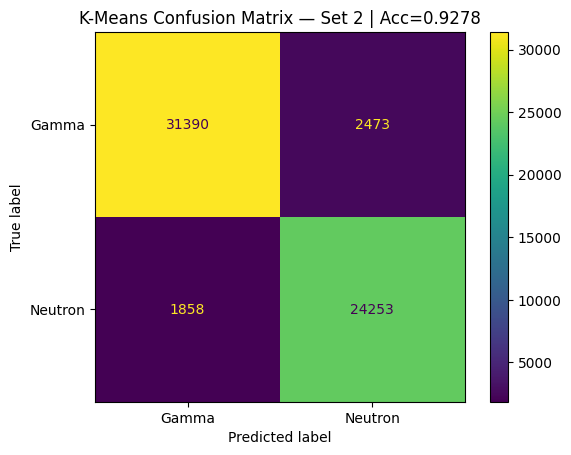

In [ ]:
# print("Set 2 Gamma...")
# s2g_ccm  = compute_ccm_ratio(df_clean_gamma)
# s2g_ccmw = compute_ccm_weighted(df_clean_gamma)
# print("Set 2 Neutron...")
# s2n_ccm  = compute_ccm_ratio(df_clean_neutron)
# s2n_ccmw = compute_ccm_weighted(df_clean_neutron)
# print("Computing CCM ratio — Gamma...")
# ccm_g   = compute_ccm_ratio(df_g_smooth,   short_start, long_end)
# print("Computing CCM ratio — Neutron...")
# ccm_n   = compute_ccm_ratio(df_n_smooth,   short_start, long_end)

# print("Computing weighted CCM — Gamma...")
# ccm_w_g = compute_ccm_weighted(df_g_smooth, short_start, long_end)
# print("Computing weighted CCM — Neutron...")
# ccm_w_n = compute_ccm_weighted(df_n_smooth, short_start, long_end)
# ── K-Means ───────────────────────────────────────────────────────────────────

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

X2_cluster = np.column_stack([
    np.concatenate([ccm_g,  ccm_n]),
    np.concatenate([ccm_w_g, ccm_w_n])
])
y2_true = np.concatenate([np.zeros(len(ccm_g)), np.ones(len(ccm_n))])

mask  = np.isfinite(X2_cluster).all(axis=1)
X2_c  = X2_cluster[mask]
y2_c  = y2_true[mask]

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X2_c)

acc_direct     = accuracy_score(y2_c, labels)
acc_flip       = accuracy_score(y2_c, 1 - labels)
labels_aligned = labels if acc_direct > acc_flip else 1 - labels
acc_kmeans     = max(acc_direct, acc_flip)

print(f"K-Means — Acc: {acc_kmeans:.4f}")
ConfusionMatrixDisplay(confusion_matrix(y2_c, labels_aligned),
                       display_labels=['Gamma', 'Neutron']).plot()
plt.title(f"K-Means Confusion Matrix — Set 2 | Acc={acc_kmeans:.4f}")
plt.show()

(5) comparison of ml models

In [251]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import time
import tracemalloc
import sys

# ── Parameters ────────────────────────────────────────────────────────────────

TARGET_PEAK  = 35
PULSE_LENGTH = 150
WINDOW       = 5
EPOCHS       = 100
BATCH_SIZE   = 256
LR           = 3e-4
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ══════════════════════════════════════════════════════════════════════════════
# MODEL DEFINITIONS
# ══════════════════════════════════════════════════════════════════════════════

# class PulseClassifier(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.4),
#             nn.Linear(128, 64),        nn.ReLU(), nn.BatchNorm1d(64),  nn.Dropout(0.3),
#             nn.Linear(64, 1),          nn.Sigmoid()
#         )
#     def forward(self, x):
#         return self.net(x).squeeze()

# class CNN1D(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.conv = nn.Sequential(
#             nn.Conv1d(1, 32, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(32),
#             nn.MaxPool1d(2),
#             nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(64),
#             nn.MaxPool1d(2),
#             nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(128),
#             nn.MaxPool1d(2),
#         )
#         cnn_out = 128 * (input_dim // 8)
#         self.fc = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(cnn_out, 64), nn.ReLU(), nn.Dropout(0.3),
#             nn.Linear(64, 1),       nn.Sigmoid()
#         )
#     def forward(self, x):
#         x = x.unsqueeze(1)
#         return self.fc(self.conv(x)).squeeze()

class GRUClassifier(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=2):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden,
                          num_layers=layers, batch_first=True,
                          dropout=0.3, bidirectional=True)
        self.fc  = nn.Sequential(
            nn.Linear(hidden * 2, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        x = x.unsqueeze(2)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden,
                            num_layers=layers, batch_first=True,
                            dropout=0.3, bidirectional=True)
        self.fc   = nn.Sequential(
            nn.Linear(hidden * 2, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        x = x.unsqueeze(2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# ══════════════════════════════════════════════════════════════════════════════
# PARAMETER COUNT UTILITY
# ══════════════════════════════════════════════════════════════════════════════

def count_parameters(model):
    total  = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING FUNCTION WITH TIMING + MEMORY TRACKING
# ══════════════════════════════════════════════════════════════════════════════

def train_torch_model(model, X1_trainval, y1_trainval, epochs=EPOCHS):
    n_trainval  = len(X1_trainval)
    n_val       = int(0.10 * n_trainval)
    indices     = np.arange(n_trainval)
    trainval_ds = TensorDataset(torch.tensor(X1_trainval),
                                torch.tensor(y1_trainval))

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, patience=5, factor=0.5)
    criterion = nn.BCELoss()

    train_losses, val_losses, val_accs = [], [], []

    # ── Start tracking ────────────────────────────────────────────────────────
    tracemalloc.start()
    t_start = time.time()

    for epoch in range(epochs):
        np.random.shuffle(indices)
        train_idx = indices[n_val:]
        val_idx   = indices[:n_val]

        train_dl = DataLoader(trainval_ds, batch_size=BATCH_SIZE,
                              sampler=SubsetRandomSampler(train_idx))
        val_dl   = DataLoader(trainval_ds, batch_size=BATCH_SIZE,
                              sampler=SubsetRandomSampler(val_idx))

        model.train()
        epoch_train_loss = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        epoch_train_loss /= len(train_dl)

        model.eval()
        epoch_val_loss = 0
        preds_v, labels_v = [], []
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                probs   = model(xb)
                epoch_val_loss += criterion(probs, yb).item()
                preds_v.extend((probs.cpu().numpy() > 0.5).astype(float))
                labels_v.extend(yb.cpu().numpy())
        epoch_val_loss /= len(val_dl)
        val_acc         = accuracy_score(labels_v, preds_v)

        scheduler.step(epoch_val_loss)
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        val_accs.append(val_acc)

        print(f"  Epoch {epoch+1:03d}/{epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")

    # ── Stop tracking ─────────────────────────────────────────────────────────
    t_end   = time.time()
    current, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    elapsed   = t_end - t_start
    peak_mb   = peak_mem / 1024 / 1024

    return train_losses, val_losses, val_accs, elapsed, peak_mb

# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def full_eval_torch(model, X, y, label):
    dl = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y)),
                    batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    preds, probs, labels_e = [], [], []
    with torch.no_grad():
        for xb, yb in dl:
            p = model(xb.to(device)).cpu().numpy()
            probs.extend(p)
            preds.extend((p > 0.5).astype(float))
            labels_e.extend(yb.numpy())
    probs, preds, labels_e = np.array(probs), np.array(preds), np.array(labels_e)
    acc  = accuracy_score(labels_e,  preds)
    auc  = roc_auc_score(labels_e,   probs)
    prec = precision_score(labels_e, preds)
    rec  = recall_score(labels_e,    preds)
    f1   = f1_score(labels_e,        preds)
    print(f"\n── {label} ────────────────────────────────────────────────────")
    print(f"  Accuracy: {acc:.4f} | AUC: {auc:.4f} | "
          f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    return acc, auc, prec, rec, f1, np.array(preds), probs, labels_e

def eval_sklearn(clf, X, y, label):
    preds  = clf.predict(X)
    probs  = clf.predict_proba(X)[:, 1]
    acc    = accuracy_score(y,  preds)
    auc    = roc_auc_score(y,   probs)
    prec   = precision_score(y, preds)
    rec    = recall_score(y,    preds)
    f1     = f1_score(y,        preds)
    print(f"\n── {label} ────────────────────────────────────────────────────")
    print(f"  Accuracy: {acc:.4f} | AUC: {auc:.4f} | "
          f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    return acc, auc, prec, rec, f1, preds, probs, y

def print_confusion_matrix(labels, preds, model_name, split_label):
    cm = confusion_matrix(labels.astype(int), preds.astype(int))
    print(f"\n── Confusion Matrix — {model_name} | {split_label} ─────────────────")
    print(f"                 Predicted Gamma   Predicted Neutron")
    print(f"  True Gamma     {cm[0,0]:>14d}   {cm[0,1]:>17d}")
    print(f"  True Neutron   {cm[1,0]:>14d}   {cm[1,1]:>17d}")
    tn, fp, fn, tp = cm.ravel()
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")

# ══════════════════════════════════════════════════════════════════════════════
# COST TRACKING DICT
# ══════════════════════════════════════════════════════════════════════════════

costs = {}   # {model_name: {time_s, peak_mb, n_params}}

# ══════════════════════════════════════════════════════════════════════════════
# TRAIN ALL TORCH MODELS
# ══════════════════════════════════════════════════════════════════════════════

results = {}

X1_tr_np = X1_trainval.astype(np.float32)
X1_te_np = X1_test.astype(np.float32)
X2_np    = X2.astype(np.float32)
y1_tr_np = y1_trainval.astype(int)
y1_te_np = y1_test.astype(int)
y2_np    = y2.astype(int)

# torch_models = {
#     # 'DNN':  PulseClassifier(input_dim=X1_trainval.shape[1]),
#     # 'CNN':  CNN1D(input_dim=X1_trainval.shape[1]),
#     'GRU':  GRUClassifier(input_dim=X1_trainval.shape[1]),
#     'LSTM': LSTMClassifier(input_dim=X1_trainval.shape[1]),
# }

# for name, mdl in torch_models.items():
#     print(f"\n{'═'*60}")
#     print(f"Training {name}")
#     print(f"{'═'*60}")
#     mdl = mdl.to(device)
#     total_p, train_p = count_parameters(mdl)
#     print(f"  Parameters — Total: {total_p:,} | Trainable: {train_p:,}")

#     _, _, _, elapsed, peak_mb = train_torch_model(mdl, X1_trainval, y1_trainval)

#     costs[name] = {
#         'time_s':   elapsed,
#         'peak_mb':  peak_mb,
#         'n_params': train_p
#     }
#     print(f"\n  Training time : {elapsed:.1f} s  ({elapsed/60:.2f} min)")
#     print(f"  Peak memory   : {peak_mb:.1f} MB")

#     results[name] = {
#         's1': full_eval_torch(mdl, X1_test, y1_test, f"{name} — Set 1 Test"),
#         's2': full_eval_torch(mdl, X2,      y2,      f"{name} — Set 2")
#     }
#     print_confusion_matrix(results[name]['s2'][7],
#                            results[name]['s2'][5], name, "Set 2")

# ══════════════════════════════════════════════════════════════════════════════
# TRAIN SKLEARN MODELS
# ══════════════════════════════════════════════════════════════════════════════

sklearn_models = {
    'Random Forest':   RandomForestClassifier(n_estimators=200, max_depth=20,
                                               n_jobs=-1, random_state=42),
    'Gradient Boost':  GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                   learning_rate=0.05, random_state=42),
    'Logistic Reg':    LogisticRegression(max_iter=1000, C=1.0, random_state=42),
}

for name, clf in sklearn_models.items():
    print(f"\n{'═'*60}")
    print(f"Training {name}")
    print(f"{'═'*60}")

    tracemalloc.start()
    t_start = time.time()
    clf.fit(X1_tr_np, y1_tr_np)
    t_end = time.time()
    current, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    elapsed  = t_end - t_start
    peak_mb  = peak_mem / 1024 / 1024

    # approximate model size in memory
    model_mb = sys.getsizeof(clf) / 1024 / 1024

    costs[name] = {
        'time_s':   elapsed,
        'peak_mb':  peak_mb,
        'n_params': 'N/A'
    }
    print(f"  Training time : {elapsed:.1f} s  ({elapsed/60:.2f} min)")
    print(f"  Peak memory   : {peak_mb:.1f} MB")

    results[name] = {
        's1': eval_sklearn(clf, X1_te_np, y1_te_np, f"{name} — Set 1 Test"),
        's2': eval_sklearn(clf, X2_np,    y2_np,    f"{name} — Set 2")
    }
    print_confusion_matrix(results[name]['s2'][7],
                           results[name]['s2'][5], name, "Set 2")

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLES
# ══════════════════════════════════════════════════════════════════════════════

model_names = list(results.keys())
metrics     = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1']

for split_key, split_label in [('s1', 'Set 1 Test'), ('s2', 'Set 2 Inference')]:
    print(f"\n── Performance Summary — {split_label} {'─'*30}")
    print(f"{'Model':<18}", end="")
    for m in metrics:
        print(f"{m:>11}", end="")
    print()
    print("─" * 73)
    for name in model_names:
        r = results[name][split_key]
        print(f"{name:<18}", end="")
        for val in r[:5]:
            print(f"{val:>11.4f}", end="")
        print()

print(f"\n── Training Cost Summary {'─'*45}")
print(f"{'Model':<18} {'Time (s)':>10} {'Time (min)':>12} "
      f"{'Peak RAM (MB)':>15} {'Parameters':>12}")
print("─" * 72)
for name in model_names:
    c = costs[name]
    p = f"{c['n_params']:,}" if isinstance(c['n_params'], int) else c['n_params']
    print(f"{name:<18} {c['time_s']:>10.1f} {c['time_s']/60:>12.2f} "
          f"{c['peak_mb']:>15.1f} {p:>12}")

Using device: cpu

════════════════════════════════════════════════════════════
Training Random Forest
════════════════════════════════════════════════════════════
  Training time : 17.9 s  (0.30 min)
  Peak memory   : 43.4 MB

── Random Forest — Set 1 Test ────────────────────────────────────────────────────
  Accuracy: 0.9933 | AUC: 0.9979 | Precision: 0.9923 | Recall: 0.9923 | F1: 0.9923

── Random Forest — Set 2 ────────────────────────────────────────────────────
  Accuracy: 0.8875 | AUC: 0.9982 | Precision: 1.0000 | Recall: 0.7592 | F1: 0.8631

── Confusion Matrix — Random Forest | Set 2 ─────────────────
                 Predicted Gamma   Predicted Neutron
  True Gamma              82129                   0
  True Neutron            17349               54710
  TN=82129  FP=0  FN=17349  TP=54710

════════════════════════════════════════════════════════════
Training Gradient Boost
════════════════════════════════════════════════════════════
  Training time : 522.5 s  (8.71 min)
  

KeyError: 'DNN'